# 14. Fourier-Based Methods for Option Pricing

**Main parts of this project**

- Build a reusable SPX option-pricing panel and calibration grid without re-teaching the option-chain cleaning from earlier option projects.
- Move from pricing by closed-form formulas or simulation to pricing by **characteristic functions**.
- Validate direct Fourier integration, Carr-Madan FFT, and the COS method on models where we can measure numerical error clearly.
- Study how BSM, Merton, Variance Gamma, Heston, and Bates behave when the same Fourier engines price them.
- Use grouped COS pricing for daily calibration across real SPX option quotes.
- Diagnose model fit through RMSE, bid/ask hit rate, residual smiles, tail probabilities, and runtime/error tradeoffs.
- Build tail-hedging overlays from model-implied crash probabilities and model disagreement.
- Repeat the production workflow on BTC options and interpret why crypto options change the calibration and hedging story.


## 1) The Core Idea: Pricing from a Transform Instead of a Path

Earlier option projects already covered the basic option-pricing language: market quotes, implied volatility, surfaces, Greeks, local volatility, stochastic volatility, jumps, and American-option numerics. Here the new subject is the **pricing engine itself**. We stop asking for a closed-form option formula model by model, and we ask a more general question: if we know the distribution of the future log-price through its transform, can we recover prices efficiently?

The object we price is still a discounted risk-neutral expectation:

$$
C_0(K,T)=e^{-rT}E^Q[(S_T-K)^+]
$$

where $C_0(K,T)$ is the call price today, $K$ is the strike, $T$ is time to maturity, $r$ is the risk-free rate, and $Q$ is the risk-neutral measure. This expectation is the same pricing object as in the earlier option notebooks. The change is how we compute it.

If the terminal log-price is

$$
X_T = \log S_T
$$

then the model is fully described, for pricing purposes, by the risk-neutral distribution of $X_T$. The density approach would write:

$$
C_0(K,T)=e^{-rT}\int_{\log K}^{\infty}(e^x-K)f_{X_T}(x)\,dx
$$

where $f_{X_T}(x)$ is the density of the terminal log-price. The difficulty is that many useful models don't give us a simple density. Heston has a characteristic function. Merton has a characteristic function. VG has a characteristic function. Bates has a characteristic function. So Fourier methods start from the object that these models give naturally.

The **characteristic function** of $X_T$ is:

$$
\phi_T(u)=E^Q[e^{iuX_T}]
$$

Here $u$ is the Fourier frequency and $i=\sqrt{-1}$. The characteristic function is a compressed description of the whole distribution. It contains information about location, variance, skewness, tails, and jumps, but in the frequency domain.

For example, $\phi_T(0)=1$ for every valid probability distribution because $e^{i0X_T}=1$. When $|\phi_T(u)|$ decays quickly as $u$ grows, the distribution is smoother and easier to recover numerically. When $|\phi_T(u)|$ decays slowly, the distribution may have sharper features or heavier tails, and Fourier pricing usually needs more care.

> The main idea of this project: if a model gives us $\phi_T(u)$, we can price options by transforming the payoff, transforming the density, or expanding the payoff on a finite interval. Direct integration, FFT, and COS are three different ways of using this same information.


### 1.1 The Pricing Story We Build

The project moves through the Fourier methods in a deliberate order.

1. **Characteristic functions:** we define the transform for BSM, Merton, VG, Heston, and Bates.
2. **Density recovery:** we invert the characteristic function to see what kind of distribution each model implies.
3. **Direct Fourier integration:** we price options by integrating risk-neutral probabilities $P_1$ and $P_2$.
4. **Carr-Madan FFT:** we damp the payoff and compute prices on a full log-strike grid using a fast Fourier transform.
5. **COS pricing:** we expand the density and payoff with cosine basis functions on a finite interval.
6. **Daily calibration:** we use grouped COS as the production engine because it can price many arbitrary strikes and maturities.
7. **Model diagnostics:** we compare BSM, jump, stochastic-volatility, and jump-SV models on real SPX quotes.
8. **Tail overlays:** we convert model-implied tail probabilities into hedging candidates.
9. **BTC secondary application:** we repeat the same logic on a market where jumps, tails, and quote structure are much more extreme.

The repeated option-chain and volatility-surface ideas from Projects 4, 8, and 11 stay short here. The real subject is how Fourier pricing turns model distributions into option prices.


### 1.2 Characteristic Functions as a Distribution Language

The first thing to make clear is that a characteristic function gives a different language for the distribution, rather than a small numerical trick added after the model is built.

For a random variable $X$, the characteristic function is:

$$
\phi_X(u)=E[e^{iuX}]
$$

The complex exponential can be written as:

$$
e^{iuX}=\cos(uX)+i\sin(uX)
$$

So $\phi_X(u)$ is really collecting expected cosines and expected sines at every frequency $u$:

$$
\phi_X(u)=E[\cos(uX)]+iE[\sin(uX)]
$$

The real part measures symmetric oscillations of the distribution. The imaginary part measures asymmetric behavior. If the distribution is symmetric around zero, the sine component tends to cancel out. If the distribution is skewed, the imaginary part carries that asymmetry.

Moments can also be recovered from derivatives around zero. If the moments exist, then:

$$
E[X]=\frac{1}{i}\phi_X'(0)
$$

$$
E[X^2]=\frac{1}{i^2}\phi_X''(0)=-\phi_X''(0)
$$

A more stable way to describe models is through the log characteristic function:

$$
\psi_X(u)=\log \phi_X(u)
$$

This is the **characteristic exponent**. For Lévy-style models like Merton and VG, independent increments make exponents add through time:

$$
\phi_T(u)=e^{T\psi(u)}
$$

This is why transform methods are so natural for option pricing. Many realistic return models are hard to describe with simple densities but easy to describe with a characteristic exponent. Once we know $\phi_T(u)$, the remaining work is numerical inversion or expansion.

For example, BSM has a Gaussian exponent that decays like $u^2$. VG has a logarithmic/power structure that decays more slowly. That difference already tells us which models will be easy or difficult for Fourier-based numerical methods.


The setup cell is mostly infrastructure: imports, plotting style, cache folders, and the option-pricing helper functions from the local package. The important implementation point is that this project compares **visible local Numba kernels** with the packaged compiled kernels. The local Numba functions make the numerical method readable inside the notebook. The compiled kernels make the same workflow practical when we price thousands of options many times during calibration.

The compiled C++ implementation can be inspected in the repo's [cpp folder](https://github.com/ramtin-asadi/Quantitative-Finance-Lab/tree/main/cpp). In the main SPX workflow we can see the Numba formulas directly, and when the library calls C++ kernels, the numerical design is the same: arrays of strikes and maturities enter tight pricing loops, and Python object overhead is kept outside the pricing kernel.

The data used in this project is repeated from earlier option projects, so we don't need a long data introduction again. For reproduction, check these exact data folders in the repo's data layer:

- [spx_options_chain](https://github.com/ramtin-asadi/Quantitative-Finance-Lab/tree/main/data/spx_options_chain)
- [spx_index_ohlcv](https://github.com/ramtin-asadi/Quantitative-Finance-Lab/tree/main/data/spx_index_ohlcv)
- [us_treasury_yields](https://github.com/ramtin-asadi/Quantitative-Finance-Lab/tree/main/data/us_treasury_yields)
- [btc_options_chain](https://github.com/ramtin-asadi/Quantitative-Finance-Lab/tree/main/data/btc_options_chain)
- [btc_usd_ohlcv](https://github.com/ramtin-asadi/Quantitative-Finance-Lab/tree/main/data/btc_usd_ohlcv)

Each folder contains the script/README-style reproduction logic for the corresponding file used by the notebook.


In [ ]:
import json
import math
import time
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
from numba import njit
from scipy import optimize

from quantfinlab.dataio import load_option_chain, load_ohlcv, load_par_yield_curve
from quantfinlab.options.rates_dividends import attach_rates, add_discount_factors, infer_carry_from_forward, infer_dividend_yield_from_forward
from quantfinlab.options.parity import infer_forwards_from_parity
from quantfinlab.options.bsm import bsm_price
from quantfinlab.plotting.curves import LAB_COLORS, set_plot_style

set_plot_style()
pd.set_option("display.max_columns", 100)
pd.set_option("display.float_format", lambda x: f"{x:,.6f}")

project_root = Path.cwd()
if project_root.name.lower() == "notebooks":
    project_root = project_root.parent
data_dir = project_root / "data"
cache_dir = data_dir / "cache" / "project14"
cache_dir.mkdir(parents=True, exist_ok=True)
ann_days = 365.25
palette = LAB_COLORS
legend_kw = dict(fontsize=6, frameon=True, framealpha=0.88, borderpad=0.25, labelspacing=0.25, handlelength=1.2, handletextpad=0.35)

The small cache helpers are infrastructure around the financial model. They just make the workflow reproducible and faster. The Fourier calibration cells are expensive because the same model may be fitted across hundreds of dates and tens of thousands of quotes. Caching lets us separate the methodological result from repeated compute time.

The useful rule is simple: a cached artifact is reused only when the saved settings match the current settings. This matters because changing something like the calibration grid, the truncation width, the number of COS terms, or the quote filters changes the experiment. We don't want old fitted parameters to silently survive after the experiment has changed.


In [ ]:
def cache_meta(path):
    meta = Path(str(path).replace(".parquet", ".meta.json"))
    if meta.exists():
        return json.loads(meta.read_text())
    return {}

def write_meta(path, settings, rows):
    meta = Path(str(path).replace(".parquet", ".meta.json"))
    meta.write_text(json.dumps({"settings": settings, "rows": int(rows), "created": pd.Timestamp.now("UTC").isoformat()}, indent=2))

def same_settings(path, settings):
    meta = cache_meta(path)
    return meta.get("settings") == settings

## 2) SPX Option Panel and Calibration Grid

The first real step rebuilds the cleaned SPX option panel. Since this data was already used in earlier option notebooks, the only details we need here are the parts that matter specifically for Fourier calibration.

We keep contracts that satisfy:

$$
7 \le DTE \le 180
$$

$$
0.70 \le \frac{K}{S} \le 1.35
$$

$$
0.03 \le IV \le 1.50
$$

and we remove quotes with very wide relative spreads. The relative spread is:

$$
\text{relative spread}=\frac{ask-bid}{mid}
$$

The mid price is the calibration target, but the spread controls how much trust we place in that target. In a Fourier project this is especially important because a model can be numerically accurate and still look bad if the quote is noisy. We later scale residuals by a spread-based quantity so deep OTM contracts with noisy prices don't dominate the objective too aggressively.

The panel also attaches rates and dividend yields using the same parity/carry workflow from the previous option projects. Fourier pricing needs $r$ and $q$ directly inside the characteristic functions. If $r$ or $q$ is inconsistent with the option quotes, the pricing engine will try to absorb carry errors into volatility, jumps, or stochastic-volatility parameters. That would make the model diagnostics misleading.


### 2.1 Why We Still Need a Clean Surface

Fourier pricing can make model prices extremely accurate for a given set of inputs, but it can't rescue bad inputs. The transform gives a model-implied price for a contract defined by:

$$
(S_0,K,T,r,q,\text{type})
$$

If any of those inputs are inconsistent, the residual becomes a mixture of model error and data error.

The most delicate input here is carry. Option prices care about the forward:

$$
F_{0,T}=S_0e^{(r-q)T}
$$

and the surface is cleaner when we work with forward log-moneyness:

$$
k=\log\left(\frac{K}{F_{0,T}}\right)
$$

Using $K/S$ would mix strike location with carry. A put with $K/S=0.95$ is not the same economic moneyness at different maturities if rates and dividends change. Using $K/F$ centers each maturity around its own forward level.

For calibration, this is crucial. A model residual on a downside put should mean the model's distribution underprices downside risk. It shouldn't mean the strike was mislocated because the forward was wrong. That is why the notebook attaches rates, infers forwards from put-call parity, clips dividend-yield estimates to plausible values, and stores forward moneyness.


In [ ]:
spx_clean_path = cache_dir / "spx_clean_quotes.parquet"
clean_settings = {
    "dataset": "SPX OptionsDX 2022-2023",
    "carry": "parity forward implied dividend yield v2",
    "min_dte": 7,
    "max_dte": 180,
    "moneyness": [0.70, 1.35],
    "max_relative_spread": 0.30,
    "min_iv": 0.03,
    "max_iv": 1.50,
}
if spx_clean_path.exists() and same_settings(spx_clean_path, clean_settings):
    clean_quotes = pd.read_parquet(spx_clean_path)
    cleaning_steps = pd.read_parquet(cache_dir / "spx_cleaning_steps.parquet")
else:
    columns = [
        "quote_date", "quote_readtime", "expire_date", "underlying_last", "strike",
        "c_bid", "c_ask", "p_bid", "p_ask", "c_iv", "p_iv", "c_delta", "p_delta",
        "c_gamma", "p_gamma", "c_vega", "p_vega", "c_volume", "p_volume",
    ]
    raw_quotes = load_option_chain(data_dir / "spx_options_chain.parquet", source="optionsdx_spx", columns=columns)
    rows = []
    def record(name, q, prev):
        rows.append({"step": name, "rows": len(q), "removed": np.nan if prev is None else prev - len(q)})
        return len(q)
    prev = record("raw rows", raw_quotes, None)
    q = raw_quotes.copy()
    q["date"] = pd.to_datetime(q["date"], errors="coerce").dt.normalize()
    q["expiry"] = pd.to_datetime(q["expiry"], errors="coerce").dt.normalize()
    q["dte_days"] = pd.to_numeric(q["tau"], errors="coerce") * ann_days
    q["moneyness"] = pd.to_numeric(q["strike"], errors="coerce") / pd.to_numeric(q["spot"], errors="coerce")
    q["log_moneyness"] = np.log(q["moneyness"])
    q["relative_spread"] = pd.to_numeric(q.get("rel_spread"), errors="coerce")
    q["iv_mid"] = pd.to_numeric(q.get("iv"), errors="coerce")
    prev = record("schema", q, prev)
    good = (q["bid"] >= 0) & (q["ask"] >= q["bid"]) & (q["mid"] > 0) & q["date"].notna() & q["expiry"].notna() & (q["spot"] > 0) & (q["strike"] > 0) & (q["tau"] > 0)
    q = q.loc[good].copy()
    prev = record("positive quotes", q, prev)
    q = q.loc[q["relative_spread"].between(0, clean_settings["max_relative_spread"])].copy()
    prev = record("spread", q, prev)
    q = q.loc[q["dte_days"].between(clean_settings["min_dte"], clean_settings["max_dte"])].copy()
    prev = record("DTE", q, prev)
    q = q.loc[q["moneyness"].between(*clean_settings["moneyness"])].copy()
    prev = record("moneyness", q, prev)
    q = q.loc[q["iv_mid"].between(clean_settings["min_iv"], clean_settings["max_iv"])].copy()
    prev = record("IV", q, prev)
    rates = load_par_yield_curve(data_dir / "us_treasury_yields.csv", source="us_treasury")
    rates = rates.loc[(rates.index >= q["date"].min() - pd.Timedelta(days=30)) & (rates.index <= q["date"].max() + pd.Timedelta(days=10))]
    q = attach_rates(q, rates, date_col="date", tau_col="tau", out_col="rate")
    q = add_discount_factors(q)
    q = infer_forwards_from_parity(
        q,
        date_col="date",
        expiry_col="expiry",
        strike_col="strike",
        option_type_col="option_type",
        mid_col="mid",
        discount_col="discount_factor",
        spot_col="spot",
        out_col="forward",
    )
    fallback_forward = q["spot"] * np.exp(q["rate"].fillna(0.0) * q["tau"].fillna(0.0))
    bad_forward = ~np.isfinite(q["forward"]) | (q["forward"] <= 0)
    q.loc[bad_forward, "forward"] = fallback_forward.loc[bad_forward]
    q = infer_carry_from_forward(q, spot_col="spot", forward_col="forward", tau_col="tau", out_col="implied_carry")
    q = infer_dividend_yield_from_forward(q, rate_col="rate", carry_col="implied_carry", out_col="implied_dividend_yield")
    q["dividend_yield"] = q["implied_dividend_yield"].clip(lower=-0.05, upper=0.15).fillna(0.0)
    q["forward_moneyness"] = q["strike"] / q["forward"]
    q["log_forward_moneyness"] = np.log(q["forward_moneyness"])
    q["log_moneyness_spot"] = q["log_moneyness"]
    q["log_moneyness"] = q["log_forward_moneyness"]
    q["calib_scale_px"] = pd.to_numeric(q["half_spread"], errors="coerce").fillna(0.05).clip(lower=0.01)
    q["obs_weight"] = (1.0 / (q["relative_spread"].clip(lower=0.005) ** 2 + 0.03 ** 2))
    q["obs_weight"] = q["obs_weight"] / q["obs_weight"].median()
    q = q.dropna(subset=["date", "expiry", "spot", "strike", "tau", "rate", "mid", "iv_mid"]).sort_values(["date", "expiry", "strike", "option_type"]).reset_index(drop=True)
    prev = record("final rows", q, prev)
    clean_quotes = q
    cleaning_steps = pd.DataFrame(rows)
    clean_quotes.to_parquet(spx_clean_path, index=False)
    cleaning_steps.to_parquet(cache_dir / "spx_cleaning_steps.parquet", index=False)
    write_meta(spx_clean_path, clean_settings, len(clean_quotes))
display(cleaning_steps)
display(pd.DataFrame([{"rows": len(clean_quotes), "dates": clean_quotes["date"].nunique(), "expiries": clean_quotes["expiry"].nunique(), "contracts": clean_quotes[["expiry", "option_type", "strike"]].drop_duplicates().shape[0], "avg_rows_per_date": clean_quotes.groupby("date").size().mean()}]).round(2))


,step,rows,removed
0,raw rows,8201386,NaN
1,schema,8201386,0.000000
2,positive quotes,8016903,"184,483.000000"
3,spread,7358756,"658,147.000000"
4,DTE,5144280,"2,214,476.000000"
5,moneyness,4714558,"429,722.000000"
6,IV,4164745,"549,813.000000"
7,final rows,4164745,0.000000


,rows,dates,expiries,contracts,avg_rows_per_date
0,4164745,505,502,160554,"8,247.020000"


The cleaning output is large enough for a serious calibration experiment. We start with about **8.20 million** raw rows. After removing invalid quotes, spread outliers, maturity rows outside the window, moneyness extremes, and implausible IVs, we keep about **4.16 million** final rows across **505 quote dates**, **502 expiries**, and more than **160k distinct expiry/type/strike contracts**.

The largest row reduction comes from the DTE filter, which removes more than **2.21 million** rows. That isn't a problem; it means we are narrowing the experiment to maturities where the Fourier pricing comparison is meaningful. Extremely short contracts are too microstructure-sensitive, and very long contracts introduce term-structure issues that are not the center of this notebook.

The final average depth is about **8,247 quotes per date**, so we have enough cross-section to build calibration grids, compare models by moneyness and maturity, and evaluate tail errors rather than relying on a small hand-picked slice.


In [ ]:
coverage_year = clean_quotes.assign(year=clean_quotes["date"].dt.year).groupby("year").agg(rows=("mid", "size"), dates=("date", "nunique"), expiries=("expiry", "nunique")).reset_index()
clean_quotes["dte_bucket"] = pd.cut(clean_quotes["dte_days"], [0, 14, 30, 60, 90, 120, 180, 365])
clean_quotes["moneyness_bucket"] = pd.cut(clean_quotes["moneyness"], [0.70, 0.80, 0.90, 0.97, 1.03, 1.10, 1.20, 1.35])
coverage_dte = clean_quotes.groupby(["dte_bucket", "option_type"], observed=True).size().rename("rows").reset_index()
spread_table = clean_quotes.groupby(["dte_bucket", "moneyness_bucket"], observed=True)["relative_spread"].median().rename("median_relative_spread").reset_index()
display(coverage_year)
display(coverage_dte)
display(spread_table.iloc[:18].round(5))

,year,rows,dates,expiries
0,2022,2148483,256,249
1,2023,2016262,249,280


,dte_bucket,option_type,rows
0,"(0, 14]",call,272327
1,"(0, 14]",put,282291
2,"(14, 30]",call,553356
3,"(14, 30]",put,562781
4,"(30, 60]",call,438739
5,"(30, 60]",put,418768
6,"(60, 90]",call,266963
7,"(60, 90]",put,234966
8,"(90, 120]",call,240303
9,"(90, 120]",put,208030


,dte_bucket,moneyness_bucket,median_relative_spread
0,"(0, 14]","(0.7, 0.8]",0.009480
1,"(0, 14]","(0.8, 0.9]",0.074070
2,"(0, 14]","(0.9, 0.97]",0.030320
3,"(0, 14]","(0.97, 1.03]",0.019230
4,"(0, 14]","(1.03, 1.1]",0.047240
5,"(0, 14]","(1.1, 1.2]",0.016730
6,"(0, 14]","(1.2, 1.35]",0.007930
7,"(14, 30]","(0.7, 0.8]",0.086960
8,"(14, 30]","(0.8, 0.9]",0.037040
9,"(14, 30]","(0.9, 0.97]",0.021910


The coverage tables show the panel is balanced across the two sample years: about **2.15 million rows in 2022** and **2.02 million rows in 2023**. The DTE buckets also confirm that we have strong quote support from very short maturities through the 120-to-180-day range.

The spread table is useful because Fourier calibration is sensitive to the quality of the observed price. Around-the-money options usually have the tightest spreads. For example, the 14-to-30-day ATM bucket has a median relative spread around **1.29%**, which is very tradable for index options. Some OTM/short buckets are wider, such as short-dated 0.8-to-0.9 moneyness puts, where the spread reaches several percent or more.

This matters later because a model error of 50 cents doesn't mean the same thing everywhere. If the market spread is 5 cents, 50 cents is huge. If the spread is several dollars, the same error is less informative. This is why the calibration objective uses spread-aware scaling.


In [ ]:
spot = load_ohlcv(data_dir / "spx_index_ohlcv.csv", fields=("close", "raw_close"))
spot = spot.rename(columns={"raw_close": "spot_close"})
start_date = pd.Timestamp("2022-01-01")
end_date = pd.Timestamp("2023-12-31")
spot = spot.loc[(spot.index >= start_date) & (spot.index <= end_date)].copy()
rows_by_date = clean_quotes.groupby("date").size()
spread_by_date = clean_quotes.groupby("date")["relative_spread"].agg(["median", lambda x: np.nanquantile(x, 0.90)])
spread_by_date.columns = ["median", "p90"]
monthly_depth = rows_by_date.resample("ME").agg(["sum", "median"])
monthly_spread = spread_by_date.resample("ME").median()
ret = spot["close"].pct_change()
spot["drawdown"] = spot["close"] / spot["close"].cummax() - 1.0
spot["rv20"] = ret.rolling(20).std() * np.sqrt(252.0)
display(pd.DataFrame([{"start": spot.index.min(), "end": spot.index.max(), "spot_rows": len(spot), "quote_dates": rows_by_date.index.nunique(), "valid_quote_rows": int(rows_by_date.sum())}]))


,start,end,spot_rows,quote_dates,valid_quote_rows
0,2022-01-03,2023-12-29,501,505,4164745


The spot panel covers **501 SPX trading days** from 2022-01-03 to 2023-12-29, while the option quote panel has **505 quote dates**. That small mismatch is expected because option quote calendars and available underlying rows don't always align perfectly after holidays and data vendor conventions.

The date range is also a good stress sample for this project. We are not only fitting a calm bull market. We have:

- the 2022 inflation/rate shock,
- a large SPX drawdown,
- high index volatility,
- changing demand for crash protection,
- and the 2023 recovery with a different volatility regime.

This is useful for Fourier models because the differences between BSM, jumps, stochastic volatility, and jump-SV are clearest when the tail and skew are stressed.


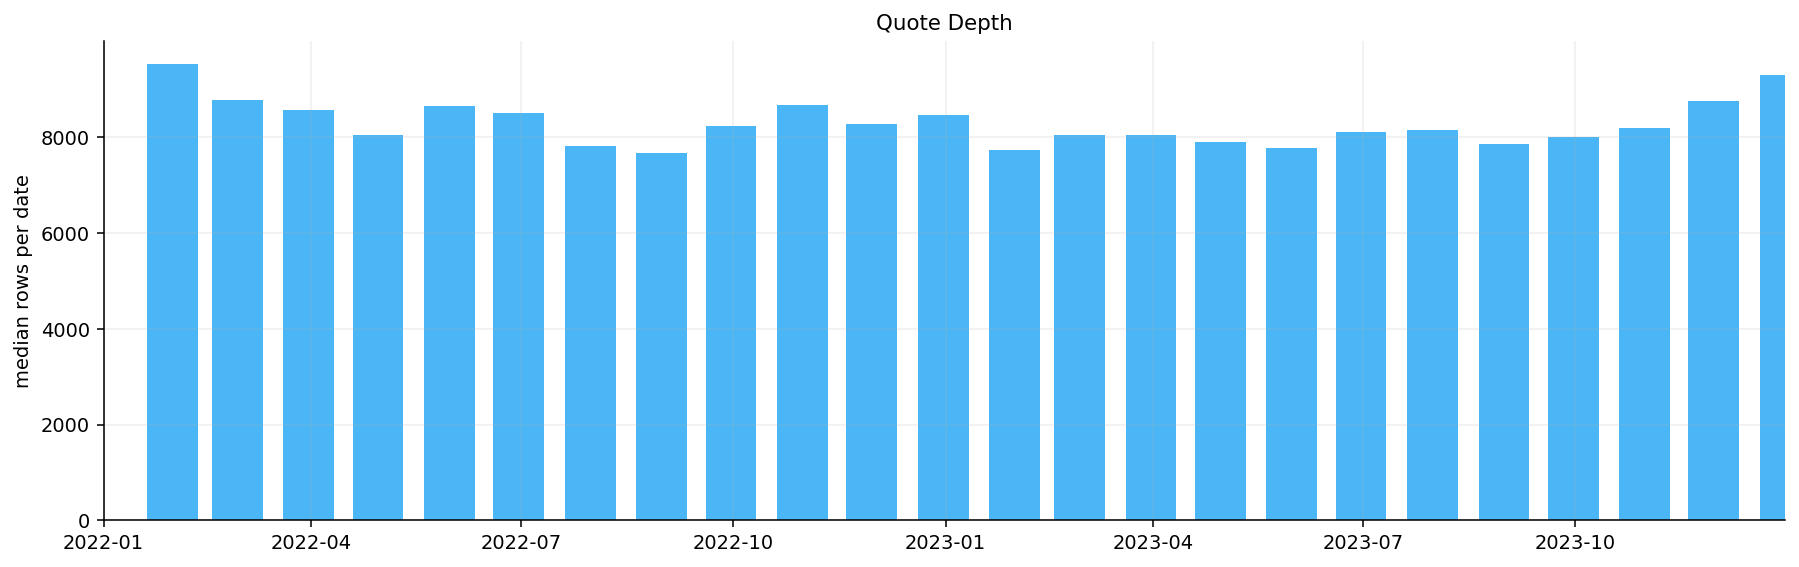

In [ ]:
fig, ax = plt.subplots(figsize=(13, 4.2))
ax.bar(monthly_depth.index, monthly_depth["median"], width=22, color=palette[0], alpha=0.72)
ax.set_ylabel("median rows per date")
ax.set_title("Quote Depth")
ax.set_xlim(start_date, end_date)
ax.grid(True, axis="y", alpha=0.20)
fig.tight_layout(pad=1.25)
plt.show()

The quote-depth plot shows that the calibration universe stays deep through the full sample. Monthly median rows per date usually sit in a stable band around several thousand quotes, with no collapse in market depth during the main stress windows.

This is important because daily calibration quality depends on cross-sectional support. If one month had only a few hundred usable rows per date, a bad model fit could simply reflect missing quotes. Here the panel is deep enough that poor fit has more economic meaning: if BSM underprices downside puts or if a jump model misses a tail, that is likely a model limitation rather than just a thin-data artifact.


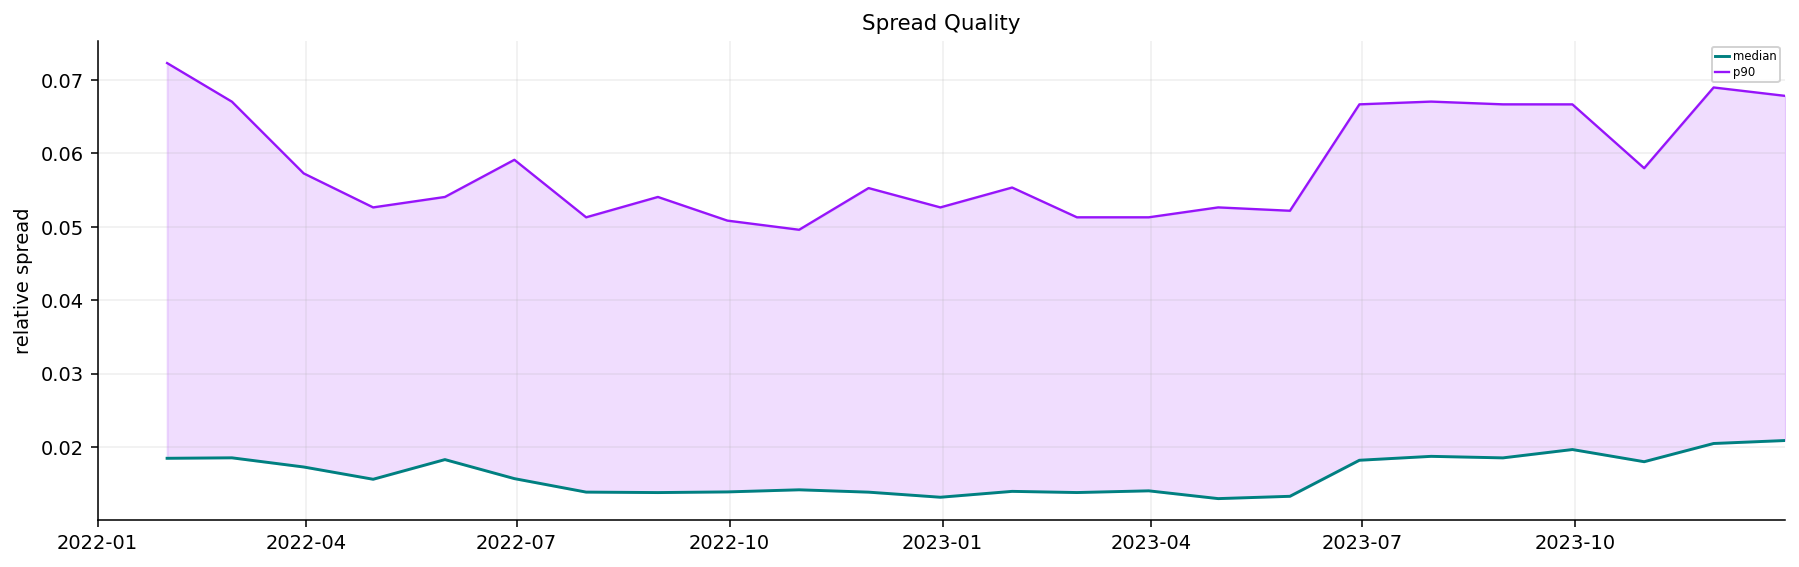

In [ ]:
fig, ax = plt.subplots(figsize=(13, 4.2))
ax.plot(monthly_spread.index, monthly_spread["median"], color=palette[3], lw=1.5, label="median")
ax.plot(monthly_spread.index, monthly_spread["p90"], color=palette[6], lw=1.2, label="p90")
ax.fill_between(monthly_spread.index, monthly_spread["median"].to_numpy(float), monthly_spread["p90"].to_numpy(float), color=palette[6], alpha=0.14)
ax.set_ylabel("relative spread")
ax.set_title("Spread Quality")
ax.set_xlim(start_date, end_date)
ax.legend(**legend_kw)
ax.grid(True, alpha=0.20)
fig.tight_layout(pad=1.25)
plt.show()

The spread-quality plot tells a more subtle story. The median relative spread stays low through most of the sample, while the 90th percentile is much higher and changes more visibly over time. This means the central option market remains liquid, but the outer parts of the surface carry real microstructure noise.

For calibration, that creates a tradeoff:

- If we use every quote equally, noisy wings can dominate the loss.
- If we remove too many wing quotes, we lose exactly the contracts that teach the model about skew and crash tails.
- If we use spread-aware weights, we can keep tail information while reducing the influence of unreliable quotes.

This project takes the third route. We keep a large panel but use quote quality inside the selection and calibration steps.


### 2.2 Representative OTM Quotes for Model Calibration

The next step builds an OTM-style calibration subset. The reason is tied to option-market microstructure. For a given strike and expiry, the OTM option is usually the more liquid and more informative quote:

- OTM puts are the natural downside-protection market.
- OTM calls are the natural upside-convexity market.
- Deep ITM options often have wider effective spreads and more parity noise.

The selection rule chooses one side per strike when possible. In forward log-moneyness terms,

$$
k = \log\left(\frac{K}{F}\right)
$$

negative $k$ means $K<F$, so puts are usually OTM. Positive $k$ means $K>F$, so calls are usually OTM. Around ATM, either side can be reasonable, so quote quality decides.

The row-selection process also buckets maturity and log-moneyness. This prevents the calibration panel from becoming a random collection of the most liquid ATM contracts. We want the model to see the center, the wings, short maturities, and longer maturities.


### 2.3 Daily Calibration Grid

The calibration grid is built around target maturities and target log-moneyness points:

$$
DTE^* \in \{14,21,30,45,60,75,90,105,120,150\}
$$

$$
k^* \in \{-0.30,-0.25,-0.20,\ldots,0,\ldots,0.25,0.30\}
$$

Each trading day is reduced to a representative grid, with roughly the same number of quotes per date. The goal is to create a stable calibration design where every date has a comparable cross-section, while avoiding a random information loss.

A useful way to think about it is that each date becomes a small surface-fitting problem. We are not asking the model to explain 8,000 quotes per day; many of those quotes are redundant. We ask it to explain a dense but controlled grid across maturity and moneyness.

The selection score has three main ingredients:

$$
\text{selection score}=0.003|DTE-DTE^*|+|k-k^*|+0.10\times \text{relative spread}
$$

The $|k-k^*|$ term keeps strikes near the target moneyness grid. The DTE term keeps expiries near the target maturities. The spread term favors cleaner quotes when two candidates are otherwise similar.


### 2.4 Why the Grid Uses Maturity and Moneyness Targets

A model can look better than it really is if the calibration sample is too concentrated near the most liquid region. ATM options are abundant and tight, so a naive sample could be dominated by the center of the surface. But the main differences among BSM, Merton, VG, Heston, and Bates live in the wings and term structure.

The daily grid is designed to force each model to answer three questions at the same time:

1. **Can it fit the center?** ATM and near-ATM options measure the main volatility level.
2. **Can it fit skew?** Negative log-moneyness puts measure downside crash premium.
3. **Can it fit term structure?** Multiple DTE targets measure how the distribution changes with horizon.

In matrix language, each date has a calibration design like:

$$
\mathcal{D}_t=\{(K_j,T_j,V_j^{mkt},s_j,w_j)\}_{j=1}^{170}
$$

The model maps a parameter vector to a price vector:

$$
\theta_t \mapsto \hat{\mathbf{V}}_t(\theta_t)=\left(\hat{V}_1(\theta_t),\ldots,\hat{V}_{170}(\theta_t)\right)
$$

The calibration problem compares this full vector against the market vector. This makes the later model tournament meaningful because each model sees the same shape challenge.


In [ ]:
def make_otm_quotes(q, min_dte=14.0, max_dte=150.0, min_vega=0.0, max_relative_spread=0.45, max_abs_log_moneyness=0.32, min_quotes_per_expiry=8, min_expiries_per_date=5):
    x = q.copy()
    rows = [{"step": "clean quotes", "rows": len(x), "removed": 0}]

    def keep(name, mask):
        nonlocal x
        before = len(x)
        x = x.loc[mask].copy()
        rows.append({"step": name, "rows": len(x), "removed": before - len(x)})

    keep("DTE window", x["dte_days"].between(float(min_dte), float(max_dte)))
    keep("log-moneyness window", x["log_moneyness"].abs().le(float(max_abs_log_moneyness)))
    keep("spread window", x["relative_spread"].between(0.0, float(max_relative_spread)))
    if "vega" in x.columns and float(min_vega) > 0.0:
        keep("vega floor", x["vega"].abs().ge(float(min_vega)))
    x["_row_id"] = np.arange(len(x), dtype=np.int64)
    otm_side = np.where(x["log_moneyness"] < -0.0125, "put", np.where(x["log_moneyness"] > 0.0125, "call", "either"))
    opt_side = np.where(x["option_type"].astype(str).str.lower().str.startswith("p"), "put", np.where(x["option_type"].astype(str).str.lower().str.startswith("c"), "call", "other"))
    x["type_penalty"] = np.where(otm_side == "either", 0, np.where(opt_side == otm_side, 0, 1))
    x["quote_score"] = x["relative_spread"].fillna(1.0) + 0.02 * x["log_moneyness"].abs()
    before = len(x)
    x = x.sort_values(["date", "expiry", "strike", "type_penalty", "quote_score"]).drop_duplicates(["date", "expiry", "strike"], keep="first").copy()
    rows.append({"step": "OTM side by strike", "rows": len(x), "removed": before - len(x)})
    x["dte_bucket"] = pd.cut(x["dte_days"], [0, 14, 30, 60, 90, 120, 180], include_lowest=True)
    x["log_moneyness_bucket"] = pd.cut(x["log_moneyness"], [-0.45, -0.30, -0.20, -0.12, -0.06, -0.02, 0.02, 0.06, 0.12, 0.20, 0.30, 0.45], include_lowest=True)
    keys = ["date", "expiry", "option_type", "dte_bucket", "log_moneyness_bucket"]
    x["cell_rows"] = x.groupby(keys, observed=True)["mid"].transform("size").fillna(1.0)
    expiry_rows = x.groupby(["date", "expiry"]).size().rename("expiry_rows")
    x = x.merge(expiry_rows.reset_index(), on=["date", "expiry"], how="left")
    before = len(x)
    x = x[x["expiry_rows"].ge(int(min_quotes_per_expiry))].copy()
    rows.append({"step": "expiry support", "rows": len(x), "removed": before - len(x)})
    date_expiries = x.groupby("date")["expiry"].nunique()
    good_dates = date_expiries[date_expiries.ge(int(min_expiries_per_date))].index
    before = len(x)
    x = x[x["date"].isin(good_dates)].copy()
    rows.append({"step": "date support", "rows": len(x), "removed": before - len(x)})
    return x, pd.DataFrame(rows)

In [ ]:
def calibration_grid_quotes(q, dte_targets, k_targets, min_quotes_per_date=120, max_quotes_per_date=200):
    pieces = []
    dte_targets = np.asarray(dte_targets, dtype=float)
    k_targets = np.asarray(k_targets, dtype=float)
    for d, day in q.groupby("date", sort=True):
        expiry_table = day.groupby("expiry", as_index=False).agg(dte=("dte_days", "median"), n=("mid", "size"))
        expiry_table = expiry_table[expiry_table["n"].ge(8)].copy()
        used_expiries = set()
        expiries = []
        for target in dte_targets:
            available = expiry_table[~expiry_table["expiry"].isin(used_expiries)].copy()
            if available.empty:
                break
            idx = (available["dte"] - target).abs().idxmin()
            expiry = available.loc[idx, "expiry"]
            expiries.append(expiry)
            used_expiries.add(expiry)
        ids = []
        targets = {}
        for expiry in expiries:
            g = day[day["expiry"].eq(expiry)].copy()
            used = set()
            for kt in k_targets:
                r = g[~g["_row_id"].isin(used)].copy()
                if r.empty:
                    break
                score = (r["log_moneyness"] - kt).abs() + 0.03 * r["relative_spread"].fillna(1.0)
                idx = score.idxmin()
                rid = int(r.loc[idx, "_row_id"])
                ids.append(rid)
                targets[rid] = (float(kt), float(g["dte_days"].median()))
                used.add(rid)
        selected = day[day["_row_id"].isin(ids)].copy()
        if len(selected) < int(min_quotes_per_date):
            remain = day[~day["_row_id"].isin(selected["_row_id"])].copy()
            if not remain.empty:
                dte_gap = np.min(np.abs(remain["dte_days"].to_numpy(float)[:, None] - dte_targets[None, :]), axis=1)
                k_gap = np.min(np.abs(remain["log_moneyness"].to_numpy(float)[:, None] - k_targets[None, :]), axis=1)
                remain["selection_score"] = 0.003 * dte_gap + k_gap + 0.10 * remain["relative_spread"].fillna(1.0)
                remain["selection_rank"] = remain["selection_score"].rank(method="first")
                selected = pd.concat([selected, remain[remain["selection_rank"].le(max(int(min_quotes_per_date) - len(selected), 0))]], ignore_index=False)
        if len(selected) > int(max_quotes_per_date):
            dte_gap = np.min(np.abs(selected["dte_days"].to_numpy(float)[:, None] - dte_targets[None, :]), axis=1)
            k_gap = np.min(np.abs(selected["log_moneyness"].to_numpy(float)[:, None] - k_targets[None, :]), axis=1)
            selected["selection_score"] = 0.003 * dte_gap + k_gap + 0.10 * selected["relative_spread"].fillna(1.0)
            selected["selection_rank"] = selected["selection_score"].rank(method="first")
            selected = selected[selected["selection_rank"].le(int(max_quotes_per_date))].copy()
        for rid, vals in targets.items():
            selected.loc[selected["_row_id"].eq(rid), "k_target"] = vals[0]
            selected.loc[selected["_row_id"].eq(rid), "dte_target"] = vals[1]
        pieces.append(selected)
    out = pd.concat(pieces, ignore_index=True) if pieces else q.iloc[:0].copy()
    out = out.drop(columns=[c for c in ["type_penalty", "quote_score", "selection_score", "selection_rank", "expiry_rows", "_row_id"] if c in out.columns])
    out["obs_weight"] = out["obs_weight"] * out["cell_rows"].clip(lower=1)
    for name in out.columns:
        dtype_name = str(out[name].dtype).lower()
        if dtype_name == "category" or "interval" in dtype_name:
            out[name] = out[name].astype(str)
    return out.reset_index(drop=True)

In [ ]:
target_dtes = np.array([14.0, 21.0, 30.0, 45.0, 60.0, 75.0, 90.0, 105.0, 120.0, 150.0])
k_targets = np.array([-0.30, -0.25, -0.20, -0.16, -0.12, -0.08, -0.04, -0.015, 0.0, 0.015, 0.04, 0.08, 0.12, 0.16, 0.20, 0.25, 0.30])
calib_path = cache_dir / "spx_calibration_quotes.parquet"
steps_path = calib_path.with_suffix(".steps.json")
calib_settings = {"method": "otm daily dte-k grid", "carry": clean_settings["carry"], "target_dtes": target_dtes.tolist(), "k_targets": k_targets.tolist(), "min_quotes_per_date": 120, "max_quotes_per_date": 200, "source_rows": int(len(clean_quotes))}
if calib_path.exists() and steps_path.exists() and same_settings(calib_path, calib_settings):
    calibration_quotes = pd.read_parquet(calib_path)
    selection_steps = pd.read_json(steps_path)
else:
    otm_quotes, selection_steps = make_otm_quotes(clean_quotes, min_dte=14.0, max_dte=150.0, min_vega=0.0, max_relative_spread=0.45, max_abs_log_moneyness=0.32, min_quotes_per_expiry=8, min_expiries_per_date=5)
    calibration_quotes = calibration_grid_quotes(otm_quotes, target_dtes, k_targets, min_quotes_per_date=120, max_quotes_per_date=200)
    calibration_quotes.to_parquet(calib_path, index=False)
    selection_steps.to_json(steps_path, orient="records", indent=2, date_format="iso")
    write_meta(calib_path, calib_settings, len(calibration_quotes))
daily_selection = calibration_quotes.groupby("date").size()
display(pd.DataFrame([{"clean_rows": len(clean_quotes), "calibration_rows": len(calibration_quotes), "dates": calibration_quotes["date"].nunique(), "avg_quotes_per_date": daily_selection.mean(), "median_quotes_per_date": daily_selection.median(), "min_quotes_per_date": daily_selection.min(), "max_quotes_per_date": daily_selection.max(), "median_cell_rows": calibration_quotes["cell_rows"].median()}]).round(2))
display(selection_steps)
display(calibration_quotes.groupby(["dte_bucket", "option_type"], observed=True)["cell_rows"].agg(["size", "sum", "median"]).reset_index().iloc[:24])

,clean_rows,calibration_rows,dates,avg_quotes_per_date,median_quotes_per_date,min_quotes_per_date,max_quotes_per_date,median_cell_rows
0,4164745,85850,505,170.000000,170.000000,170,170,17.000000


,step,rows,removed
0,clean quotes,4164745,0
1,DTE window,3296919,867826
2,log-moneyness window,3255684,41235
3,spread window,3255684,0
4,OTM side by strike,1790907,1464777
5,expiry support,1790907,0
6,date support,1790907,0


,dte_bucket,option_type,size,sum,median
0,"(120.0, 180.0]",call,6790,97724,11.000000
1,"(120.0, 180.0]",put,7235,163020,21.000000
2,"(14.0, 30.0]",call,9542,143294,14.000000
3,"(14.0, 30.0]",put,10875,179268,12.000000
4,"(30.0, 60.0]",call,8668,143318,13.000000
5,"(30.0, 60.0]",put,10117,204396,15.000000
6,"(60.0, 90.0]",call,7411,170186,19.000000
7,"(60.0, 90.0]",put,8212,252394,32.000000
8,"(90.0, 120.0]",call,8172,149247,15.000000
9,"(90.0, 120.0]",put,8828,233707,28.000000


The final SPX calibration panel has **85,850 rows**, exactly **170 quotes per date** across **505 dates**. The median cell-row count is **17**, which means the selected quote often represents a local bucket with meaningful quote support behind it.

This is a strong design for model comparison. Every daily fit sees the same quote count, so runtime and error comparisons are not distorted by one model fitting more rows than another. The model is also forced to face the whole shape of the surface: short maturity, medium maturity, downside puts, ATM options, and upside calls.

The selection steps show the largest reduction when we choose the OTM side by strike. That is expected because the raw panel contains both calls and puts at many strikes. Keeping the most informative side makes the daily grid cleaner and reduces parity duplication.


In [ ]:
date_counts = calibration_quotes.groupby("date").size()
daily_dates = date_counts[date_counts >= 120].index
weekly_dates = daily_dates[::5]
month_end_dates = calibration_quotes.groupby(calibration_quotes["date"].dt.to_period("M"))["date"].max().dropna().values
stress_dates = rows_by_date.sort_values(ascending=False).iloc[:20].index
sv_dates = daily_dates
main_day = date_counts.loc[daily_dates].sort_values(ascending=False).index[0]
day_quotes = calibration_quotes[calibration_quotes["date"].eq(main_day)].copy()
display(pd.DataFrame([{"daily_calibration_dates": len(daily_dates), "sv_calibration_dates": len(sv_dates), "main_day": main_day, "main_day_quotes": len(day_quotes)}]))

,daily_calibration_dates,sv_calibration_dates,main_day,main_day_quotes
0,505,505,2022-01-03,170


The rebalance/calibration date summary defines three date sets:

- **daily dates:** dates with enough calibration quotes,
- **weekly dates:** every fifth daily date,
- **monthly dates:** month-end quote dates,
- **stress dates:** dates with high realized volatility and drawdown pressure.

The main model calibration uses daily data for BSM and jump models. Stochastic-volatility models can be heavier, but here the design still fits them broadly enough for a serious comparison. The stress dates are useful because tail models should earn their complexity in bad markets, not only in average periods.


## 3) Characteristic Functions for Pricing Models

The characteristic function is the central object of the project. For a terminal log-price $X_T=\log S_T$, it is:

$$
\phi_T(u)=E^Q[e^{iuX_T}]
$$

The variable $u$ is not a market input like strike or maturity. It is a frequency. Low frequencies describe broad distribution shape. High frequencies describe fine details: sharp peaks, payoff kinks, and tail behavior.

For option pricing, the characteristic function is powerful because many models have difficult densities but simple transforms. A density answers: "how much probability mass sits near this log-price?" A characteristic function answers the same question indirectly by decomposing the distribution into complex waves.

There are three properties worth keeping in mind:

1. $\phi_T(0)=1$ for every valid distribution.
2. Derivatives of $\phi_T(u)$ around $u=0$ encode moments of $X_T$.
3. The rate at which $|\phi_T(u)|$ decays affects numerical convergence.

For example, a Gaussian log-price has a very fast-decaying characteristic function because its density is smooth. A jump model can have slower decay because the distribution has fatter tails or sharper central structure.


### 3.1 The Levy View Behind the Jump Models

The jump models in this notebook are easiest to understand through independent increments. If a log-return process has independent increments, the characteristic function over horizon $T$ often has the form:

$$
\phi_T(u)=\exp\left(T\psi(u)\right)
$$

where $\psi(u)$ is the characteristic exponent. This exponential-in-time structure is powerful because maturity changes become clean. Moving from 30 days to 60 days is not a new model; it is the same exponent multiplied by a longer time.

For BSM, the exponent is quadratic in $u$:

$$
\psi_{BSM}(u)=iu\left(r-q-\frac{1}{2}\sigma^2\right)-\frac{1}{2}\sigma^2u^2
$$

For Merton, the exponent adds a jump term:

$$
\psi_{Merton}(u)=iu\left(r-q+\omega-\frac{1}{2}\sigma^2\right)-\frac{1}{2}\sigma^2u^2+\lambda\left(e^{iu\mu_J-\frac{1}{2}\sigma_J^2u^2}-1\right)
$$

For VG, the exponent comes from the logarithm of the Gamma-time transform:

$$
\psi_{VG}(u)=iu(r-q+\omega)-\frac{1}{\nu}\log\left(1-i\theta\nu u+\frac{1}{2}\sigma^2\nu u^2\right)
$$

This exponent view explains why Fourier methods scale so well across models. The pricing code doesn't need to simulate paths or discretize a PDE for each new distribution. It only needs a function that returns $\phi_T(u)$ for complex $u$. Once the transform is available, direct integration, FFT, and COS all use the same numerical language.


### 3.2 BSM Characteristic Function

Under BSM, the risk-neutral log-price is normal:

$$
X_T=\log S_0+\left(r-q-\frac{1}{2}\sigma^2\right)T+\sigma\sqrt{T}Z
$$

where $Z\sim N(0,1)$. Its characteristic function is:

$$
\phi_{BSM}(u)=\exp\left(iu\left[\log S_0+\left(r-q-\frac{1}{2}\sigma^2\right)T\right]-\frac{1}{2}\sigma^2u^2T\right)
$$

Every term has a role:

- $\log S_0$ anchors the distribution at today's log spot.
- $(r-q-\frac{1}{2}\sigma^2)T$ is the risk-neutral log drift.
- $-\frac{1}{2}\sigma^2u^2T$ controls how quickly the transform decays as frequency rises.

The last term is why BSM is numerically easy in Fourier space. The magnitude decays roughly like $e^{-cu^2}$, which kills high-frequency oscillations quickly. That makes BSM a good reference model for checking whether the integration and FFT code are correct.


### 3.3 Merton Jump-Diffusion Characteristic Function

Merton adds compound Poisson jumps to the continuous diffusion. In log-return form, the model can be written as:

$$
X_T = \log S_0 + \left(r-q+\omega-\frac{1}{2}\sigma^2\right)T + \sigma W_T + \sum_{j=1}^{N_T}Y_j
$$

where:

- $N_T\sim \text{Poisson}(\lambda T)$ is the number of jumps,
- $Y_j\sim N(\mu_J,\sigma_J^2)$ is the jump size,
- $\lambda$ is jump intensity,
- $\omega$ is the martingale correction.

The martingale correction keeps the discounted stock price arbitrage-free:

$$
\omega=-\lambda\left(e^{\mu_J+\frac{1}{2}\sigma_J^2}-1\right)
$$

The characteristic function is:

$$
\phi_{Merton}(u)=\exp\left(iu\left[\log S_0+\left(r-q+\omega-\frac{1}{2}\sigma^2\right)T\right]-\frac{1}{2}\sigma^2u^2T+\lambda T\left(e^{iu\mu_J-\frac{1}{2}\sigma_J^2u^2}-1\right)\right)
$$

The first two pieces look like BSM. The extra jump term is:

$$
\lambda T\left(e^{iu\mu_J-\frac{1}{2}\sigma_J^2u^2}-1\right)
$$

This term changes the tails. If $\mu_J<0$, the average jump is downward, so OTM put prices rise. If $\sigma_J$ is large, jumps are more dispersed, so both tails become fatter. If $\lambda$ rises, jumps happen more frequently.

This gives a clear economic interpretation: Merton is useful when the market prices discrete crash risk that a smooth diffusion can't capture.


### 3.4 Variance Gamma Characteristic Function

Variance Gamma is one of the most important new models in this project because it represents a different way to create non-Gaussian returns. Instead of adding a finite number of normally distributed jumps to a diffusion, VG creates a **time-changed Brownian motion**.

A common representation is:

$$
X_T = \log S_0 + (r-q+\omega)T + \theta G_T + \sigma W_{G_T}
$$

where $G_T$ is a Gamma process. The random clock $G_T$ replaces calendar time with business time. When $G_T$ runs faster, returns move more. When it runs slower, returns move less. This creates heavy tails and excess kurtosis without needing a separate stochastic-volatility process.

The three parameters in the implementation are:

- $\sigma$: diffusion scale under the Gamma clock,
- $\theta$: skew/drift under the Gamma clock,
- $\nu$: variance of the Gamma clock, often interpreted as the activity or randomness of business time.

The characteristic function used here is:

$$
\phi_{VG}(u)=\exp\left(iu[\log S_0+(r-q+\omega)T]\right)\left(1-i\theta\nu u+\frac{1}{2}\sigma^2\nu u^2\right)^{-T/\nu}
$$

The martingale correction is:

$$
\omega=\frac{1}{\nu}\log\left(1-\theta\nu-\frac{1}{2}\sigma^2\nu\right)
$$

The correction is valid only if:

$$
1-\theta\nu-\frac{1}{2}\sigma^2\nu>0
$$

That inequality matters in calibration. If the optimizer proposes invalid parameters, the characteristic function stops being a valid risk-neutral stock-price transform. The code therefore rejects invalid VG parameter sets.

For example, if $\nu$ becomes too large while $\sigma$ and $\theta$ are also large, the martingale term can fail. That isn't a minor numerical issue; it means the model no longer defines a valid discounted stock price under the chosen parameterization.


### 3.5 Why VG Is Economically Different from Merton

Merton says jumps arrive as isolated events. VG says the market clock itself is random. That difference changes how we interpret tails.

In Merton, the number of jumps over $T$ is discrete:

$$
N_T\in\{0,1,2,\ldots\}
$$

and most short intervals may have no jump at all if $\lambda T$ is small. The distribution is a mixture of normal distributions conditional on jump count.

In VG, the Gamma clock $G_T$ is continuous and random:

$$
G_T\sim \Gamma\left(\frac{T}{\nu},\nu\right)
$$

with:

$$
E[G_T]=T
$$

$$
Var(G_T)=\nu T
$$

So $\nu$ controls how unstable business time is. If $\nu$ is small, $G_T$ is close to calendar time and the process is closer to a diffusion. If $\nu$ is large, the clock can run much faster or slower than calendar time, creating fat tails.

The conditional return given $G_T=g$ is normal:

$$
X_T\mid G_T=g \sim N(\theta g,\sigma^2 g)
$$

Unconditionally, we average over many possible values of $g$. That mixture produces skewness and kurtosis. Negative $\theta$ shifts large-business-time outcomes to the left, which is useful for equity-index downside skew.

This is why VG is a meaningful model in a Fourier project. It has no simple Black-Scholes-style option formula, but its characteristic function is compact. Fourier methods make it almost as operational as BSM once the transform is implemented.


### 3.6 Heston and Bates in Fourier Form

Project 11 explained Heston and Bates as volatility models, so here we focus on the transform side. Heston gives a closed-form characteristic function even though the option price itself doesn't have a simple elementary closed form.

The Heston variance process is:

$$
dv_t=\kappa(\theta-v_t)dt+\xi\sqrt{v_t}\,dW_t^v
$$

and the stock process has correlated shocks:

$$
dS_t=(r-q)S_tdt+\sqrt{v_t}S_t\,dW_t^S
$$

$$
dW_t^S dW_t^v = \rho dt
$$

The characteristic function has exponential-affine form:

$$
\phi_{Heston}(u)=\exp\left(C(u,T)+D(u,T)v_0+iu\log S_0\right)
$$

The implementation computes the $C$ and $D$ terms through complex-valued expressions involving $\kappa$, $\theta$, $\xi$, $\rho$, and $v_0$. The important financial meaning is:

- $v_0$ controls today's variance level.
- $\theta$ controls long-run variance.
- $\kappa$ controls the speed of mean reversion.
- $\xi$ controls volatility of volatility.
- $\rho$ controls skew through the leverage effect.

Bates multiplies the Heston transform by a Merton jump transform. That means Bates has stochastic variance and finite-activity jumps in the same risk-neutral distribution:

$$
\phi_{Bates}(u)=\phi_{Heston}(u; r+\omega,q)\times \exp\left(\lambda T\left(e^{iu\mu_J-\frac{1}{2}\sigma_J^2u^2}-1\right)\right)
$$

In calibration, Bates is flexible but expensive and easier to overfit. That is why this project compares it against simpler models using residuals, tail errors, and runtime, not only headline RMSE.


### 3.7 Risk-Neutral Drift Corrections Across Models

Every model in this project must satisfy the risk-neutral martingale condition:

$$
E^Q[S_T]=S_0e^{(r-q)T}
$$

Equivalently, the discounted ex-dividend stock price must have no arbitrage drift. Since most models are written for log-price, this condition usually appears as a drift correction.

For an exponential return model,

$$
S_T=S_0\exp(X_T)
$$

we need:

$$
E^Q[e^{X_T}]=e^{(r-q)T}
$$

In characteristic-function language, this is connected to evaluating the transform at $u=-i$ because:

$$
\phi_X(-i)=E[e^{i(-i)X_T}]=E[e^{X_T}]
$$

That is why terms like $\phi(-i)$ appear in direct Fourier pricing. The transform at a complex argument is not a random accident; it is exactly the moment needed to price the stock-weighted part of the payoff.

Merton and VG need explicit drift corrections because jumps or random time changes change the expected exponential growth of the stock. Without the correction, the model might fit option shapes but violate the forward price. In calibration, this would be dangerous because the optimizer could use jumps to explain carry errors.

The practical design is:

1. infer or attach $r$ and $q$ consistently,
2. build a risk-neutral characteristic function with the right martingale correction,
3. price options from that transform,
4. attribute residual errors to model shape, not to a broken forward relation.

This is also why forward log-moneyness is used in the cleaned SPX panel. We want the surface to be centered around the forward, because the forward is the risk-neutral anchor.


In [ ]:
@njit
def bsm_cf(u, s, r, q, tau, sigma):
    return np.exp(1j * u * (np.log(s) + (r - q - 0.5 * sigma * sigma) * tau) - 0.5 * sigma * sigma * u * u * tau)

@njit
def merton_cf(u, s, r, q, tau, sigma, lam, muj, sj):
    omega = -lam * (np.exp(muj + 0.5 * sj * sj) - 1.0)
    return np.exp(1j * u * (np.log(s) + (r - q + omega - 0.5 * sigma * sigma) * tau) - 0.5 * sigma * sigma * u * u * tau + lam * tau * (np.exp(1j * u * muj - 0.5 * sj * sj * u * u) - 1.0))

@njit
def vg_cf(u, s, r, q, tau, sigma, theta, nu):
    mart = 1.0 - theta * nu - 0.5 * sigma * sigma * nu
    if mart <= 0.0:
        return np.nan + 1j * np.nan
    omega = np.log(mart) / nu
    return np.exp(1j * u * (np.log(s) + (r - q + omega) * tau)) * (1.0 - 1j * theta * nu * u + 0.5 * sigma * sigma * nu * u * u) ** (-tau / nu)

@njit
def heston_cf(u, s, r, q, tau, v0, kappa, theta, sigv, rho):
    rho = min(max(rho, -0.999), 0.999)
    d = np.sqrt((rho * sigv * 1j * u - kappa) ** 2 + sigv * sigv * (1j * u + u * u))
    g = (kappa - rho * sigv * 1j * u - d) / (kappa - rho * sigv * 1j * u + d)
    expdt = np.exp(-d * tau)
    c = 1j * u * (np.log(s) + (r - q) * tau) + (kappa * theta / (sigv * sigv)) * ((kappa - rho * sigv * 1j * u - d) * tau - 2.0 * np.log((1.0 - g * expdt) / (1.0 - g)))
    dcoef = ((kappa - rho * sigv * 1j * u - d) / (sigv * sigv)) * ((1.0 - expdt) / (1.0 - g * expdt))
    return np.exp(c + dcoef * v0)

@njit
def bates_cf(u, s, r, q, tau, v0, kappa, theta, sigv, rho, lam, muj, sj):
    omega = -lam * (np.exp(muj + 0.5 * sj * sj) - 1.0)
    jump = np.exp(lam * tau * (np.exp(1j * u * muj - 0.5 * sj * sj * u * u) - 1.0))
    return heston_cf(u, s, r + omega, q, tau, v0, kappa, theta, sigv, rho) * jump

In [ ]:
def params_for_model(name):
    values = {
        "BSM": np.array([0.20]),
        "Merton": np.array([0.18, 0.70, -0.06, 0.22]),
        "VG": np.array([0.18, -0.06, 0.25]),
        "Heston": np.array([0.04, 2.0, 0.04, 0.60, -0.55]),
        "Bates": np.array([0.04, 2.0, 0.04, 0.60, -0.55, 0.70, -0.06, 0.22]),
    }
    return values[name]

@njit
def cf_model(model_id, u, params, s, r, q, tau):
    if model_id == 1:
        return merton_cf(u, s, r, q, tau, params[0], params[1], params[2], params[3])
    if model_id == 2:
        return vg_cf(u, s, r, q, tau, params[0], params[1], params[2])
    if model_id == 3:
        return heston_cf(u, s, r, q, tau, params[0], params[1], params[2], params[3], params[4])
    if model_id == 4:
        return bates_cf(u, s, r, q, tau, params[0], params[1], params[2], params[3], params[4], params[5], params[6], params[7])
    return bsm_cf(u, s, r, q, tau, params[0])

In [ ]:
u_grid = np.linspace(0.0, 90.0, 361)
s0 = float(day_quotes["spot"].median())
r0 = float(day_quotes["rate"].median())
q0 = float(day_quotes["dividend_yield"].median())
tau0 = 60 / ann_days
model_names = ["BSM", "Merton", "VG", "Heston", "Bates"]
model_ids = {"BSM": 0, "Merton": 1, "VG": 2, "Heston": 3, "Bates": 4}
cf_rows = []
for name in model_names:
    params = params_for_model(name)
    for u in u_grid:
        phi = cf_model(model_ids[name], float(u), params, s0, r0, q0, tau0)
        cf_rows.append({"model": name, "u": u, "magnitude": abs(phi)})
cf_fingerprint = pd.DataFrame(cf_rows)
display(cf_fingerprint.groupby("model")["magnitude"].agg(["min", "median", "max"]).reset_index().round(6))

,model,min,median,max
0,BSM,0.000000,0.001290,1.000000
1,Bates,0.001874,0.051867,1.000000
2,Heston,0.002103,0.058188,1.000000
3,Merton,0.000000,0.004071,1.000000
4,VG,0.098879,0.232223,1.000000


The characteristic-function fingerprint table gives a quick numerical sanity check. Every model has maximum magnitude equal to **1**, because $|\phi(0)|=1$. The models differ in how quickly the magnitude decays.

BSM and Merton reach values very close to zero at high frequencies. VG has a much larger minimum magnitude, about **0.099**, and a median magnitude around **0.232**. This tells us VG keeps more high-frequency content alive over the same $u$ range. That is one reason VG can be more delicate for COS truncation and integration width choices.

Heston and Bates sit between these extremes. Their transforms decay more slowly than BSM but not as slowly as VG in this test. This is consistent with their richer skew and tail structure.


## 4) Recovering a Density from the Characteristic Function

Fourier inversion lets us recover the density from the characteristic function. If $X_T$ has density $f(x)$ and characteristic function $\phi(u)$, then:

$$
f(x)=\frac{1}{2\pi}\int_{-\infty}^{\infty}e^{-iux}\phi(u)\,du
$$

Because valid densities are real-valued, we can use symmetry and compute:

$$
f(x)=\frac{1}{\pi}\int_0^{\infty}\operatorname{Re}\left(e^{-iux}\phi(u)\right)du
$$

The code approximates this integral on a finite grid:

$$
f(x_j)\approx \sum_{m=1}^{N}\operatorname{Re}\left(e^{-iu_mx_j}\phi(u_m)\right)\frac{\Delta u}{\pi}
$$

where:

- $x_j$ is a log-price grid point,
- $u_m$ is a Fourier frequency,
- $\Delta u$ is the spacing between frequency nodes,
- $N$ is the number of integration nodes,
- $u_{max}=N\Delta u$ is the integration cutoff.

The density is then normalized numerically so the area under it is close to one. This step is mainly diagnostic. We don't need to recover the full density to price options, but plotting the implied density makes the models much easier to understand.


### 4.1 Oscillatory Integrals and Numerical Choices

Fourier inversion integrals are oscillatory. The factor

$$
e^{-iux}=\cos(ux)-i\sin(ux)
$$

keeps changing sign as $u$ grows. The integral can converge because positive and negative oscillations cancel out. Numerically, that cancellation is both useful and dangerous.

If the grid is too coarse, we miss oscillations and the cancellation is wrong. If the cutoff is too low, we truncate meaningful high-frequency information. If the transform decays slowly, a large region of the frequency domain can still contribute to the price.

This is why the code uses midpoint-style frequency nodes in direct integration:

$$
u_j=(j-0.5)\Delta u
$$

rather than only endpoint nodes. Midpoint integration is often more stable for oscillatory integrals because it avoids evaluating exactly at problematic boundaries and samples the interior of each frequency bin.

The numerical error has two main parts:

$$
\text{total error}=\text{truncation error}+\text{discretization error}
$$

Truncation error comes from cutting the integral at $u_{max}$. Discretization error comes from using a finite grid between $0$ and $u_{max}$. Direct integration is accurate when both are small, but making both small is expensive.


In [ ]:
@njit
def density_from_cf(model_id, params, x_grid, s, r, q, tau, u_max, n):
    out = np.empty(x_grid.size)
    du = u_max / n
    for i in range(x_grid.size):
        x = x_grid[i]
        val = 0.0
        for j in range(1, n + 1):
            u = (j - 0.5) * du
            val += np.real(np.exp(-1j * u * x) * cf_model(model_id, u, params, s, r, q, tau)) * du / np.pi
        out[i] = max(val, 0.0)
    return out

x_grid = np.linspace(np.log(s0) - 0.45, np.log(s0) + 0.35, 420)
density_rows = []
for name in model_names:
    params = params_for_model(name)
    d = density_from_cf(model_ids[name], params, x_grid, s0, r0, q0, tau0, 160.0, 768)
    area = np.trapezoid(d, x_grid)
    if area > 0:
        d = d / area
    for x, y in zip(x_grid, d):
        density_rows.append({"model": name, "x": x, "density": y})
cf_density = pd.DataFrame(density_rows)

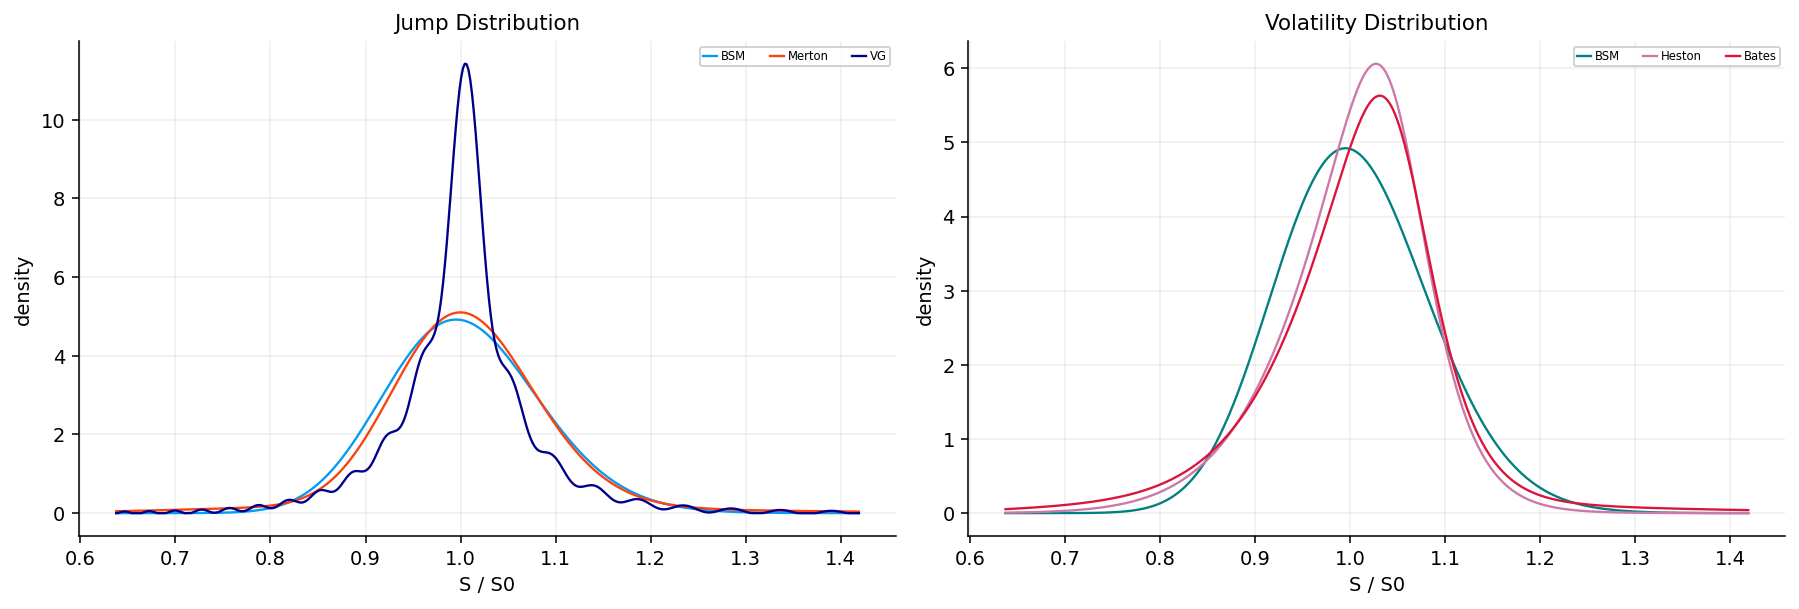

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
for i, name in enumerate(["BSM", "Merton", "VG"]):
    g = cf_density[cf_density["model"].eq(name)]
    axes[0].plot(np.exp(g["x"]) / s0, g["density"], lw=1.2, color=palette[i % len(palette)], label=name)
for i, name in enumerate(["BSM", "Heston", "Bates"]):
    g = cf_density[cf_density["model"].eq(name)]
    axes[1].plot(np.exp(g["x"]) / s0, g["density"], lw=1.2, color=palette[(i + 3) % len(palette)], label=name)
axes[0].set_xlabel("S / S0")
axes[0].set_ylabel("density")
axes[0].set_title("Jump Distribution")
axes[1].set_xlabel("S / S0")
axes[1].set_ylabel("density")
axes[1].set_title("Volatility Distribution")
axes[0].legend(ncol=3, **legend_kw)
axes[1].legend(ncol=3, **legend_kw)
fig.tight_layout(pad=1.25, h_pad=1.0, w_pad=1.0)
plt.show()

The density plots show why the models price wings differently.

In the jump-distribution panel, BSM has the sharpest central peak and thinnest tails. Merton spreads probability mass away from the center because jumps create large moves that the Gaussian model assigns too little probability to. VG also fattens the distribution but in a different way. It changes the shape continuously through random business time rather than through a finite jump count.

In the volatility-distribution panel, Heston and Bates shift mass and change the tail shape relative to BSM. Bates combines the stochastic-volatility skew with jump risk, so its density can allocate more probability to left-tail outcomes while still keeping a realistic center.

This density view is not a calibration result yet; it uses illustrative parameters. But it explains the later calibration behavior. BSM will struggle with OTM puts because its tail is too thin. Jump and SV models have more ways to put probability into the crash region.


## 5) Direct Fourier Integration

Direct Fourier pricing is the slowest of the three main methods, but it is the cleanest benchmark. The call price can be written using two risk-neutral probabilities:

$$
C_0=S_0e^{-qT}P_1-Ke^{-rT}P_2
$$

Here:

- $P_2$ is the risk-neutral probability that the option finishes ITM, adjusted through the log-price distribution.
- $P_1$ is a stock-measure probability, meaning it weights states by the stock payoff contribution.

Both probabilities can be computed from the characteristic function:

$$
P_1=\frac{1}{2}+\frac{1}{\pi}\int_0^{\infty}\operatorname{Re}\left(\frac{e^{-iu\log K}\phi(u-i)}{iu\phi(-i)}\right)du
$$

$$
P_2=\frac{1}{2}+\frac{1}{\pi}\int_0^{\infty}\operatorname{Re}\left(\frac{e^{-iu\log K}\phi(u)}{iu}\right)du
$$

The term $\phi(u-i)$ appears because the payoff contains $S_T=e^{X_T}$, so pricing the stock-weighted part requires shifting the transform into the complex plane. The denominator $\phi(-i)$ normalizes that stock-weighted transform.

Numerically, direct integration approximates these integrals as sums over $u_1,\ldots,u_N$:

$$
P_2\approx \frac{1}{2}+\sum_{m=1}^{N}\frac{\Delta u}{\pi}\operatorname{Re}\left(\frac{e^{-iu_m\log K}\phi(u_m)}{iu_m}\right)
$$

and similarly for $P_1$. The result is accurate when $u_{max}$ is high enough and $N$ is large enough. It is slow because we repeat the full integral for every strike.

For example, pricing 1,000 strikes means 1,000 separate oscillatory integrations. That is fine for validation, but too expensive for daily calibration across thousands of quotes and several models.


### 5.1 Deriving the P1 and P2 Logic

The direct formula can look mysterious if we only write the final $P_1$ and $P_2$ equations. The clean way to see it is to split the call payoff into two pieces:

$$
(S_T-K)^+=S_T\mathbf{1}_{\{S_T>K\}}-K\mathbf{1}_{\{S_T>K\}}
$$

Discounting gives:

$$
C_0=e^{-rT}E^Q[S_T\mathbf{1}_{\{S_T>K\}}]-Ke^{-rT}Q(S_T>K)
$$

The second probability is the easier one:

$$
P_2=Q(S_T>K)=Q(X_T>\log K)
$$

The first term is a stock-weighted probability. We can rewrite it as:

$$
e^{-rT}E^Q[S_T\mathbf{1}_{\{S_T>K\}}]=S_0e^{-qT}P_1
$$

where $P_1$ is a probability under a measure that weights states by $S_T$. That is why $P_1$ is not the same as $P_2$. $P_2$ asks how likely the option finishes ITM. $P_1$ asks how much the stock-value-weighted distribution contributes in those ITM states.

For example, suppose two outcomes are both ITM. One outcome has $S_T$ barely above $K$, and another has $S_T$ far above $K$. $P_2$ treats both as ITM events. $P_1$ gives more weight to the second because the stock payoff part is larger. This is exactly why the call formula needs two terms.

Fourier inversion gives both probabilities from the same characteristic function. $P_2$ uses $\phi(u)$ directly. $P_1$ uses $\phi(u-i)$ because multiplying by $S_T=e^{X_T}$ shifts the transform.


In [ ]:
@njit
def direct_call(model_id, params, s, k, r, q, tau, n, u_max):
    du = u_max / n
    phi_mi = cf_model(model_id, -1j, params, s, r, q, tau)
    p1 = 0.5
    p2 = 0.5
    log_k = np.log(k)
    for j in range(1, n + 1):
        u = (j - 0.5) * du
        p1 += du / np.pi * np.real(np.exp(-1j * u * log_k) * cf_model(model_id, u - 1j, params, s, r, q, tau) / (1j * u * phi_mi))
        p2 += du / np.pi * np.real(np.exp(-1j * u * log_k) * cf_model(model_id, u, params, s, r, q, tau) / (1j * u))
    return max(s * np.exp(-q * tau) * p1 - k * np.exp(-r * tau) * p2, 0.0)

@njit
def direct_batch(model_id, params, s, strikes, r, q, tau, n, u_max):
    out = np.empty(strikes.size)
    for i in range(strikes.size):
        out[i] = direct_call(model_id, params, s, strikes[i], r, q, tau, n, u_max)
    return out

@njit
def direct_grid(model_id, params, s, strikes, r, q, tau, n, u_max):
    du = u_max / n
    phi_mi = cf_model(model_id, -1j, params, s, r, q, tau)
    p1 = np.full(strikes.size, 0.5)
    p2 = np.full(strikes.size, 0.5)
    for j in range(1, n + 1):
        u = (j - 0.5) * du
        a1 = cf_model(model_id, u - 1j, params, s, r, q, tau) / (1j * u * phi_mi)
        a2 = cf_model(model_id, u, params, s, r, q, tau) / (1j * u)
        weight = du / np.pi
        for i in range(strikes.size):
            e = np.exp(-1j * u * np.log(strikes[i]))
            p1[i] += weight * np.real(e * a1)
            p2[i] += weight * np.real(e * a2)
    out = np.empty(strikes.size)
    stock_disc = s * np.exp(-q * tau)
    bond_disc = np.exp(-r * tau)
    for i in range(strikes.size):
        out[i] = max(stock_disc * p1[i] - strikes[i] * bond_disc * p2[i], 0.0)
    return out

In [ ]:
strike_grid = np.linspace(0.75, 1.25, 1000) * s0
tau_grid = np.array([30, 60, 120]) / ann_days
direct_rows = []
for tau in tau_grid:
    params = np.array([0.22])
    px = direct_grid(0, params, s0, strike_grid, r0, 0.0, float(tau), 2048, 180.0)
    closed = np.asarray(bsm_price("call", s0, strike_grid, tau, params[0], r0, 0.0), dtype=float)
    for k, a, b in zip(strike_grid, px, closed):
        direct_rows.append({"tau": tau, "strike": k, "direct_price": a, "closed_price": b, "price_error": a - b, "abs_error": abs(a - b)})
direct_validation = pd.DataFrame(direct_rows)
display(direct_validation.groupby("tau")["abs_error"].agg(["max", "median"]).reset_index().round(10))

,tau,max,median
0,0.082136,0.000000,0.000000
1,0.164271,0.000000,0.000000
2,0.328542,0.000000,0.000000


The BSM direct-integration validation is perfect to displayed precision. The maximum and median absolute errors are shown as **0.0000000000** across the 30-day, 60-day, and 120-day maturities.

This matters because BSM has a closed-form price. If the direct Fourier formula failed here, every later model comparison would be suspect. The zero error tells us that the $P_1/P_2$ integrals, transform shift $u-i$, discounting, and strike handling are consistent with the standard BSM formula.


In [ ]:
cut_rows = []
for cutoff in [60.0, 90.0, 120.0, 160.0, 220.0]:
    px = direct_grid(0, np.array([0.22]), s0, strike_grid, r0, 0.0, 60 / ann_days, 1536, cutoff)
    closed = np.asarray(bsm_price("call", s0, strike_grid, 60 / ann_days, 0.22, r0, 0.0), dtype=float)
    cut_rows.append({"u_max": cutoff, "max_abs_error": np.max(np.abs(px - closed)), "median_abs_error": np.median(np.abs(px - closed))})
node_rows = []
for nodes in [256, 512, 1024, 2048, 4096]:
    px = direct_grid(0, np.array([0.22]), s0, strike_grid, r0, 0.0, 60 / ann_days, nodes, 180.0)
    closed = np.asarray(bsm_price("call", s0, strike_grid, 60 / ann_days, 0.22, r0, 0.0), dtype=float)
    node_rows.append({"nodes": nodes, "max_abs_error": np.max(np.abs(px - closed)), "median_abs_error": np.median(np.abs(px - closed))})
direct_cutoff = pd.DataFrame(cut_rows)
direct_nodes = pd.DataFrame(node_rows)
display(direct_cutoff.round(10))
display(direct_nodes.round(10))

,u_max,max_abs_error,median_abs_error
0,60.000000,0.000017,0.000011
1,90.000000,0.000000,0.000000
2,120.000000,0.000000,0.000000
3,160.000000,0.000000,0.000000
4,220.000000,0.000000,0.000000


,nodes,max_abs_error,median_abs_error
0,256,0.000000,0.000000
1,512,0.000000,0.000000
2,1024,0.000000,0.000000
3,2048,0.000000,0.000000
4,4096,0.000000,0.000000


The cutoff and node tests show that direct integration is very stable in this BSM check. With $u_{max}=60$, the maximum absolute error is only about **0.000017**. Once the cutoff reaches 90 or more, the reported error falls to zero at table precision. Increasing nodes from 256 to 4096 also gives zero displayed error in this setup.

This result is model-dependent. BSM is smooth and easy. VG and some jump-SV parameter sets can need a larger cutoff because the transform decays more slowly and the density/payoff interaction contains sharper features. So the direct integration test should be read as a sanity check, not as proof that every model will be equally easy.


In [ ]:
def merton_series_call(s, k, r, q, tau, sigma, lam, muj, sj, n_max=60):
    df = math.exp(-r * tau)
    forward = s * math.exp((r - q) * tau)
    jump_comp = math.exp(muj + 0.5 * sj * sj) - 1.0
    px = 0.0
    weight = math.exp(-lam * tau)
    for n in range(n_max + 1):
        if n > 0:
            weight *= lam * tau / n
        f_n = forward * math.exp(-lam * jump_comp * tau + n * muj + 0.5 * n * sj * sj)
        sig_n = math.sqrt(max(sigma * sigma + n * sj * sj / max(tau, 1e-12), 1e-12))
        px += weight * float(bsm_price("call", s, k, tau, sig_n, r, q, forward=f_n, discount_factor=df))
    return px

merton_params = params_for_model("Merton")
merton_direct = direct_grid(1, merton_params, s0, strike_grid, r0, 0.0, 60 / ann_days, 4096, 220.0)
merton_series = np.array([merton_series_call(s0, k, r0, 0.0, 60 / ann_days, merton_params[0], merton_params[1], merton_params[2], merton_params[3], n_max=80) for k in strike_grid])
merton_validation = pd.DataFrame({"strike": strike_grid, "direct": merton_direct, "series": merton_series, "abs_error": np.abs(merton_direct - merton_series)})
display(merton_validation["abs_error"].agg(["max", "median"]).to_frame("Merton direct vs series").T.round(8))

,max,median
Merton direct vs series,0.000000,0.000000


Merton gives another useful validation because it has an independent series representation. Conditional on $n$ jumps, the terminal log-price is normal with adjusted mean and variance. The call price can be written as a Poisson-weighted mixture of BSM prices:

$$
C_{Merton}=\sum_{n=0}^{\infty}e^{-\lambda T}\frac{(\lambda T)^n}{n!}C_{BSM}(F_n,\sigma_n)
$$

where the conditional forward and volatility are adjusted by the number of jumps:

$$
F_n=F\exp\left(-\lambda\kappa_JT+n\mu_J+\frac{1}{2}n\sigma_J^2\right)
$$

$$
\sigma_n=\sqrt{\sigma^2+\frac{n\sigma_J^2}{T}}
$$

and

$$
\kappa_J=e^{\mu_J+\frac{1}{2}\sigma_J^2}-1
$$

The direct Fourier Merton prices match the series prices to displayed precision. This is a strong second check because the validation is no longer just against BSM. It verifies that the jump characteristic function, martingale correction, and integration formula work together correctly.


## 6) Carr-Madan FFT

Direct integration prices one strike at a time. Carr-Madan FFT changes the problem by pricing a whole grid of log-strikes at once. The core difficulty is that the call payoff is not square-integrable in strike space because call prices don't decay fast enough as log-strike goes to $-\infty$. The method fixes this by damping the call price.

Let log-strike be:

$$
k=\log K
$$

and define the damped call:

$$
c_{\alpha}(k)=e^{\alpha k}C(k)
$$

where $\alpha>0$ is the damping parameter. Multiplying by $e^{\alpha k}$ makes the transformed function behave better under Fourier integration. The Fourier transform of the damped call can be written as:

$$
\psi(u)=\frac{e^{-rT}\phi(u-i(\alpha+1))}{\alpha^2+\alpha-u^2+i(2\alpha+1)u}
$$

The denominator comes from transforming the call payoff. The shifted characteristic function $\phi(u-i(\alpha+1))$ appears because damping and payoff growth shift the complex argument.

Then the price is recovered by inverse transform:

$$
C(k)=\frac{e^{-\alpha k}}{\pi}\int_0^{\infty}\operatorname{Re}\left(e^{-iuk}\psi(u)\right)du
$$

The FFT enters because this integral is evaluated on an evenly spaced frequency grid and an evenly spaced log-strike grid. If:

$$
u_j=j\eta,\qquad j=0,1,\ldots,N-1
$$

and

$$
k_m=b+m\lambda,\qquad m=0,1,\ldots,N-1
$$

then the grids must satisfy:

$$
\lambda\eta=\frac{2\pi}{N}
$$

This relation is the price of speed. FFT gives all strikes at once, but the strikes are fixed by the frequency spacing. If the market strikes don't fall exactly on the FFT grid, we interpolate.


### 6.1 The Discrete FFT Approximation

The continuous Carr-Madan price recovery is:

$$
C(k)=\frac{e^{-\alpha k}}{\pi}\int_0^{\infty}\operatorname{Re}\left(e^{-iuk}\psi(u)\right)du
$$

The implementation replaces the integral with a weighted sum:

$$
C(k_m)\approx \frac{e^{-\alpha k_m}}{\pi}\sum_{j=0}^{N-1}\operatorname{Re}\left(e^{-iu_jk_m}\psi(u_j)\right)\eta w_j
$$

where $u_j=j\eta$ and $w_0=1/2$ is the trapezoid endpoint weight. The log-strike grid is:

$$
k_m=b+m\lambda
$$

Substitute the grid definitions:

$$
e^{-iu_jk_m}=e^{-ij\eta(b+m\lambda)}=e^{-ij\eta b}e^{-ijm\eta\lambda}
$$

If $\eta\lambda=2\pi/N$, then:

$$
e^{-ijm\eta\lambda}=e^{-2\pi ijm/N}
$$

That last term is exactly the discrete Fourier transform kernel. This is the reason the algorithm becomes fast. We are not changing the pricing formula; we are choosing grids so the sum becomes an FFT.

The start point $b$ determines where the log-strike grid begins. In the implementation, the grid is centered around $\log S$ so the market strike region sits inside the computed grid. After FFT pricing, the market strike prices are obtained by interpolation.


### 6.2 FFT Grid Tradeoff in Financial Terms

The FFT computes prices on a log-strike grid, not exactly on the market strikes. That means the final market price is usually an interpolation:

$$
\hat{C}(K^{mkt})=\text{Interp}\left(\{K_m,C(K_m)\}_{m=0}^{N-1},K^{mkt}\right)
$$

So the total FFT error contains:

$$
\text{FFT error}=\text{transform truncation error}+\text{quadrature error}+\text{strike interpolation error}
$$

In an idealized pricing library, FFT is excellent when we need a whole smooth grid of strikes for one maturity and one parameter set. It is less convenient when every option quote has a different maturity, rate, dividend yield, and exact strike.

This is why the notebook uses FFT mainly as a method demonstration and validation tool. It proves that the Carr-Madan transform works and that grid refinement reduces error. But daily calibration uses grouped COS, because grouped COS matches the shape of the market data better: arbitrary strikes grouped by date, expiry, and option type.

For example, if a market expiry has strikes at 3825, 3830, 3840, 3855, and 3875, an FFT grid may not land exactly on those values. COS can price those exact strikes directly.


### 6.3 How to Read the FFT Parameters

The FFT implementation has three important numerical parameters:

- $\alpha$: damping strength,
- $N$: number of FFT nodes,
- $\eta$: spacing in frequency space.

The log-strike spacing is determined by:

$$
\lambda=\frac{2\pi}{N\eta}
$$

A larger $N$ gives more grid points. A smaller $\lambda$ gives a finer log-strike grid. Since $\lambda$ depends on both $N$ and $\eta$, the numerical design is a balance:

- Larger $N$ improves resolution but costs more.
- Larger $\eta$ expands frequency spacing but changes strike spacing.
- Too small or too large $\alpha$ can create instability or slow convergence.

A practical example: if $N$ doubles while $\eta$ stays fixed, $\lambda$ halves. That means the FFT prices are available on a finer log-strike grid, so interpolation error falls. This is exactly what we expect to see in the validation table.


### 6.4 Choosing the Damping Parameter alpha

The damping parameter $\alpha$ controls the transformed payoff. If $\alpha$ is too low, the damped call price still decays too slowly and the Fourier integral becomes unstable. If $\alpha$ is too high, the shifted characteristic function is evaluated farther into the complex plane, which can amplify numerical problems or violate model moment conditions.

The denominator in the Carr-Madan transform is:

$$
\alpha^2+\alpha-u^2+i(2\alpha+1)u
$$

The shifted characteristic function is:

$$
\phi\left(u-i(\alpha+1)\right)
$$

So $\alpha$ affects both the payoff transform and the model transform. A model must have the required exponential moment for this shifted evaluation to be valid. For heavy-tailed models, this is not automatic.

In this notebook, $\alpha=1.5$ is a stable practical choice across the tested models. The validation table confirms that $\alpha=0.75$ is weaker for BSM, while $\alpha\ge1.25$ stabilizes the median error at the chosen grid size.

This is a good example of a numerical parameter with financial-model implications. It looks like a technical FFT choice, but it depends on the existence and stability of model moments.


In [ ]:
@njit
def fft_inplace(x):
    n = x.size
    j = 0
    for i in range(1, n):
        bit = n >> 1
        while j & bit:
            j ^= bit
            bit >>= 1
        j ^= bit
        if i < j:
            tmp = x[i]
            x[i] = x[j]
            x[j] = tmp
    length = 2
    while length <= n:
        angle = -2.0 * np.pi / length
        wlen = np.cos(angle) + 1j * np.sin(angle)
        half = length >> 1
        for i0 in range(0, n, length):
            w = 1.0 + 0.0j
            for j0 in range(half):
                u = x[i0 + j0]
                v = x[i0 + j0 + half] * w
                x[i0 + j0] = u + v
                x[i0 + j0 + half] = u - v
                w *= wlen
        length <<= 1

@njit
def carr_madan_fft(model_id, params, s, r, q, tau, alpha, n, eta):
    lam = 2.0 * np.pi / (n * eta)
    start = np.log(s) - 0.5 * n * lam
    x = np.empty(n, dtype=np.complex128)
    for j in range(n):
        u = j * eta
        shifted = u - 1j * (alpha + 1.0)
        denom = alpha * alpha + alpha - u * u + 1j * (2.0 * alpha + 1.0) * u
        weight = 0.5 if j == 0 else 1.0
        psi = np.exp(-r * tau) * cf_model(model_id, shifted, params, s, r, q, tau) / denom
        x[j] = psi * np.exp(-1j * u * start) * eta * weight
    fft_inplace(x)
    strikes = np.empty(n)
    prices = np.empty(n)
    for m in range(n):
        log_k = start + m * lam
        strikes[m] = np.exp(log_k)
        prices[m] = max(np.exp(-alpha * log_k) * np.real(x[m]) / np.pi, 0.0)
    return strikes, prices

In [ ]:
fft_rows = []
closed = np.asarray(bsm_price("call", s0, strike_grid, 60 / ann_days, 0.22, r0, 0.0), dtype=float)
for alpha in [0.75, 1.0, 1.25, 1.5, 1.75, 2.0]:
    st, px = carr_madan_fft(0, np.array([0.22]), s0, r0, 0.0, 60 / ann_days, alpha, 8192, 0.35)
    interp = np.interp(strike_grid, st, px)
    fft_rows.append({"alpha": alpha, "n": 8192, "eta": 0.35, "median_abs_error": float(np.median(np.abs(interp - closed))), "max_abs_error": float(np.max(np.abs(interp - closed))), "negative_prices": int((px < -1e-8).sum()), "grid_min": st.min(), "grid_max": st.max(), "grid_points_in_market": int(((st >= strike_grid.min()) & (st <= strike_grid.max())).sum())})
for n in [2048, 4096, 8192, 16384]:
    st, px = carr_madan_fft(0, np.array([0.22]), s0, r0, 0.0, 60 / ann_days, 1.5, n, 0.35)
    interp = np.interp(strike_grid, st, px)
    fft_rows.append({"alpha": 1.5, "n": n, "eta": 0.35, "median_abs_error": float(np.median(np.abs(interp - closed))), "max_abs_error": float(np.max(np.abs(interp - closed))), "negative_prices": int((px < -1e-8).sum()), "grid_min": st.min(), "grid_max": st.max(), "grid_points_in_market": int(((st >= strike_grid.min()) & (st <= strike_grid.max())).sum())})
fft_validation_table = pd.DataFrame(fft_rows)
display(fft_validation_table.round(8))

,alpha,n,eta,median_abs_error,max_abs_error,negative_prices,grid_min,grid_max,grid_points_in_market
0,0.750000,8192,0.350000,0.009255,0.019678,0,0.606209,"37,853,555.241942",233
1,1.000000,8192,0.350000,0.002516,0.012939,0,0.606209,"37,853,555.241942",233
2,1.250000,8192,0.350000,0.002440,0.012863,0,0.606209,"37,853,555.241942",233
3,1.500000,8192,0.350000,0.002439,0.012862,0,0.606209,"37,853,555.241942",233
4,1.750000,8192,0.350000,0.002439,0.012862,0,0.606209,"37,853,555.241942",233
5,2.000000,8192,0.350000,0.002439,0.012862,0,0.606209,"37,853,555.241942",233
6,1.500000,2048,0.350000,0.040417,0.205818,0,0.606209,"37,605,514.499757",58
7,1.500000,4096,0.350000,0.010284,0.051469,0,0.606209,"37,770,693.742930",116
8,1.500000,8192,0.350000,0.002439,0.012862,0,0.606209,"37,853,555.241942",233
9,1.500000,16384,0.350000,0.000578,0.003219,0,0.606209,"37,895,054.134752",466


The FFT validation confirms the expected behavior. With $N=8192$ and $\eta=0.35$, the median absolute error is about **0.0024** for $\alpha\ge1.25$. With $\alpha=0.75$, the median error is worse, around **0.0093**, which means the damping is too weak for this grid.

The node test is even clearer:

- $N=2048$: median error around **0.0404**,
- $N=4096$: median error around **0.0103**,
- $N=8192$: median error around **0.0024**,
- $N=16384$: median error around **0.00058**.

This is the FFT grid-resolution story. The method is extremely fast, but the strike grid matters. If the grid is too coarse, interpolation error remains even when the transform formula is correct.

The very wide reported strike range is a side effect of the FFT grid. It covers far more strikes than we need. Only a few hundred grid points fall inside the market strike range. FFT is efficient when we want a whole strike grid; it is less natural when we need arbitrary market strikes date by date.


In [ ]:
from quantfinlab import _kernels

fft_cpp_rows = []
for model_id, name, params in [(0, "BSM", np.array([0.22])), (1, "Merton", params_for_model("Merton")), (2, "VG", params_for_model("VG")), (3, "Heston", params_for_model("Heston")), (4, "Bates", params_for_model("Bates"))]:
    t0 = time.perf_counter()
    st_n, px_n = carr_madan_fft(model_id, params, s0, r0, 0.0, 60 / ann_days, 1.5, 8192, 0.35)
    numba_runtime = time.perf_counter() - t0
    t0 = time.perf_counter()
    cpp = _kernels.fft_prices(model_id, params, s0, r0, 0.0, 60 / ann_days, 1.5, 8192, 0.35, 1)
    cpp_runtime = time.perf_counter() - t0
    st_c = np.asarray(cpp["strikes"], dtype=float)
    px_c = np.asarray(cpp["prices"], dtype=float)
    interp_n = np.interp(strike_grid, st_n, px_n)
    interp_c = np.interp(strike_grid, st_c, px_c)
    row = {"model": name, "n": 8192, "alpha": 1.5, "numba_runtime": numba_runtime, "cpp_runtime": cpp_runtime, "speedup": numba_runtime / max(cpp_runtime, 1e-12), "max_abs_diff": np.max(np.abs(interp_n - interp_c)), "median_abs_diff": np.median(np.abs(interp_n - interp_c))}
    if model_id == 0:
        row["bsm_closed_median_error"] = np.median(np.abs(interp_c - closed))
    fft_cpp_rows.append(row)
fft_cpp_validation = pd.DataFrame(fft_cpp_rows)
display(fft_cpp_validation.round(8))

,model,n,alpha,numba_runtime,cpp_runtime,speedup,max_abs_diff,median_abs_diff,bsm_closed_median_error
0,BSM,8192,1.500000,0.003457,0.003159,1.094463,0.000000,0.000000,0.002439
1,Merton,8192,1.500000,0.003452,0.003883,0.889146,0.000000,0.000000,NaN
2,VG,8192,1.500000,0.005481,0.005283,1.037476,0.000000,0.000000,NaN
3,Heston,8192,1.500000,0.004768,0.008715,0.547093,0.000000,0.000000,NaN
4,Bates,8192,1.500000,0.005403,0.010439,0.517612,0.000000,0.000000,NaN


The C++ FFT validation shows identical prices to the Numba implementation, with zero displayed max and median differences. That is the most important result. Runtime differs by model, and in this notebook's environment the C++ kernel is not always faster than Numba for these small single-grid calls. For BSM and VG the speeds are close; for Heston and Bates the Numba implementation is faster in this particular benchmark.

That doesn't mean C++ is useless. The production advantage of C++ usually appears when we run large, repeated workloads with careful memory layout and less Python overhead. This table is mostly an **implementation certificate**: the compiled and local kernels agree numerically. The C++ source can be inspected in the repo's [cpp folder](https://github.com/ramtin-asadi/Quantitative-Finance-Lab/tree/main/cpp).


## 7) COS Pricing

The COS method is the main production engine in this project. It is based on a Fourier-cosine expansion of the density on a finite interval $[a,b]$. Instead of integrating separately for every strike like direct integration, and instead of forcing prices onto an FFT strike grid, COS can price arbitrary strikes efficiently.

Suppose $X_T$ has density $f(x)$. On a finite interval $[a,b]$, we approximate:

$$
f(x)\approx \sum_{n=0}^{N-1}A_n\cos\left(n\pi\frac{x-a}{b-a}\right)
$$

The coefficients are related to the characteristic function:

$$
A_n\approx \frac{2}{b-a}\operatorname{Re}\left(\phi\left(\frac{n\pi}{b-a}\right)e^{-i n\pi a/(b-a)}\right)
$$

The option price becomes:

$$
V=e^{-rT}\sum_{n=0}^{N-1} A_n V_n
$$

where $V_n$ is the cosine coefficient of the payoff. The method is fast because $A_n$ comes from the characteristic function and $V_n$ can be computed analytically for calls and puts.

This is the key difference from brute-force density integration: COS doesn't first recover the full density and then integrate the payoff numerically. It expands the density and payoff in the same cosine basis, so pricing becomes a finite sum.


### 7.1 Why COS Works Especially Well for Calibration

COS pricing has two advantages that are perfect for calibration.

First, it uses the characteristic function directly. For each term,

$$
u_n=\frac{n\pi}{b-a}
$$

we evaluate $\phi(\nu_n)$. This means any model with a characteristic function can be plugged into the same pricing engine.

Second, it handles arbitrary strikes. Market quotes are not arranged on a perfect FFT grid. Each expiry has its own listed strikes, and those strikes change through time. COS can price the exact strikes that appear in the option chain.

The price can be written in a compact form:

$$
V(K,T)=e^{-rT}\sum_{n=0}^{N-1}\operatorname{Re}\left(\phi(\nu_n)e^{-i\nu_n a}\right)H_n(K)
$$

where $H_n(K)$ contains the payoff coefficient for strike $K$. This separation is powerful:

- the transform part depends on the model and maturity,
- the payoff coefficient depends on option type and strike,
- the sum combines both into a price.

For calibration, this means we can evaluate many model prices quickly and repeatedly. The optimizer changes parameters, the characteristic function changes, and the same COS machinery produces the new price vector.


### 7.2 The Truncation Interval [a,b]

The COS method needs a finite interval. In theory, log-price can be anywhere on $(-\infty,\infty)$. In practice, most probability mass sits in a finite range around the forward log-price. We choose:

$$
[a,b]=[m-L\sqrt{\text{Var}(X_T)},\;m+L\sqrt{\text{Var}(X_T)}]
$$

where $m$ is a drift-centered log-price value and $L$ is the truncation width multiplier. The implementation uses a model-implied variance-rate approximation to size this interval.

If $[a,b]$ is too narrow, we cut off tail probability. Deep OTM puts and calls will be mispriced because the payoff lives in the tails. If $[a,b]$ is too wide, the cosine basis spends many terms covering regions with tiny probability, and convergence can become slower.

This is why VG gets special attention later. VG can have heavier tails and sharper center behavior, so its COS truncation width is more delicate than BSM.


### 7.3 Truncation Width as a Bias-Variance Tradeoff

The truncation interval creates a numerical version of a bias-variance tradeoff. A narrow interval has low approximation burden because the cosine basis only needs to cover a short range. But it can miss tail probability, creating bias for wing options. A wide interval includes the tails but forces the same finite number of terms to approximate a larger domain, which can reduce local resolution.

If $N$ is the number of COS terms, the frequency spacing inside the cosine expansion is:

$$
\Delta \nu = \frac{\pi}{b-a}
$$

A wider interval means smaller frequency spacing. That can be useful for global coverage, but the basis functions become less concentrated around the center. With a fixed $N$, we may need more terms to resolve sharp payoff or density features.

This explains the VG width result. Simply expanding $[a,b]$ doesn't automatically improve the approximation. The model's density and the payoff kink have to be represented together. If the density has a sharp central peak and heavy tails, a fixed-term cosine expansion has to compromise between center accuracy and tail coverage.

A more advanced production implementation could use cumulant-based intervals, adaptive widths, or model-specific truncation rules. This notebook keeps one transparent design so we can compare models consistently.


### 7.4 COS Payoff Coefficients

For a call, the payoff in log-moneyness form is related to:

$$
(e^x-K)^+
$$

For a put, it is related to:

$$
(K-e^x)^+
$$

The code computes two building blocks, usually called $\chi_n$ and $\psi_n$, over the payoff-active interval $[c,d]$:

$$
\chi_n(c,d)=\int_c^d e^x\cos\left(n\pi\frac{x-a}{b-a}\right)dx
$$

$$
\psi_n(c,d)=\int_c^d \cos\left(n\pi\frac{x-a}{b-a}\right)dx
$$

For calls, the payoff coefficient is proportional to $\chi_n-\psi_n$. For puts, it is proportional to $\psi_n-\chi_n$, with the integration interval chosen where the payoff is positive.

The point is that the payoff kink is handled analytically. We are not approximating the kink by a rough grid of payoff values. This is one reason COS can converge very fast when the truncation interval is well chosen.


### 7.5 Call and Put Exercise Intervals Inside COS

The COS payoff coefficients depend on where the payoff is positive. In log coordinates relative to strike, the call payoff is active when:

$$
x>0
$$

and the put payoff is active when:

$$
x<0
$$

Inside the truncation interval $[a,b]$, the call integration interval is:

$$
[c,d]=[\max(0,a),b]
$$

and the put interval is:

$$
[c,d]=[a,\min(0,b)]
$$

This is why the code branches by option type. It is not doing a different model; it is integrating the correct payoff region.

For calls, the coefficient uses:

$$
K(\chi_n-\psi_n)
$$

because the payoff is $K(e^x-1)$ in log-moneyness form. For puts, it uses:

$$
K(\psi_n-\chi_n)
$$

because the payoff is $K(1-e^x)$.

The $n=0$ term receives a half weight. This is standard in cosine series expansions and matches the same half-endpoint logic we saw in Fourier integration.


In [ ]:
@njit
def variance_rate(model_id, params, tau):
    if model_id == 1:
        return params[0] * params[0] + max(params[1], 0.0) * (params[2] * params[2] + params[3] * params[3])
    if model_id == 2:
        return params[0] * params[0] + params[1] * params[1] * params[2]
    if model_id == 3 or model_id == 4:
        v0 = max(params[0], 1e-10)
        kappa = max(params[1], 1e-10)
        theta = max(params[2], 1e-10)
        base = theta + (v0 - theta) * (1.0 - np.exp(-kappa * tau)) / max(kappa * tau, 1e-10)
        if model_id == 4:
            base += max(params[5], 0.0) * (params[6] * params[6] + params[7] * params[7])
        return base
    return params[0] * params[0]

@njit
def chi_psi(n, a, b, c, d):
    if d <= c:
        return 0.0, 0.0
    width = b - a
    if n == 0:
        return np.exp(d) - np.exp(c), d - c
    u = n * np.pi / width
    xd = u * (d - a)
    xc = u * (c - a)
    chi = (np.cos(xd) * np.exp(d) - np.cos(xc) * np.exp(c) + u * (np.sin(xd) * np.exp(d) - np.sin(xc) * np.exp(c))) / (1.0 + u * u)
    psi = (np.sin(xd) - np.sin(xc)) / u
    return chi, psi

@njit
def cos_one(model_id, params, s, k, r, q, tau, flag, n_terms, width_mult):
    drift = np.log(s / k) + (r - q) * tau
    half = max(width_mult * np.sqrt(max(variance_rate(model_id, params, tau) * tau, 1e-10)) + 0.10 * abs(drift), 0.35)
    a = drift - half
    b = drift + half
    width = b - a
    total = 0.0
    for n in range(n_terms):
        u = n * np.pi / width
        phi = cf_model(model_id, u, params, s, r, q, tau) * np.exp(-1j * u * np.log(k))
        phase = np.exp(-1j * u * a)
        if flag > 0:
            c = max(0.0, a)
            d = b
            chi, psi = chi_psi(n, a, b, c, d)
            coeff = 2.0 * k * (chi - psi) / width
        else:
            c = a
            d = min(0.0, b)
            chi, psi = chi_psi(n, a, b, c, d)
            coeff = 2.0 * k * (psi - chi) / width
        term = np.real(phi * phase) * coeff
        if n == 0:
            term *= 0.5
        total += term
    return max(np.exp(-r * tau) * total, 0.0)

@njit
def cos_batch(model_id, params, s, strikes, r, q, tau, flag, n_terms, width_mult):
    out = np.empty(strikes.size)
    for i in range(strikes.size):
        out[i] = cos_one(model_id, params, s, strikes[i], r, q, tau, flag, n_terms, width_mult)
    return out

In [ ]:
cos_rows = []
for model_id, name, params, width in [(0, "BSM", np.array([0.22]), 12.0), (1, "Merton", params_for_model("Merton"), 14.0), (2, "VG", params_for_model("VG"), 30.0), (3, "Heston", params_for_model("Heston"), 14.0), (4, "Bates", params_for_model("Bates"), 14.0)]:
    ref = np.asarray(bsm_price("call", s0, strike_grid, 60 / ann_days, 0.22, r0, 0.0), dtype=float) if model_id == 0 else direct_grid(model_id, params, s0, strike_grid, r0, 0.0, 60 / ann_days, 4096, 500.0 if model_id == 2 else 180.0)
    for n_terms in [32, 64, 128, 256, 512]:
        px = cos_batch(model_id, params, s0, strike_grid, r0, 0.0, 60 / ann_days, 1, n_terms, width)
        cos_rows.append({"model": name, "n_terms": n_terms, "width": width, "max_abs_error": float(np.max(np.abs(px - ref))), "median_abs_error": float(np.median(np.abs(px - ref)))})
cos_validation_table = pd.DataFrame(cos_rows)
display(cos_validation_table.groupby("model")[["max_abs_error", "median_abs_error"]].min().reset_index().round(8))

,model,max_abs_error,median_abs_error
0,BSM,0.000000,0.000000
1,Bates,0.000027,0.000014
2,Heston,0.000026,0.000016
3,Merton,0.000012,0.000011
4,VG,0.048626,0.022753


The COS validation is strong for BSM, Merton, Heston, and Bates. The best median errors are close to zero for all four. VG is the exception: its best median error is around **0.0228** and max error around **0.0486** in the displayed summary.

This doesn't mean VG is unusable. It means the COS setup is more sensitive for VG under this truncation scheme and reference grid. VG has a different transform decay and tail shape because of the Gamma time change. The density can be less friendly for a finite cosine expansion, especially when the interval and term count are not tuned specifically for VG.

This is an important numerical lesson: the pricing model and the pricing method interact. A method can be excellent for Heston and Bates while needing more care for VG.


In [ ]:
width_rows = []
for width in [8.0, 10.0, 12.0, 14.0, 18.0, 24.0, 30.0]:
    px = cos_batch(2, params_for_model("VG"), s0, strike_grid, r0, 0.0, 60 / ann_days, 1, 512, width)
    ref = direct_grid(2, params_for_model("VG"), s0, strike_grid, r0, 0.0, 60 / ann_days, 4096, 500.0)
    width_rows.append({"model": "VG", "width": width, "max_abs_error": float(np.max(np.abs(px - ref))), "median_abs_error": float(np.median(np.abs(px - ref)))})
cos_width_table = pd.DataFrame(width_rows)
display(cos_width_table.round(8))

,model,width,max_abs_error,median_abs_error
0,VG,8.000000,0.040119,0.022012
1,VG,10.000000,0.036469,0.022209
2,VG,12.000000,0.036268,0.022109
3,VG,14.000000,0.036253,0.022116
4,VG,18.000000,0.036198,0.022344
5,VG,24.000000,0.036776,0.022830
6,VG,30.000000,0.048626,0.022753


The VG width table shows that changing the COS width from 8 to 30 barely moves the median error, which stays around **0.022**. The max error is lowest around widths 12 to 18 and worsens at width 30.

This tells us the VG issue here is not solved simply by making the interval wider. A wider interval reduces tail truncation error but can increase approximation error because the same number of cosine terms must cover a larger domain. If the density has a sharp center and fat tails, a single global cosine interval has to compromise.

For calibration, this means VG can still be compared, but its numerical error floor must be remembered. If VG loses by a tiny margin, we need to ask whether the loss is model error or pricing-engine/truncation error. If it loses by a large margin, the result is more robust.


In [ ]:
cos_cpp_rows = []
strike_grid_cpp = np.linspace(0.70, 1.30, 1000) * s0
for model_id, name, params, width in [(0, "BSM", np.array([0.22]), 12.0), (1, "Merton", params_for_model("Merton"), 14.0), (2, "VG", params_for_model("VG"), 30.0), (3, "Heston", params_for_model("Heston"), 14.0), (4, "Bates", params_for_model("Bates"), 14.0)]:
    taus = np.full_like(strike_grid_cpp, 60 / ann_days)
    t0 = time.perf_counter()
    px_n = cos_batch(model_id, params, s0, strike_grid_cpp, r0, 0.0, 60 / ann_days, 1, 512, width)
    numba_runtime = time.perf_counter() - t0
    t0 = time.perf_counter()
    px_c = _kernels.cos_prices(model_id, params, strike_grid_cpp, taus, s0, r0, 0.0, 512, width, 1)
    cpp_runtime = time.perf_counter() - t0
    cos_cpp_rows.append({"model": name, "quotes": len(strike_grid_cpp), "numba_runtime": numba_runtime, "cpp_runtime": cpp_runtime, "speedup": numba_runtime / max(cpp_runtime, 1e-12), "max_abs_diff": float(np.max(np.abs(px_n - px_c))), "median_abs_diff": float(np.median(np.abs(px_n - px_c)))})
cos_cpp_validation = pd.DataFrame(cos_cpp_rows)
display(cos_cpp_validation.round(10))

,model,quotes,numba_runtime,cpp_runtime,speedup,max_abs_diff,median_abs_diff
0,BSM,1000,0.078859,0.158706,0.496885,0.000000,0.000000
1,Merton,1000,0.219488,0.186808,1.174935,0.000000,0.000000
2,VG,1000,0.147649,0.229324,0.643847,0.000000,0.000000
3,Heston,1000,0.185496,0.331993,0.558736,0.000000,0.000000
4,Bates,1000,0.170369,0.380672,0.447548,0.000000,0.000000


The COS C++/Numba comparison again shows zero displayed price differences. Runtime varies by model. Merton is slightly faster in C++ in this benchmark, while BSM, VG, Heston, and Bates are faster in Numba for the specific 1,000-quote test shown.

The right interpretation is that the implementation is consistent across engines. We shouldn't overinterpret small runtime differences from one environment. Pricing speed depends on compiler flags, memory layout, CPU vectorization, how arrays are passed, and whether the benchmark is large enough to overcome call overhead.

For the research notebook, the useful result is numerical agreement. For production, the C++ folder matters because it gives a compiled path for scaling the same Fourier logic beyond local notebook experiments.


## 8) Grouped COS and Production Calibration

Real option quotes are not one smooth strike grid at one maturity. They are grouped by date, expiry, and option type. The grouped COS engine prices each group with shared values of:

- date,
- expiry,
- option type,
- spot,
- rate,
- dividend yield,
- maturity.

Inside one group, strikes vary but the other inputs are mostly common. This is exactly where COS is useful. We can price arbitrary strikes without forcing them onto an FFT grid, while reusing the same maturity-level parameters.

Mathematically, each quote $j$ has model price:

$$
\hat{V}_j(\theta)=COS(S_j,K_j,T_j,r_j,q_j,\text{type}_j;\theta)
$$

where $\theta$ is the parameter vector for the chosen model. Daily calibration solves a weighted nonlinear least-squares problem:

$$
\hat{\theta}_t=\arg\min_{\theta\in\Theta}\sum_{j\in\mathcal{D}_t}\left(\frac{\hat{V}_j(\theta)-V_j^{mkt}}{s_j}\right)^2+\text{regularization}(\theta)
$$

The scale term $s_j$ is:

$$
s_j=\frac{\text{calibration half-spread}_j}{\sqrt{w_j}}
$$

A tighter spread and higher observation weight make $s_j$ smaller, which means an error on that quote is penalized more. A wider quote gets less influence.


In [ ]:
def cos_groups(q):
    work = q.reset_index(drop=True).copy()
    out = []
    for _, idx in work.groupby(["date", "expiry", "option_type"], sort=False).groups.items():
        pos = np.asarray(idx, dtype=np.int64)
        g = work.iloc[pos]
        flag = 1 if str(g["option_type"].iloc[0]).lower().startswith("c") else -1
        out.append((
            pos,
            g["strike"].to_numpy(float),
            g["tau"].to_numpy(float),
            float(g["spot"].median()),
            float(g["rate"].median()),
            float(g.get("dividend_yield", pd.Series(0.0, index=g.index)).median()),
            flag,
        ))
    return out

def cos_group_values(model, p, groups, n_rows, n_terms=256, width=14.0, engine="numba"):
    ids = {"bsm": 0, "merton": 1, "vg": 2, "heston": 3, "bates": 4, "BSM": 0, "Merton": 1, "VG": 2, "Heston": 3, "Bates": 4}
    out = np.empty(int(n_rows), dtype=float)
    mid = ids[model]
    for pos, k, tau, s, r, div, flag in groups:
        if str(engine).lower() == "cpp":
            out[pos] = _kernels.cos_prices(mid, np.asarray(p, dtype=float), k, tau, s, r, div, int(n_terms), float(width), int(flag))
        else:
            out[pos] = cos_batch(mid, np.asarray(p, dtype=float), s, k, r, div, float(np.nanmedian(tau)), int(flag), int(n_terms), float(width))
    return out

def cos_group_price(model, p, q, n_terms=256, width=14.0, engine="numba"):
    groups = cos_groups(q)
    return cos_group_values(model, p, groups, len(q), n_terms=n_terms, width=width, engine=engine)

In [ ]:
engine_use = pd.DataFrame([
    {"engine": "Direct integration", "role": "reference oracle", "used_for": "selected validation grids"},
    {"engine": "FFT", "role": "strike grid", "used_for": "full log-strike grids"},
    {"engine": "COS", "role": "arbitrary strikes", "used_for": "daily calibration"},
    {"engine": "Grouped COS", "role": "production batches", "used_for": "date-expiry-type calibration groups"},
])
display(engine_use)
q_bench = calibration_quotes.sort_values(["date", "expiry", "option_type", "strike"]).reset_index(drop=True)
q_bench = q_bench.iloc[:min(10000, len(q_bench))].copy()
bench_groups = cos_groups(q_bench)
strike_10k = np.linspace(0.75, 1.25, 10000) * s0
tau_10k = np.full_like(strike_10k, 60 / ann_days)
model_10k_rows = []
for model_key, name, params, width in [
    ("BSM", "BSM", np.array([float(q_bench["iv_mid"].median())]), 12.0),
    ("Merton", "Merton", params_for_model("Merton"), 14.0),
    ("VG", "VG", params_for_model("VG"), 30.0),
    ("Heston", "Heston", params_for_model("Heston"), 14.0),
    ("Bates", "Bates", params_for_model("Bates"), 14.0),
]:
    ref = cos_group_values(model_key, params, bench_groups, len(q_bench), n_terms=512, width=width, engine="numba")
    t0 = time.perf_counter()
    px_n = cos_group_values(model_key, params, bench_groups, len(q_bench), n_terms=256, width=width, engine="numba")
    numba_runtime = time.perf_counter() - t0
    t0 = time.perf_counter()
    px_c = cos_group_values(model_key, params, bench_groups, len(q_bench), n_terms=256, width=width, engine="cpp")
    cpp_runtime = time.perf_counter() - t0
    u_max = 500.0 if name == "VG" else 180.0
    direct_terms = 768
    t0 = time.perf_counter()
    direct_n = direct_grid({"BSM": 0, "Merton": 1, "VG": 2, "Heston": 3, "Bates": 4}[name], params, s0, strike_10k, r0, 0.0, 60 / ann_days, direct_terms, u_max)
    direct_numba_runtime = time.perf_counter() - t0
    t0 = time.perf_counter()
    direct_c = _kernels.direct_prices({"BSM": 0, "Merton": 1, "VG": 2, "Heston": 3, "Bates": 4}[name], params, strike_10k, tau_10k, s0, r0, 0.0, direct_terms, u_max, 1)
    direct_cpp_runtime = time.perf_counter() - t0
    t0 = time.perf_counter()
    fft_st_n, fft_px_n = carr_madan_fft({"BSM": 0, "Merton": 1, "VG": 2, "Heston": 3, "Bates": 4}[name], params, s0, r0, 0.0, 60 / ann_days, 1.5, 8192, 0.35)
    fft_numba_runtime = time.perf_counter() - t0
    t0 = time.perf_counter()
    fft_c = _kernels.fft_prices({"BSM": 0, "Merton": 1, "VG": 2, "Heston": 3, "Bates": 4}[name], params, s0, r0, 0.0, 60 / ann_days, 1.5, 8192, 0.35, 1)
    fft_cpp_runtime = time.perf_counter() - t0
    fft_interp_n = np.interp(strike_10k, fft_st_n, fft_px_n)
    fft_interp_c = np.interp(strike_10k, np.asarray(fft_c["strikes"], dtype=float), np.asarray(fft_c["prices"], dtype=float))
    model_10k_rows.append({
        "model": name,
        "rows": len(q_bench),
        "direct_numba_runtime": direct_numba_runtime,
        "direct_cpp_runtime": direct_cpp_runtime,
        "direct_speedup_cpp_vs_numba": direct_numba_runtime / max(direct_cpp_runtime, 1e-12),
        "direct_implementation_median_diff": float(np.median(np.abs(direct_c - direct_n))),
        "fft_numba_runtime": fft_numba_runtime,
        "fft_cpp_runtime": fft_cpp_runtime,
        "fft_speedup_cpp_vs_numba": fft_numba_runtime / max(fft_cpp_runtime, 1e-12),
        "fft_implementation_median_diff": float(np.median(np.abs(fft_interp_c - fft_interp_n))),
        "numba_runtime": numba_runtime,
        "cpp_runtime": cpp_runtime,
        "speedup_cpp_vs_numba": numba_runtime / max(cpp_runtime, 1e-12),
        "numba_reference_error": float(np.median(np.abs(px_n - ref))),
        "cpp_reference_error": float(np.median(np.abs(px_c - ref))),
        "implementation_max_diff": float(np.max(np.abs(px_c - px_n))),
        "implementation_median_diff": float(np.median(np.abs(px_c - px_n))),
        "numba_prices_per_sec": len(q_bench) / max(numba_runtime, 1e-12),
        "cpp_prices_per_sec": len(q_bench) / max(cpp_runtime, 1e-12),
    })
model_10k_certificate = pd.DataFrame(model_10k_rows)
display(model_10k_certificate.round(8))

,engine,role,used_for
0,Direct integration,reference oracle,selected validation grids
1,FFT,strike grid,full log-strike grids
2,COS,arbitrary strikes,daily calibration
3,Grouped COS,production batches,date-expiry-type calibration groups


,model,rows,direct_numba_runtime,direct_cpp_runtime,direct_speedup_cpp_vs_numba,direct_implementation_median_diff,fft_numba_runtime,fft_cpp_runtime,fft_speedup_cpp_vs_numba,fft_implementation_median_diff,numba_runtime,cpp_runtime,speedup_cpp_vs_numba,numba_reference_error,cpp_reference_error,implementation_max_diff,implementation_median_diff,numba_prices_per_sec,cpp_prices_per_sec
0,BSM,10000,0.241967,0.365602,0.661831,0.000000,0.001295,0.001345,0.962599,0.000000,0.351708,0.537497,0.654343,0.000000,0.000000,0.000000,0.000000,"28,432.701360","18,604.744619"
1,Merton,10000,0.242010,0.362098,0.668354,0.000000,0.001898,0.001703,1.114465,0.000000,0.468676,0.760388,0.616364,0.000000,0.000000,0.000000,0.000000,"21,336.719898","13,151.185902"
2,VG,10000,0.245057,0.417685,0.586704,0.000000,0.002500,0.002110,1.184722,0.000000,0.662677,0.983042,0.674108,0.006863,0.006863,0.000000,0.000000,"15,090.314780","10,172.502241"
3,Heston,10000,0.245864,0.437394,0.562110,0.000000,0.003726,0.007834,0.475631,0.000000,0.978928,1.518277,0.644763,0.000000,0.000000,0.000000,0.000000,"10,215.251698","6,586.413415"
4,Bates,10000,0.265325,0.498537,0.532208,0.000000,0.003509,0.005964,0.588336,0.000000,0.849236,2.176017,0.390271,0.000000,0.000000,0.000000,0.000000,"11,775.282857","4,595.551488"


The engine-use table gives a clean division of labor:

- **Direct integration** is the reference oracle for selected validation grids.
- **FFT** prices full log-strike grids quickly.
- **COS** prices arbitrary strikes and becomes the main calibration method.
- **Grouped COS** is the production version that prices real quote groups efficiently.

The 10k benchmark shows the same main point as the smaller C++/Numba checks: implementation differences are zero to displayed precision. COS prices per second are in the thousands to tens of thousands depending on model complexity. BSM is fastest, Bates is slowest, and VG/Heston sit in between.

The throughput plot is useful because calibration isn't one price. Fitting one day may require many optimizer evaluations. If one evaluation prices 170 quotes, and the optimizer uses dozens of evaluations, a slow model becomes expensive quickly. This is why we need grouped pricing and compiled kernels even when the mathematical formulas are already known.


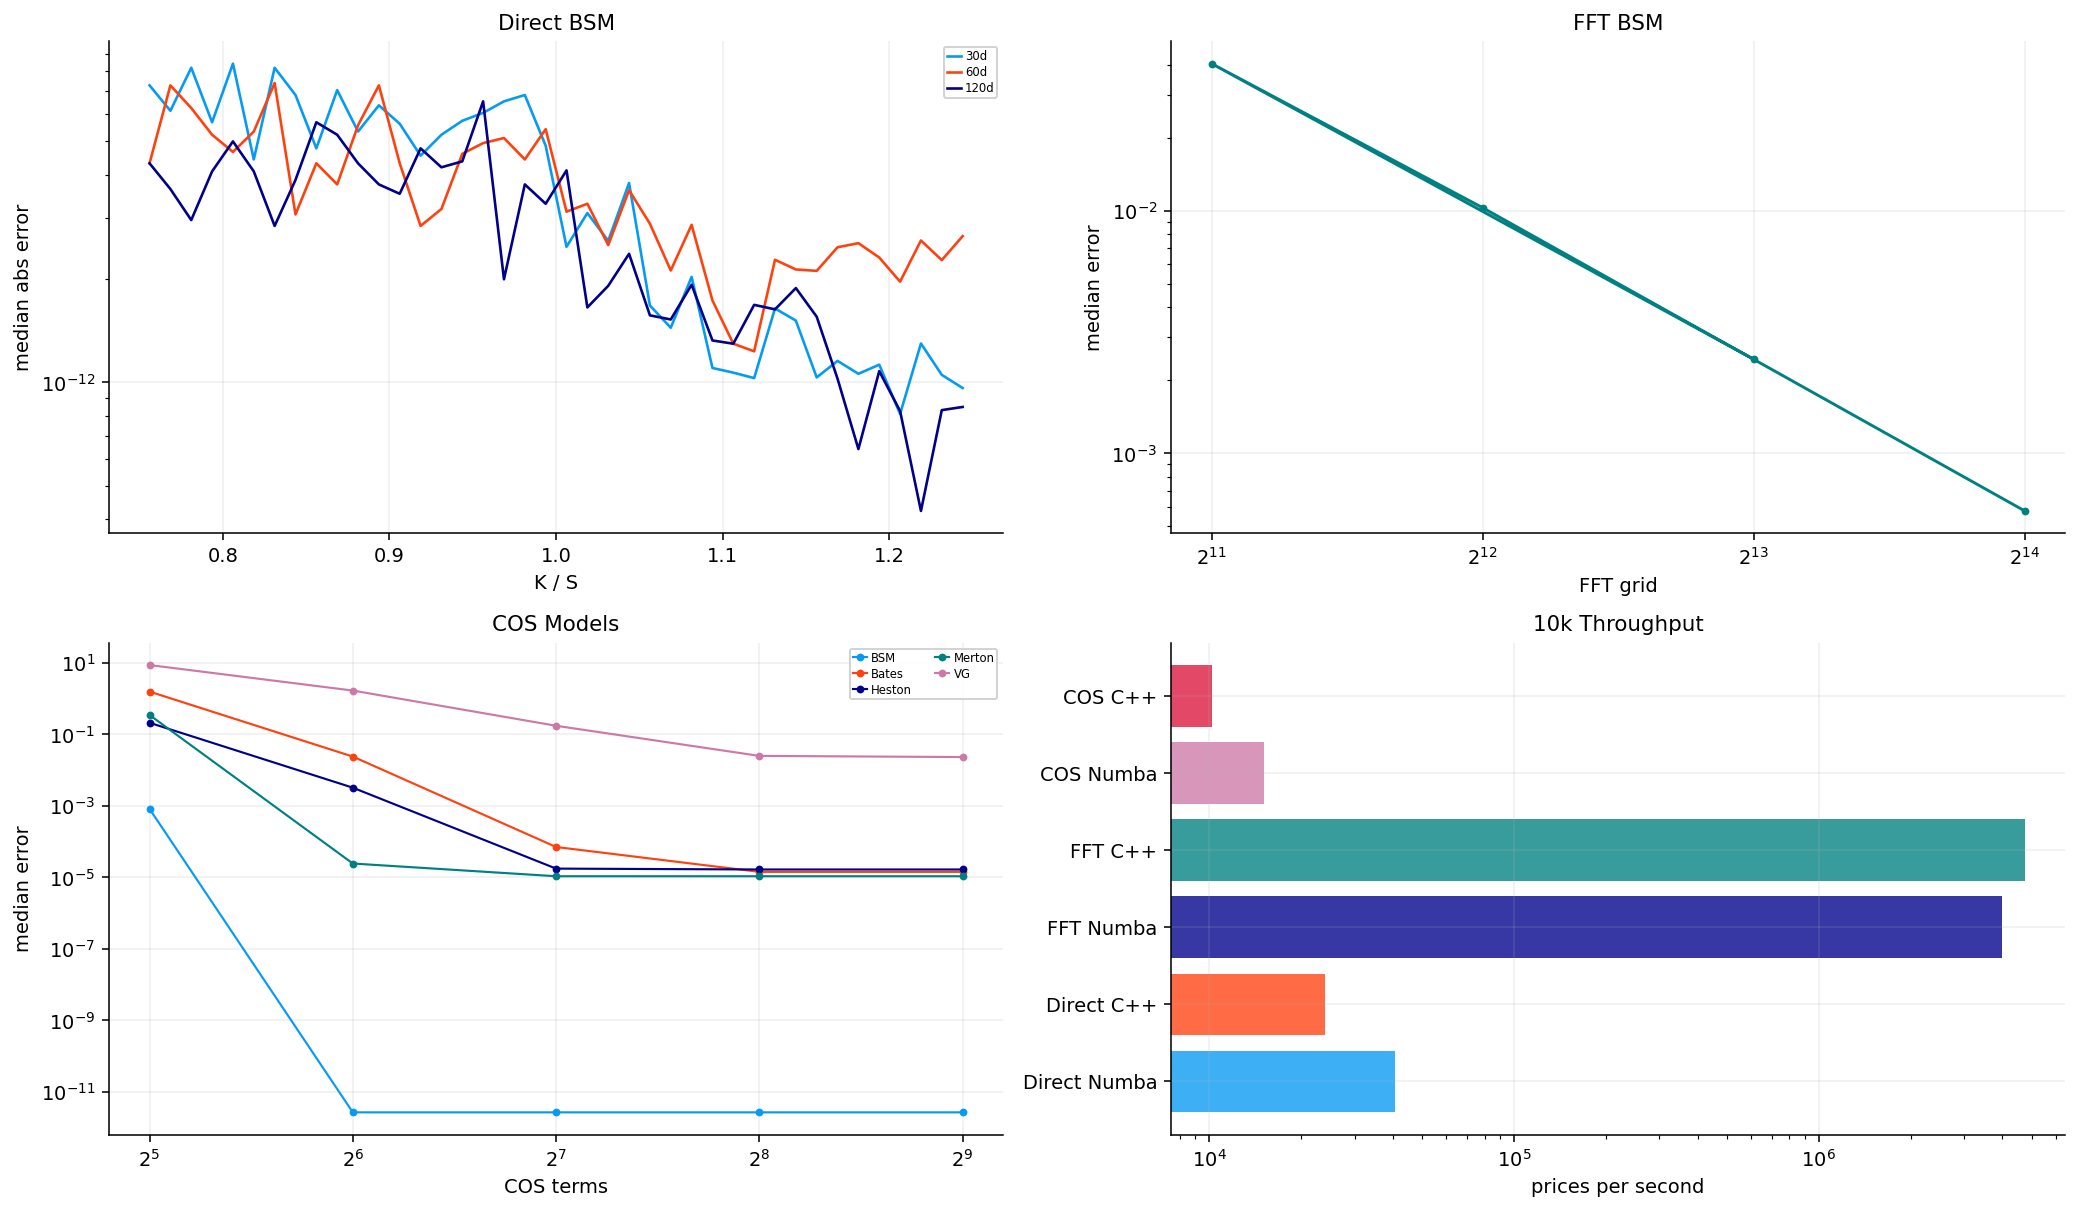

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(15, 8.8))
direct_plot = direct_validation.assign(ks=direct_validation["strike"] / s0)
direct_plot["bucket"] = pd.cut(direct_plot["ks"], np.linspace(0.75, 1.25, 41), include_lowest=True)
direct_plot = direct_plot.groupby(["tau", "bucket"], observed=True).agg(ks=("ks", "median"), err=("abs_error", "median")).reset_index()
for i, (tau, g) in enumerate(direct_plot.groupby("tau")):
    axes[0, 0].plot(g["ks"], g["err"], lw=1.35, color=palette[i], label=f"{tau * ann_days:.0f}d")
axes[0, 0].set_yscale("log")
axes[0, 0].set_xlabel("K / S")
axes[0, 0].set_ylabel("median abs error")
axes[0, 0].set_title("Direct BSM")
axes[0, 0].legend(**legend_kw)
n_view = fft_validation_table[fft_validation_table["alpha"].eq(1.5)].drop_duplicates("n")
axes[0, 1].plot(n_view["n"], n_view["median_abs_error"], marker="o", ms=3, color=palette[3])
axes[0, 1].set_xscale("log", base=2)
axes[0, 1].set_yscale("log")
axes[0, 1].set_xlabel("FFT grid")
axes[0, 1].set_ylabel("median error")
axes[0, 1].set_title("FFT BSM")
for i, (name, g) in enumerate(cos_validation_table.groupby("model")):
    axes[1, 0].plot(g["n_terms"], g["median_abs_error"], marker="o", ms=3, lw=1.1, color=palette[i % len(palette)], label=name)
axes[1, 0].set_xscale("log", base=2)
axes[1, 0].set_yscale("log")
axes[1, 0].set_xlabel("COS terms")
axes[1, 0].set_ylabel("median error")
axes[1, 0].set_title("COS Models")
axes[1, 0].legend(ncol=2, **legend_kw)
x = np.arange(len(model_10k_certificate))
speed_view = pd.DataFrame([
    {"method": "Direct", "engine": "Numba", "pps": 10000 / model_10k_certificate["direct_numba_runtime"].median()},
    {"method": "Direct", "engine": "C++", "pps": 10000 / model_10k_certificate["direct_cpp_runtime"].median()},
    {"method": "FFT", "engine": "Numba", "pps": 10000 / model_10k_certificate["fft_numba_runtime"].median()},
    {"method": "FFT", "engine": "C++", "pps": 10000 / model_10k_certificate["fft_cpp_runtime"].median()},
    {"method": "COS", "engine": "Numba", "pps": model_10k_certificate["numba_prices_per_sec"].median()},
    {"method": "COS", "engine": "C++", "pps": model_10k_certificate["cpp_prices_per_sec"].median()},
])
speed_view["label"] = speed_view["method"] + " " + speed_view["engine"]
axes[1, 1].barh(speed_view["label"], speed_view["pps"], color=[palette[i % len(palette)] for i in range(len(speed_view))], alpha=0.78)
axes[1, 1].set_xscale("log")
axes[1, 1].set_xlabel("prices per second")
axes[1, 1].set_title("10k Throughput")
for ax in axes.ravel():
    ax.grid(True, alpha=0.20)
fig.tight_layout(pad=1.25, h_pad=1.0, w_pad=1.0)
plt.show()

The convergence and throughput panel summarizes the numerical engine hierarchy.

Direct BSM error is essentially machine-level across moneyness and maturity. FFT error falls as the grid size increases, which confirms that its main error source here is grid/interpolation resolution. COS convergence is excellent for BSM, Merton, Heston, and Bates, while VG has a visible error floor under the chosen truncation design. The throughput chart shows FFT as extremely fast for full grids and COS as practical for arbitrary market quotes.

This panel is important because calibration errors later shouldn't be blamed only on model structure. We first verified that the pricing engines are behaving as expected.


## 9) Parameter Bounds and Calibration Objective

Each model has its own parameter vector.

For BSM:

$$
\theta_{BSM}=(\sigma)
$$

For Merton:

$$
\theta_{Merton}=(\sigma,\lambda,\mu_J,\sigma_J)
$$

For VG:

$$
\theta_{VG}=(\sigma,\theta,\nu)
$$

For Heston:

$$
\theta_{Heston}=(v_0,\kappa,\bar{v},\xi,\rho)
$$

For Bates:

$$
\theta_{Bates}=(v_0,\kappa,\bar{v},\xi,\rho,\lambda,\mu_J,\sigma_J)
$$

The optimizer starts near ATM implied volatility for the volatility scale. Bounds keep the search inside plausible regions. For example, volatilities must be positive, jump intensity can't be negative, and correlation must stay inside $(-1,1)$.

VG has the special martingale constraint:

$$
1-\theta\nu-\frac{1}{2}\sigma^2\nu>0
$$

This constraint is not cosmetic. It ensures the risk-neutral drift correction exists and the stock price process is well-defined under the exponential VG model.


### 9.1 Calibration as Statistical Estimation

The optimizer is estimating risk-neutral model parameters from noisy market prices. The market mid is not a perfect observation of theoretical value. It is the midpoint of a bid/ask interval, and the interval width changes across strikes and maturities.

A natural observation equation is:

$$
V_j^{mkt}=\hat{V}_j(\theta)+\epsilon_j
$$

where $\epsilon_j$ is pricing noise. If quote noise variance is larger for wide-spread contracts, then the loss should downweight those contracts. Weighted least squares does exactly that:

$$
\hat{\theta}=\arg\min_{\theta}\sum_j w_j\left(\hat{V}_j(\theta)-V_j^{mkt}\right)^2
$$

The implementation expresses this through a scale:

$$
\frac{\hat{V}_j(\theta)-V_j^{mkt}}{s_j}
$$

which is equivalent to using weight $1/s_j^2$. A smaller $s_j$ means a cleaner quote, so the same dollar error is more important. A larger $s_j$ means a noisier quote, so the optimizer doesn't chase it too aggressively.

This is also why median absolute price error and bid/ask hit rate are reported next to weighted RMSE. One metric is too thin for this comparison. Weighted RMSE reflects the calibration objective. Median error is easier to understand in price units. Bid/ask hit rate tells us whether model prices land inside the actual market quote interval.


### 9.2 Parameter Identifiability and Warm Starts

Nonlinear option calibration is not a simple regression with a unique stable answer. The model price function is nonlinear:

$$
\hat{V}_j(\theta)=F_j(\theta)
$$

and the Jacobian

$$
J_{j,k}=\frac{\partial \hat{V}_j}{\partial \theta_k}
$$

can be ill-conditioned. If two parameters change prices in similar ways across the observed quotes, the optimizer can trade them off. In Heston, $v_0$, $\theta$, and $\xi$ can interact. In Bates, jump intensity and jump volatility can interact with stochastic-volatility skew. In VG, $\theta$ and $\nu$ both affect downside shape.

Warm starts reduce this problem by using yesterday's fit as today's initial guess:

$$
\theta_{t}^{(0)}=\hat{\theta}_{t-1}
$$

This doesn't guarantee the global optimum, but it creates smoother parameter paths and reduces random jumps between local minima. It also speeds up calibration because the optimizer begins near a plausible region.

The multiple-start logic for Heston and Bates is a safety check. A second nearby starting point can escape a bad local basin without turning calibration into an expensive global search.


The daily calibration loss is spread-scaled and observation-weighted:

$$
L_t(\theta)=\frac{1}{n_t}\sum_{j=1}^{n_t}\left(\frac{\hat{V}_j(\theta)-V_j^{mkt}}{s_j}\right)^2
$$

where:

- $n_t$ is the number of calibration quotes on date $t$,
- $\hat{V}_j(\theta)$ is the model price,
- $V_j^{mkt}$ is the market mid,
- $s_j$ is the spread-adjusted scale.

The reported weighted RMSE is:

$$
RMSE_t=\sqrt{L_t(\hat{\theta}_t)}
$$

This means the RMSE is not in dollars. It is an error measured in quote-quality units. If a model has RMSE 20 and another has RMSE 80, the first model is much closer to market prices relative to the bid/ask and weight structure.

The calibration also reports:

$$
\text{bid/ask hit rate}=\frac{1}{n_t}\sum_{j=1}^{n_t}\mathbf{1}\{bid_j\le\hat{V}_j\le ask_j\}
$$

and OTM put RMSE, which isolates the downside tail. For tail-hedging applications, OTM put errors are often more important than average fit.


The fitting loop uses the previous successful parameter vector as the next start. This is a practical calibration trick. Market parameters usually move gradually from one day to the next, so yesterday's fitted parameter is often a better starting point than a generic constant.

For Heston and Bates, the code also tries a second nearby start. This helps avoid local minima because the objective surface can be non-convex. Parameters like $\kappa$, $\theta$, $\xi$, and $\rho$ can compensate for each other, so different parameter combinations may produce similar option prices.

The regularization terms are light. They penalize very high vol-of-vol and very high jump intensity in the most flexible models. This doesn't force the fit to be simple, but it discourages extreme parameter values that improve one day's RMSE at the cost of unstable dynamics.


In [ ]:
def model_start(model, q, start=None):
    atm = float(np.nanmedian(q["iv_mid"]))
    if model == "bsm":
        p = np.array([atm])
        lo = np.array([0.03])
        hi = np.array([3.0])
    elif model == "merton":
        p = np.array([atm, 0.40, -0.04, 0.20])
        lo = np.array([0.03, 0.0, -1.0, 0.01])
        hi = np.array([3.0, 8.0, 1.0, 2.0])
    elif model == "vg":
        p = np.array([atm, -0.05, 0.20])
        lo = np.array([0.03, -1.50, 0.01])
        hi = np.array([3.0, 1.50, 3.0])
    elif model == "heston":
        v = atm * atm
        p = np.array([v, 2.0, v, 0.60, -0.50])
        lo = np.array([1e-5, 0.05, 1e-5, 0.02, -0.999])
        hi = np.array([4.0, 12.0, 4.0, 4.0, 0.999])
    else:
        v = atm * atm
        p = np.array([v, 2.0, v, 0.60, -0.50, 0.30, -0.04, 0.20])
        lo = np.array([1e-5, 0.05, 1e-5, 0.02, -0.999, 0.0, -1.0, 0.01])
        hi = np.array([4.0, 12.0, 4.0, 4.0, 0.999, 8.0, 1.0, 2.0])
    if start is not None and len(start) == len(p) and np.all(np.isfinite(start)):
        p = np.asarray(start, dtype=float)
    return np.clip(p, lo, hi), lo, hi

def model_id(model):
    return {"bsm": 0, "merton": 1, "vg": 2, "heston": 3, "bates": 4}[model]

def param_valid(model, p):
    if model == "vg":
        return bool(p[0] > 0 and p[2] > 0 and 1.0 - p[1] * p[2] - 0.5 * p[0] * p[0] * p[2] > 0.0)
    return bool(np.all(np.isfinite(p)))

In [ ]:
def price_with_cos(model, p, q, n_terms=144, width=12.0):
    return cos_group_price(model, p, q, n_terms=n_terms, width=width, engine="numba")

def price_with_groups(model, p, groups, n_rows, n_terms=144, width=12.0):
    return cos_group_values(model, p, groups, n_rows, n_terms=n_terms, width=width, engine="numba")

def fit_one_date(q, model, start=None, max_nfev=55, n_terms=144, width=12.0):
    t0 = time.perf_counter()
    p0, lo, hi = model_start(model, q, start)
    target = q["mid"].to_numpy(float)
    scale = q["calib_scale_px"].to_numpy(float) / np.sqrt(q["obs_weight"].to_numpy(float))
    groups = cos_groups(q)
    def residual(p):
        if not param_valid(model, p):
            return np.full_like(target, 1e6)
        px = price_with_groups(model, p, groups, len(q), n_terms=n_terms, width=width)
        reg = []
        if model in {"heston", "bates"}:
            reg.append(0.02 * max(p[3] - 2.5, 0.0))
        if model == "bates":
            reg.append(0.02 * max(p[5] - 4.0, 0.0))
        return np.r_[(px - target) / scale, np.asarray(reg)] if reg else (px - target) / scale
    starts = [p0]
    if model in {"heston", "bates"}:
        starts.append(np.clip(p0 * np.r_[1.05, 0.70, 1.0, 0.85, 1.0, np.ones(max(0, len(p0) - 5))], lo, hi))
    best = None
    for guess in starts:
        res = optimize.least_squares(residual, guess, bounds=(lo, hi), max_nfev=max_nfev, xtol=1e-7, ftol=1e-7, gtol=1e-7)
        loss = float(np.nanmean(res.fun ** 2))
        if best is None or loss < best[0]:
            best = (loss, res)
    res = best[1]
    px = price_with_groups(model, res.x, groups, len(q), n_terms=n_terms, width=width)
    raw = px - target
    half = q["calib_scale_px"].to_numpy(float)
    inside = (px >= q["bid"].to_numpy(float)) & (px <= q["ask"].to_numpy(float))
    otm_put = q["option_type"].astype(str).str.lower().str.startswith("p").to_numpy() & (q["moneyness"].to_numpy(float) <= 0.90)
    short = q["dte_days"].to_numpy(float) <= 30.0
    row = {"model": model, "date": q["date"].iloc[0], "success": bool(res.success or np.sqrt(best[0]) < 5.0), "nfev": int(res.nfev), "runtime_sec": time.perf_counter() - t0, "quotes": len(q), "weighted_price_rmse": float(np.sqrt(np.nanmean(((px - target) / scale) ** 2))), "median_abs_price_error": float(np.nanmedian(np.abs(raw))), "weighted_iv_rmse": float(np.sqrt(np.nanmean((raw / np.maximum(q["vega"].abs().fillna(1.0).to_numpy(float), 1e-6)) ** 2))), "bid_ask_hit_rate": float(np.mean(inside)), "otm_put_rmse": float(np.sqrt(np.nanmean(((px[otm_put] - target[otm_put]) / scale[otm_put]) ** 2))) if otm_put.any() else np.nan, "short_maturity_rmse": float(np.sqrt(np.nanmean(((px[short] - target[short]) / scale[short]) ** 2))) if short.any() else np.nan}
    for i, val in enumerate(res.x):
        row[f"p{i}"] = float(val)
    fit = q[["date", "expiry", "strike", "option_type", "spot", "tau", "dte_days", "moneyness", "log_moneyness", "dividend_yield", "mid", "bid", "ask", "calib_scale_px", "obs_weight"]].copy()
    fit["model"] = model
    fit["model_price"] = px
    fit["price_residual"] = raw
    return row, fit, res.x

In [ ]:
def fit_dates(quotes, models, dates, cache_path, settings, max_nfev=55, n_terms=144, width=12.0, min_quotes=120):
    if cache_path.exists() and same_settings(cache_path, settings):
        params = pd.read_parquet(cache_path)
        fit = pd.read_parquet(Path(str(cache_path).replace("_fits.parquet", "_fit_prices.parquet")))
        return params, fit
    rows = []
    fits = []
    last = {}
    q = quotes.copy()
    q["date"] = pd.to_datetime(q["date"]).dt.normalize()
    for model in models:
        for d in dates:
            day = q[q["date"].eq(pd.Timestamp(d).normalize())].copy()
            if len(day) < min_quotes:
                continue
            row, fit, params = fit_one_date(day, model, start=last.get(model), max_nfev=max_nfev, n_terms=n_terms, width=width)
            rows.append(row)
            fits.append(fit)
            if row["success"]:
                last[model] = params
    params = pd.DataFrame(rows)
    fit = pd.concat(fits, ignore_index=True) if fits else pd.DataFrame()
    params.to_parquet(cache_path, index=False)
    fit.to_parquet(Path(str(cache_path).replace("_fits.parquet", "_fit_prices.parquet")), index=False)
    write_meta(cache_path, settings, len(params))
    return params, fit

## 10) BSM Baseline Fourier Calibration

BSM is repeated from earlier projects conceptually, so here it serves mainly as a calibration benchmark. It has one parameter per date: $\sigma$. The whole surface must be explained by one volatility number at a time.

That means BSM has no mechanism for:

- strike skew,
- volatility smile curvature,
- jump tails,
- stochastic volatility term structure,
- separate short-maturity and long-maturity behavior.


### 10.1 Why a One-Volatility Fit Fails

BSM's failure here is not because Fourier pricing breaks it. The BSM Fourier validation was essentially exact. The failure is structural.

The model-implied variance over maturity $T$ is:

$$
Var[X_T]=\sigma^2T
$$

and the distribution is symmetric in standardized log-return space. That means one parameter controls both the center and the tails. If the optimizer raises $\sigma$ to fit expensive downside puts, it also raises ATM and upside option prices. If it lowers $\sigma$ to fit the center, it underprices the left tail.

This is the classic surface-fitting problem in a different language. BSM has one transform shape. The SPX option surface needs a transform shape that changes skew and tail thickness separately from ATM variance.

Fourier methods make this clean to see. The pricing engine is accurate, so the residuals are model residuals. The transform itself is too restrictive.


In [ ]:
bsm_cache = cache_dir / "spx_bsm_daily_fits.parquet"
bsm_settings = {"models": ["bsm"], "carry": clean_settings["carry"], "pricing_q": "row dividend_yield v2", "pricing_engine": "grouped_cos_numba_v4", "dates": int(len(daily_dates)), "quotes": int(len(calibration_quotes)), "n_terms": 128, "width": 12.0}
bsm_daily_fits, bsm_fit_prices = fit_dates(calibration_quotes, ["bsm"], daily_dates, bsm_cache, bsm_settings, max_nfev=35, n_terms=128, width=12.0, min_quotes=120)
bsm_summary = bsm_daily_fits.groupby("model", as_index=False).agg(dates=("date", "nunique"), quotes=("quotes", "sum"), success_rate=("success", "mean"), weighted_price_rmse=("weighted_price_rmse", "mean"), median_abs_price_error=("median_abs_price_error", "median"), bid_ask_hit_rate=("bid_ask_hit_rate", "mean"), otm_put_rmse=("otm_put_rmse", "mean"), runtime_sec=("runtime_sec", "sum"))
display(model_10k_certificate[model_10k_certificate["model"].eq("BSM")].round(8))
display(bsm_summary.round(6))

,model,rows,direct_numba_runtime,direct_cpp_runtime,direct_speedup_cpp_vs_numba,direct_implementation_median_diff,fft_numba_runtime,fft_cpp_runtime,fft_speedup_cpp_vs_numba,fft_implementation_median_diff,numba_runtime,cpp_runtime,speedup_cpp_vs_numba,numba_reference_error,cpp_reference_error,implementation_max_diff,implementation_median_diff,numba_prices_per_sec,cpp_prices_per_sec
0,BSM,10000,0.241967,0.365602,0.661831,0.000000,0.001295,0.001345,0.962599,0.000000,0.351708,0.537497,0.654343,0.000000,0.000000,0.000000,0.000000,"28,432.701360","18,604.744619"


,model,dates,quotes,success_rate,weighted_price_rmse,median_abs_price_error,bid_ask_hit_rate,otm_put_rmse,runtime_sec
0,bsm,505,85850,1.000000,259.511954,8.697427,0.036808,359.590318,26.777009


The calibration table confirms this limitation. BSM has a **100% success rate**, but a weighted price RMSE around **259.5**, median absolute price error around **8.70**, bid/ask hit rate around **3.7%**, and OTM put RMSE around **359.6**. The model can always fit a single volatility, but the single volatility can't explain the real SPX surface.

The runtime is low, about **26.8 seconds** for all daily BSM fits, which is expected. One parameter is cheap. The problem is model structure, not numerical speed.


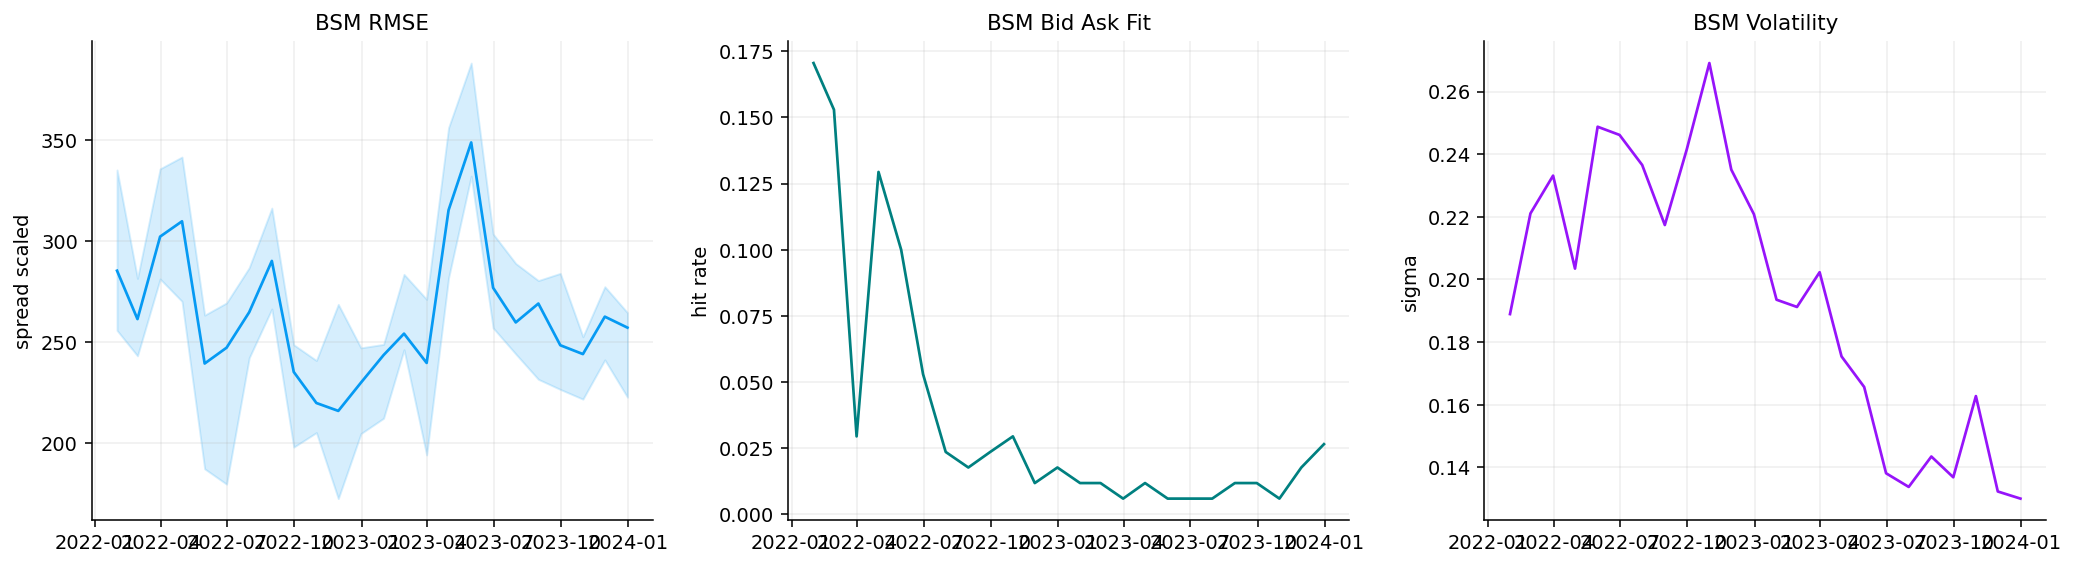

In [ ]:
bsm_month = bsm_daily_fits.assign(month=bsm_daily_fits["date"].dt.to_period("M").dt.to_timestamp("M")).groupby("month", observed=True).agg(
    rmse=("weighted_price_rmse", "median"),
    rmse_lo=("weighted_price_rmse", lambda v: np.nanquantile(v, 0.25)),
    rmse_hi=("weighted_price_rmse", lambda v: np.nanquantile(v, 0.75)),
    hit=("bid_ask_hit_rate", "median"),
    sigma=("p0", "median"),
).reset_index()
fig, axes = plt.subplots(1, 3, figsize=(15, 4.2), sharex=True)
axes[0].plot(bsm_month["month"], bsm_month["rmse"], color=palette[0], lw=1.4)
axes[0].fill_between(bsm_month["month"], bsm_month["rmse_lo"].to_numpy(float), bsm_month["rmse_hi"].to_numpy(float), color=palette[0], alpha=0.16)
axes[0].set_title("BSM RMSE")
axes[0].set_ylabel("spread scaled")
axes[1].plot(bsm_month["month"], bsm_month["hit"], color=palette[3], lw=1.4)
axes[1].set_title("BSM Bid Ask Fit")
axes[1].set_ylabel("hit rate")
axes[2].plot(bsm_month["month"], bsm_month["sigma"], color=palette[6], lw=1.4)
axes[2].set_title("BSM Volatility")
axes[2].set_ylabel("sigma")
for ax in axes:
    ax.grid(True, alpha=0.20)
fig.tight_layout(pad=1.25, h_pad=1.0, w_pad=1.0)
plt.show()

The BSM monthly diagnostics show the same message visually. RMSE spikes during stressed parts of the sample, while the single fitted volatility moves through time as the model tries to compress the whole surface into one number.

The bid/ask hit rate stays very low. This means BSM prices rarely fall inside the observed bid/ask spread across the calibration grid. The fitted volatility is useful as a rough summary, but it is not a serious surface model for 2022-2023 SPX options.

The fitted volatility declines through much of 2023 as the market moves away from the 2022 stress regime. That trend is economically sensible, but it doesn't solve the cross-sectional problem. One volatility can move up and down through time, but it can't bend across strikes and maturities.


## 11) Jump Models: Merton and Variance Gamma

The jump-model calibration compares two different ways of generating non-Gaussian returns.

Merton uses finite-activity jumps:

$$
\text{diffusion} + \text{occasional jumps}
$$

VG uses random business time:

$$
\text{Brownian motion evaluated at a Gamma clock}
$$

Both models can create skew and fat tails. The difference is how they distribute jump risk. Merton says large discrete jumps arrive according to a Poisson clock. VG says return variance itself accumulates in random bursts, creating an infinite-activity jump structure in continuous time.

For SPX options, the calibration question is practical: which jump representation explains the observed surface better when priced through the same COS engine?


### 11.1 Comparing Jump Mechanisms Through Cumulants

Jump models change higher moments. A useful summary is to think in cumulants rather than only parameters.

For Merton, the jump component contributes approximately:

$$
E[\text{jump return over }T]=\lambda T\mu_J
$$

$$
Var[\text{jump return over }T]=\lambda T(\mu_J^2+\sigma_J^2)
$$

So increasing $\lambda$ raises jump frequency, while increasing $\sigma_J$ makes jump outcomes more dispersed. Negative $\mu_J$ tilts the distribution left.

For VG, the cumulant behavior comes from the Gamma clock. The variance rate includes both diffusion scale and clock-skew contribution:

$$
\text{variance rate}\approx \sigma^2+\theta^2\nu
$$

Higher $\nu$ increases excess kurtosis because business time becomes more random. Negative $\theta$ creates skew.

So Merton and VG can both make tails fatter, but they do it differently. Merton says crash risk comes from identifiable rare jumps. VG says the market's activity rate itself fluctuates, creating clustered large moves.

This distinction matters when interpreting calibration. If Merton beats VG on SPX, the market surface in this sample is better captured by finite crash jumps plus diffusion than by the VG business-time mechanism under the selected pricing setup.


In [ ]:
jump_cache = cache_dir / "spx_jump_daily_fits.parquet"
jump_settings = {"models": ["merton", "vg"], "carry": clean_settings["carry"], "pricing_q": "row dividend_yield v2", "pricing_engine": "grouped_cos_numba_v4", "dates": int(len(daily_dates)), "quotes": int(len(calibration_quotes)), "n_terms": 144, "width": 14.0}
jump_daily_fits, jump_fit_prices = fit_dates(calibration_quotes, ["merton", "vg"], daily_dates, jump_cache, jump_settings, max_nfev=55, n_terms=144, width=14.0, min_quotes=120)
jump_summary = jump_daily_fits.groupby("model", as_index=False).agg(dates=("date", "nunique"), quotes=("quotes", "sum"), success_rate=("success", "mean"), weighted_price_rmse=("weighted_price_rmse", "mean"), median_abs_price_error=("median_abs_price_error", "median"), bid_ask_hit_rate=("bid_ask_hit_rate", "mean"), otm_put_rmse=("otm_put_rmse", "mean"), runtime_sec=("runtime_sec", "sum")).sort_values("weighted_price_rmse")
display(jump_summary.round(6))
display(jump_daily_fits.sort_values("weighted_price_rmse", ascending=False).iloc[:10].round(6))
best_jump = str(jump_summary[jump_summary["success_rate"].ge(0.70)].sort_values("weighted_price_rmse").iloc[0]["model"])
display(pd.DataFrame([{"best_jump_model": best_jump}]))

,model,dates,quotes,success_rate,weighted_price_rmse,median_abs_price_error,bid_ask_hit_rate,otm_put_rmse,runtime_sec
0,merton,505,85850,0.998020,82.246634,2.494583,0.089109,93.947641,193.025027
1,vg,505,85850,1.000000,94.209852,2.503663,0.075294,99.628586,115.154556


C:\Users\Lenovo\AppData\Local\Temp\ipykernel_6324\239604017.py:6: UserWarning: obj.round has no effect with datetime, timedelta, or period dtypes. Use obj.dt.round(...) instead.
  display(jump_daily_fits.sort_values("weighted_price_rmse", ascending=False).iloc[:10].round(6))


,model,date,success,nfev,runtime_sec,quotes,weighted_price_rmse,median_abs_price_error,weighted_iv_rmse,bid_ask_hit_rate,otm_put_rmse,short_maturity_rmse,p0,p1,p2,p3
665,vg,2022-08-18,True,7,0.210319,170,163.334090,2.694960,3.403495,0.011765,204.813171,212.152087,0.181917,-0.291209,0.187167,NaN
995,vg,2023-12-08,True,7,0.209688,170,160.204099,3.386074,3.272469,0.035294,187.251462,262.957350,0.127854,-0.091244,0.389745,NaN
1002,vg,2023-12-19,True,7,0.211455,170,157.978354,2.234045,2.328758,0.017647,183.163199,182.979426,0.128970,-0.092585,0.419933,NaN
670,vg,2022-08-25,True,7,0.229664,170,156.134137,2.312893,3.359722,0.035294,212.298744,183.053384,0.184711,-0.330073,0.191669,NaN
660,vg,2022-08-11,True,9,0.328608,170,153.320621,2.939325,2.811435,0.058824,222.421212,201.796279,0.192585,-0.284953,0.163892,NaN
596,vg,2022-05-10,True,9,0.458135,170,152.716366,4.497558,3.177430,0.023529,64.493356,243.627709,0.220200,-0.525185,0.172866,NaN
847,vg,2023-05-09,True,7,0.213213,170,151.725643,1.642336,2.897515,0.023529,197.321419,249.815100,0.143208,-0.243719,0.283519,NaN
342,merton,2023-05-09,True,16,0.315952,170,151.330296,2.702279,3.617529,0.047059,207.501310,244.393797,0.107976,0.704891,-0.156759,0.110653
974,vg,2023-11-08,True,8,0.239533,170,151.113849,1.663989,2.603671,0.035294,166.062718,213.267649,0.129839,-0.136882,0.345958,NaN
591,vg,2022-05-03,True,8,0.239312,170,148.505078,2.854581,2.458128,0.182353,87.793288,220.683174,0.195575,-0.474294,0.196225,NaN


,best_jump_model
0,merton


The jump-model summary shows Merton beating VG on the main weighted-price objective. Merton has weighted RMSE around **82.25**, while VG is around **94.21**. Both are dramatically better than BSM's **259.51**, which confirms that adding non-Gaussian tail structure matters.

Merton also has slightly better OTM put RMSE, around **93.95** versus VG's **99.63**. The bid/ask hit rates remain low in absolute terms, but Merton is higher than VG: about **8.9%** versus **7.5%**.

VG is faster than Merton in total runtime here, about **115 seconds** versus **193 seconds**, but the fit is weaker. Because this notebook later uses models for tail overlays, the better tail fit matters more than the runtime saving. The selected jump winner is therefore **Merton**.


,model,rows,direct_numba_runtime,direct_cpp_runtime,direct_speedup_cpp_vs_numba,direct_implementation_median_diff,fft_numba_runtime,fft_cpp_runtime,fft_speedup_cpp_vs_numba,fft_implementation_median_diff,numba_runtime,cpp_runtime,speedup_cpp_vs_numba,numba_reference_error,cpp_reference_error,implementation_max_diff,implementation_median_diff,numba_prices_per_sec,cpp_prices_per_sec
1,Merton,10000,0.242010,0.362098,0.668354,0.000000,0.001898,0.001703,1.114465,0.000000,0.468676,0.760388,0.616364,0.000000,0.000000,0.000000,0.000000,"21,336.719898","13,151.185902"


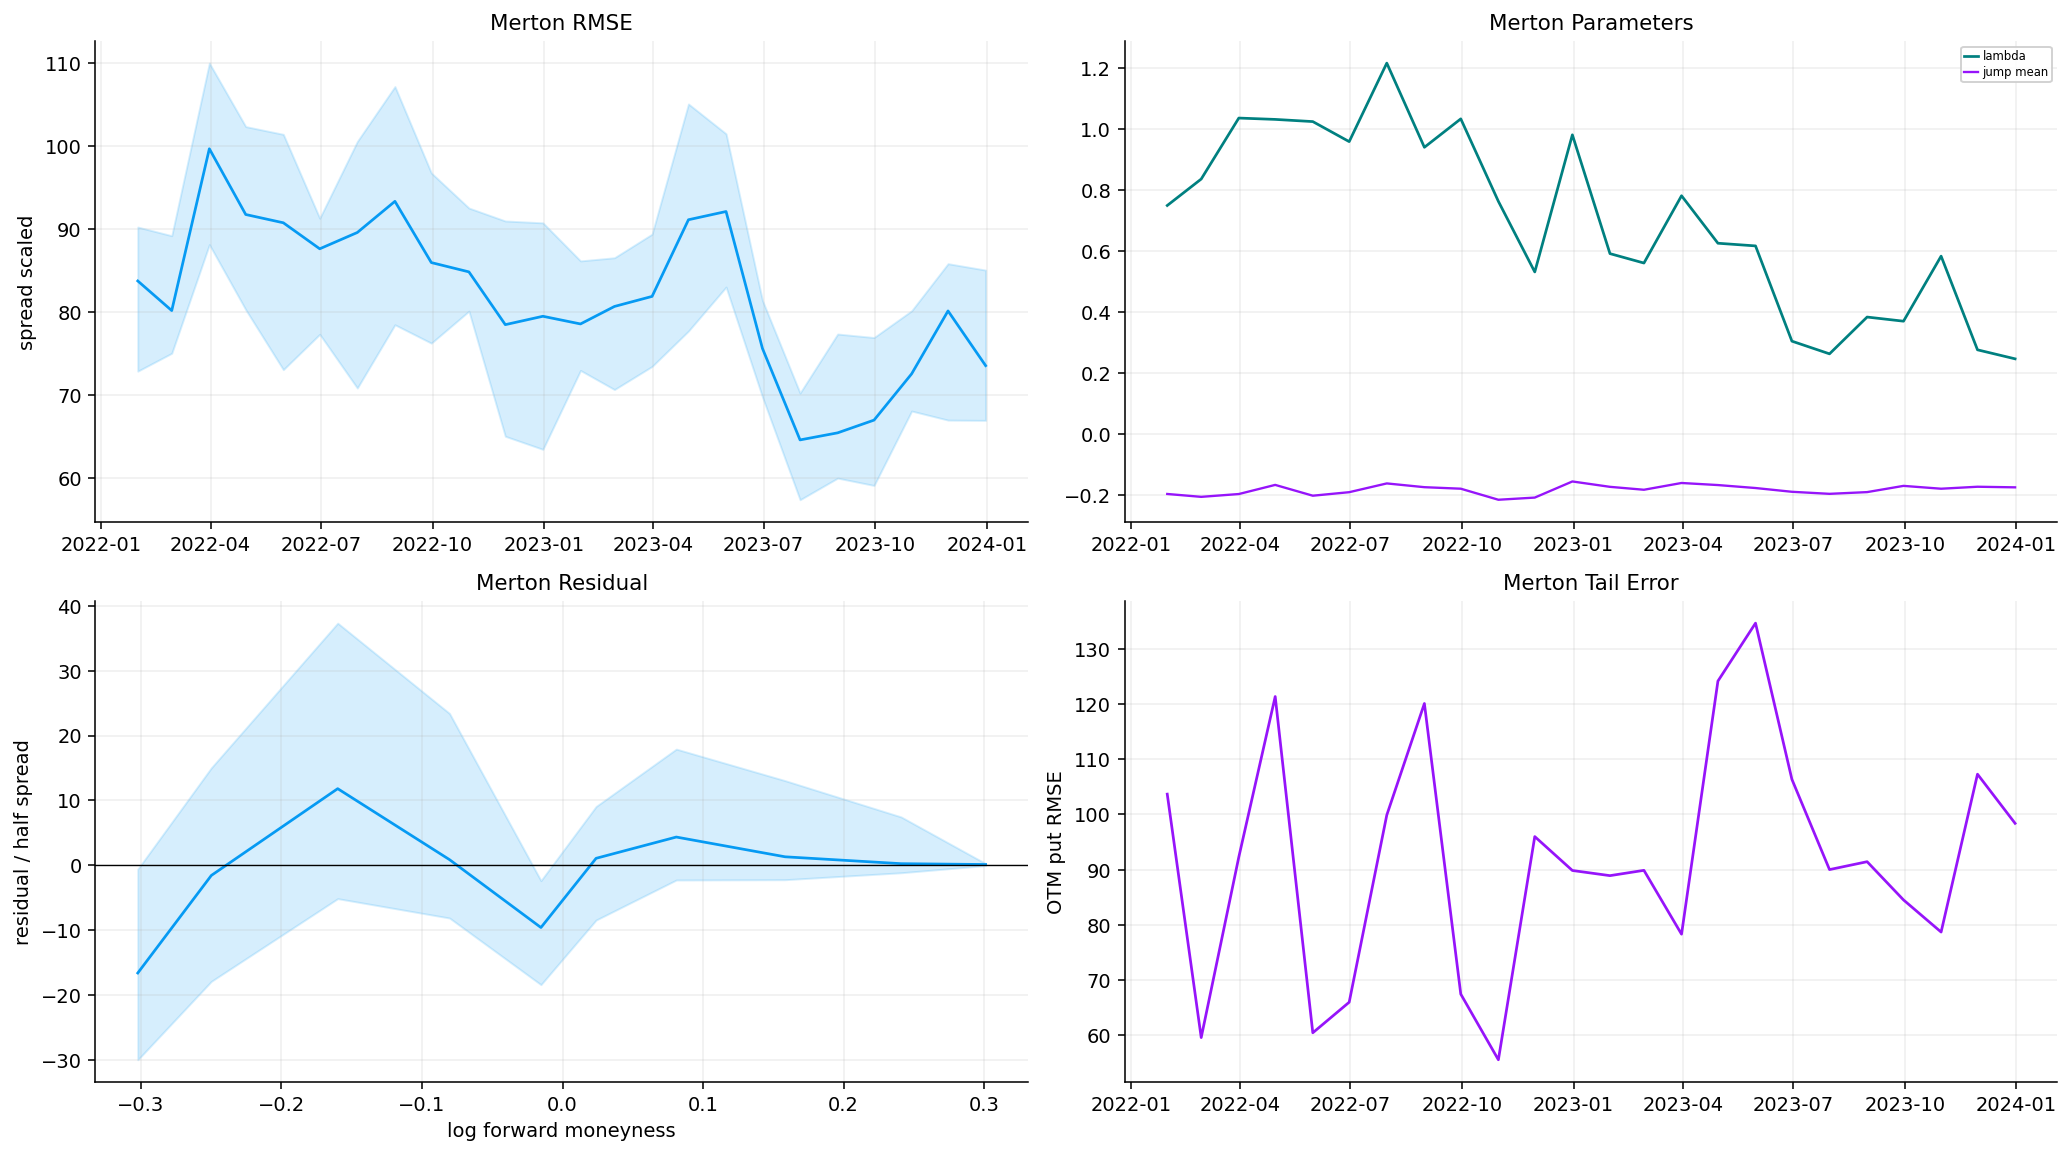

In [ ]:
merton_month = jump_daily_fits[jump_daily_fits["model"].eq("merton")].assign(month=lambda x: x["date"].dt.to_period("M").dt.to_timestamp("M")).groupby("month", observed=True).agg(
    rmse=("weighted_price_rmse", "median"),
    rmse_lo=("weighted_price_rmse", lambda v: np.nanquantile(v, 0.25)),
    rmse_hi=("weighted_price_rmse", lambda v: np.nanquantile(v, 0.75)),
    tail=("otm_put_rmse", "median"),
    lam=("p1", "median"),
    muj=("p2", "median"),
).reset_index()
merton_resid = jump_fit_prices[jump_fit_prices["model"].eq("merton")].copy()
merton_resid["scaled_residual"] = merton_resid["price_residual"] / merton_resid["calib_scale_px"].clip(lower=1e-6)
merton_resid["log_bucket"] = pd.cut(merton_resid["log_moneyness"], [-0.45, -0.30, -0.20, -0.12, -0.06, 0.0, 0.06, 0.12, 0.20, 0.30, 0.45])
merton_smile = merton_resid.groupby("log_bucket", observed=True).agg(x=("log_moneyness", "median"), med=("scaled_residual", "median"), lo=("scaled_residual", lambda v: np.nanquantile(v, 0.25)), hi=("scaled_residual", lambda v: np.nanquantile(v, 0.75))).reset_index()
display(model_10k_certificate[model_10k_certificate["model"].eq("Merton")].round(8))
fig, axes = plt.subplots(2, 2, figsize=(15, 8.4))
axes[0, 0].plot(merton_month["month"], merton_month["rmse"], color=palette[0], lw=1.4)
axes[0, 0].fill_between(merton_month["month"], merton_month["rmse_lo"].to_numpy(float), merton_month["rmse_hi"].to_numpy(float), color=palette[0], alpha=0.16)
axes[0, 0].set_title("Merton RMSE")
axes[0, 0].set_ylabel("spread scaled")
axes[0, 1].plot(merton_month["month"], merton_month["lam"], color=palette[3], lw=1.4, label="lambda")
axes[0, 1].plot(merton_month["month"], merton_month["muj"], color=palette[6], lw=1.2, label="jump mean")
axes[0, 1].set_title("Merton Parameters")
axes[0, 1].legend(**legend_kw)
axes[1, 0].plot(merton_smile["x"], merton_smile["med"], color=palette[0], lw=1.4)
axes[1, 0].fill_between(merton_smile["x"].to_numpy(float), merton_smile["lo"].to_numpy(float), merton_smile["hi"].to_numpy(float), color=palette[0], alpha=0.16)
axes[1, 0].axhline(0.0, color="black", lw=0.7)
axes[1, 0].set_xlabel("log forward moneyness")
axes[1, 0].set_ylabel("residual / half spread")
axes[1, 0].set_title("Merton Residual")
axes[1, 1].plot(merton_month["month"], merton_month["tail"], color=palette[6], lw=1.4)
axes[1, 1].set_title("Merton Tail Error")
axes[1, 1].set_ylabel("OTM put RMSE")
for ax in axes.ravel():
    ax.grid(True, alpha=0.20)
fig.tight_layout(pad=1.25, h_pad=1.0, w_pad=1.0)
plt.show()

### Merton Diagnostics

The Merton diagnostics show four things at once: RMSE through time, jump parameters, residual smile, and OTM put tail error.

The fitted jump intensity $\lambda$ controls how often jumps occur under the risk-neutral model. The jump mean $\mu_J$ controls average jump direction. In equity index options, negative $\mu_J$ is common because crash protection is expensive. A negative jump mean raises put values more than call values.

The residual smile is especially useful. A scaled residual is:

$$
\text{scaled residual}=\frac{\hat{V}-V^{mkt}}{\text{half-spread scale}}
$$

Negative residual means the model underprices the market. Positive residual means the model overprices it. In the Merton residual plot, the left wing is much less wrong than BSM, but errors still remain. That means finite jumps help with crash risk but don't fully explain the observed SPX skew and term structure.

The OTM put error panel shows that jump risk becomes more important exactly when downside protection is expensive. During stress periods, tail error rises because the surface demands more shape than a simple jump-diffusion can always provide.


### Reading Merton Parameters Economically

A fitted Merton model can be interpreted through the compound jump component. Over one year, the expected number of jumps is approximately $\lambda$. Over a shorter maturity $T$, it is $\lambda T$.

If $\lambda=0.7$ and $T=60/365$, then:

$$
\lambda T\approx 0.7\times 0.164\approx 0.115
$$

The probability of at least one jump over that horizon is:

$$
1-e^{-\lambda T}\approx 1-e^{-0.115}\approx 10.9\%
$$

That rough calculation gives the fitted jump intensity a concrete meaning. The model is not saying a crash happens every day. It is assigning a risk-neutral probability to discrete jump events over the option's horizon.

If the fitted jump mean $\mu_J$ is negative, those jumps are downside-biased. If $\sigma_J$ is high, the jump distribution is wide, so some jumps can be very large. Together, these parameters shape OTM put prices.

This is why Merton improves strongly over BSM but still loses to Bates. It can add discrete tail mass, but it has only one jump distribution and one diffusion volatility per date. The SPX surface often needs a richer maturity-dependent variance structure too.


,model,rows,direct_numba_runtime,direct_cpp_runtime,direct_speedup_cpp_vs_numba,direct_implementation_median_diff,fft_numba_runtime,fft_cpp_runtime,fft_speedup_cpp_vs_numba,fft_implementation_median_diff,numba_runtime,cpp_runtime,speedup_cpp_vs_numba,numba_reference_error,cpp_reference_error,implementation_max_diff,implementation_median_diff,numba_prices_per_sec,cpp_prices_per_sec
2,VG,10000,0.245057,0.417685,0.586704,0.000000,0.002500,0.002110,1.184722,0.000000,0.662677,0.983042,0.674108,0.006863,0.006863,0.000000,0.000000,"15,090.314780","10,172.502241"


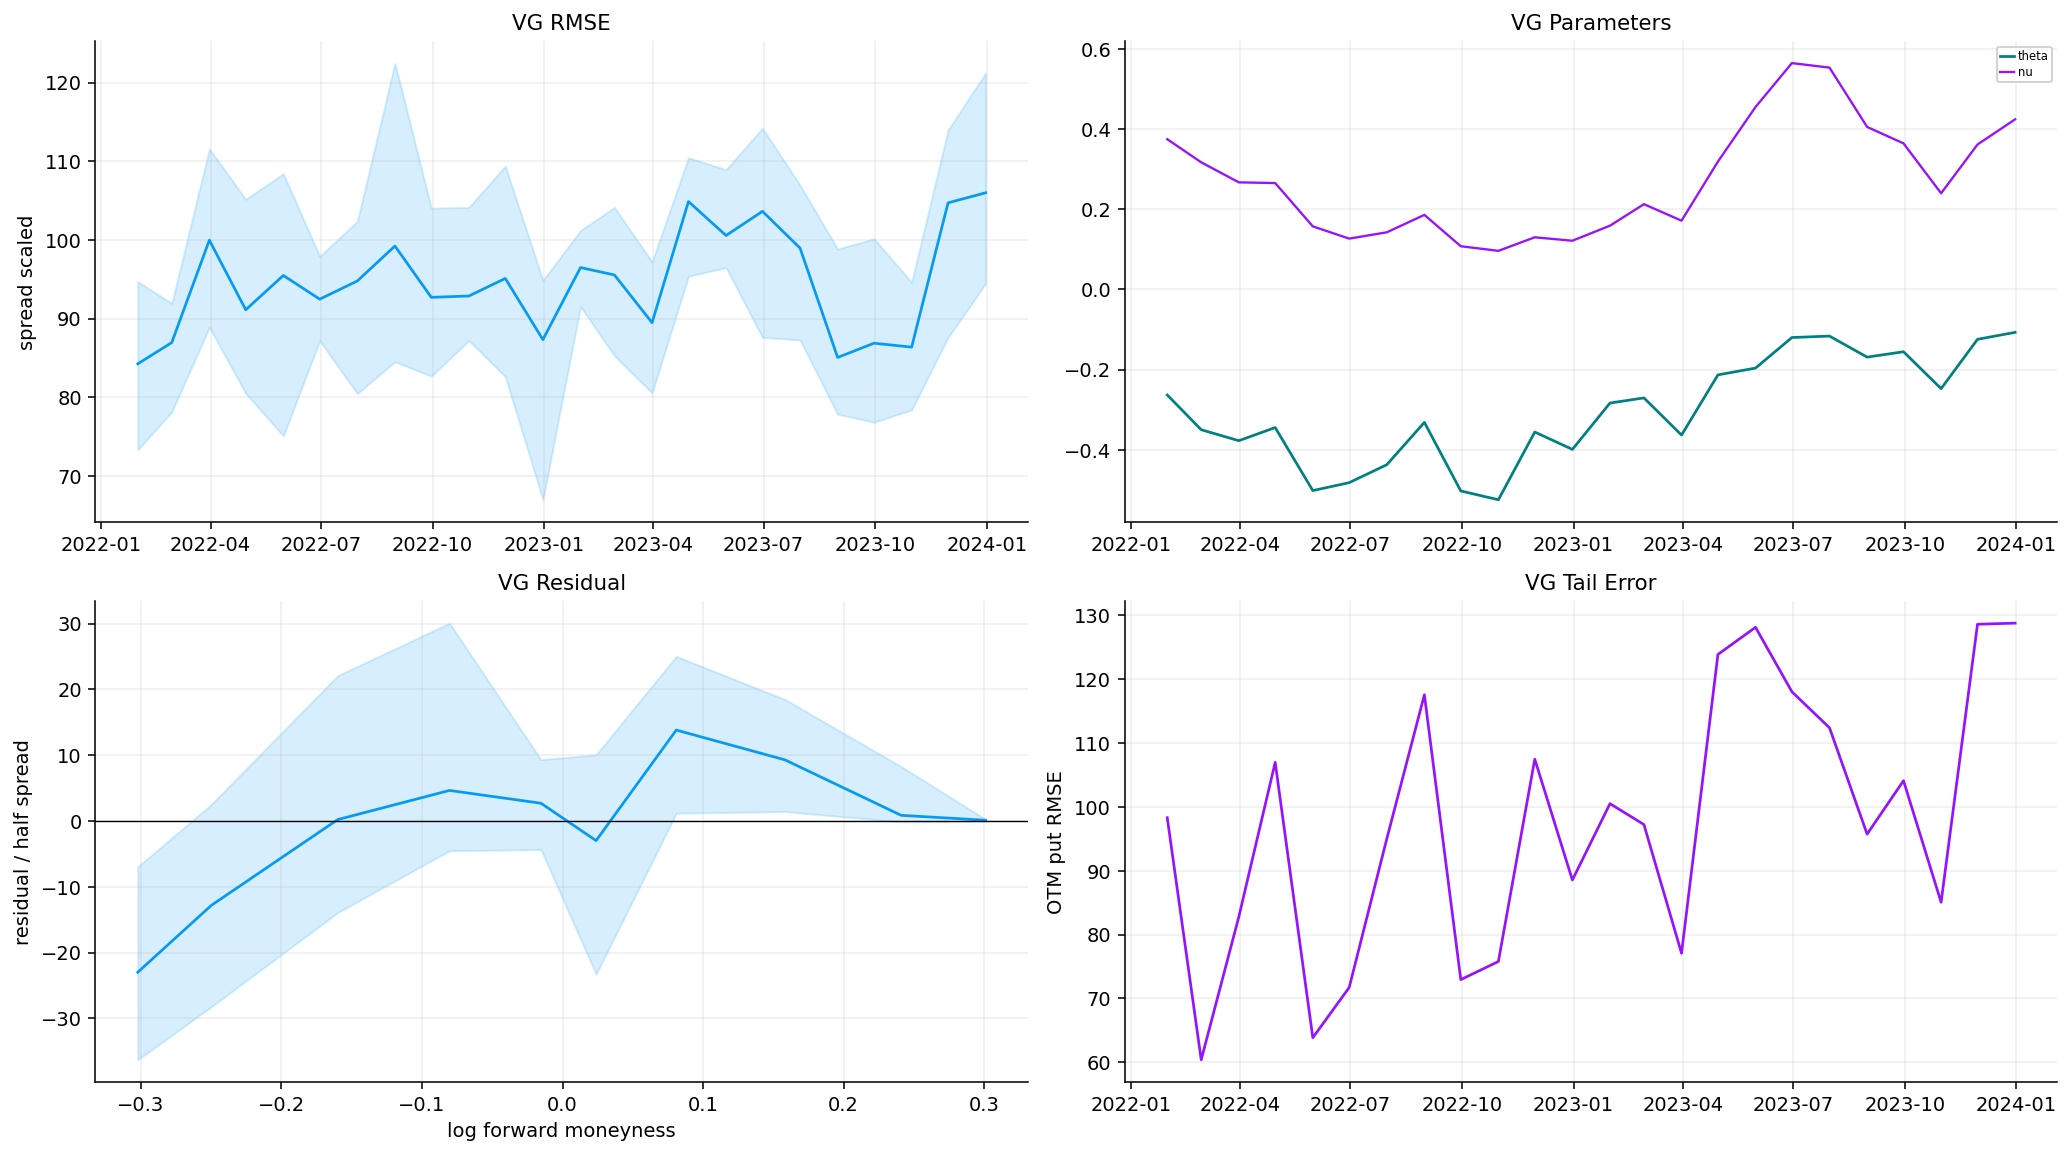

In [ ]:
vg_month = jump_daily_fits[jump_daily_fits["model"].eq("vg")].assign(month=lambda x: x["date"].dt.to_period("M").dt.to_timestamp("M")).groupby("month", observed=True).agg(
    rmse=("weighted_price_rmse", "median"),
    rmse_lo=("weighted_price_rmse", lambda v: np.nanquantile(v, 0.25)),
    rmse_hi=("weighted_price_rmse", lambda v: np.nanquantile(v, 0.75)),
    tail=("otm_put_rmse", "median"),
    theta=("p1", "median"),
    nu=("p2", "median"),
).reset_index()
vg_resid = jump_fit_prices[jump_fit_prices["model"].eq("vg")].copy()
vg_resid["scaled_residual"] = vg_resid["price_residual"] / vg_resid["calib_scale_px"].clip(lower=1e-6)
vg_resid["log_bucket"] = pd.cut(vg_resid["log_moneyness"], [-0.45, -0.30, -0.20, -0.12, -0.06, 0.0, 0.06, 0.12, 0.20, 0.30, 0.45])
vg_smile = vg_resid.groupby("log_bucket", observed=True).agg(x=("log_moneyness", "median"), med=("scaled_residual", "median"), lo=("scaled_residual", lambda v: np.nanquantile(v, 0.25)), hi=("scaled_residual", lambda v: np.nanquantile(v, 0.75))).reset_index()
display(model_10k_certificate[model_10k_certificate["model"].eq("VG")].round(8))
fig, axes = plt.subplots(2, 2, figsize=(15, 8.4))
axes[0, 0].plot(vg_month["month"], vg_month["rmse"], color=palette[0], lw=1.4)
axes[0, 0].fill_between(vg_month["month"], vg_month["rmse_lo"].to_numpy(float), vg_month["rmse_hi"].to_numpy(float), color=palette[0], alpha=0.16)
axes[0, 0].set_title("VG RMSE")
axes[0, 0].set_ylabel("spread scaled")
axes[0, 1].plot(vg_month["month"], vg_month["theta"], color=palette[3], lw=1.4, label="theta")
axes[0, 1].plot(vg_month["month"], vg_month["nu"], color=palette[6], lw=1.2, label="nu")
axes[0, 1].set_title("VG Parameters")
axes[0, 1].legend(**legend_kw)
axes[1, 0].plot(vg_smile["x"], vg_smile["med"], color=palette[0], lw=1.4)
axes[1, 0].fill_between(vg_smile["x"].to_numpy(float), vg_smile["lo"].to_numpy(float), vg_smile["hi"].to_numpy(float), color=palette[0], alpha=0.16)
axes[1, 0].axhline(0.0, color="black", lw=0.7)
axes[1, 0].set_xlabel("log forward moneyness")
axes[1, 0].set_ylabel("residual / half spread")
axes[1, 0].set_title("VG Residual")
axes[1, 1].plot(vg_month["month"], vg_month["tail"], color=palette[6], lw=1.4)
axes[1, 1].set_title("VG Tail Error")
axes[1, 1].set_ylabel("OTM put RMSE")
for ax in axes.ravel():
    ax.grid(True, alpha=0.20)
fig.tight_layout(pad=1.25, h_pad=1.0, w_pad=1.0)
plt.show()

### Variance Gamma Diagnostics

VG's parameters have different economic meaning.

The parameter $\theta$ controls skew under the Gamma clock. Negative $\theta$ tilts the distribution left, increasing downside tail prices. The parameter $\nu$ controls the randomness of the clock. Higher $\nu$ means business time is more variable, which creates heavier tails and more kurtosis.

The VG return increment can be thought of as:

$$
\Delta X = \theta\Delta G + \sigma\Delta W_{\Delta G}
$$

where $\Delta G$ is random. If $\Delta G$ is unusually large, the return has a large move because the Brownian component is evaluated over more business time. This is a very natural way to model markets that have quiet periods interrupted by bursts of activity.

The VG diagnostics show that it improves heavily over BSM, but it doesn't beat Merton in this SPX setup. Part of that may be model fit and part may be numerical sensitivity from the COS truncation behavior we saw earlier. The residual curve still shows structured errors across log-moneyness, which means the model is missing some surface features.


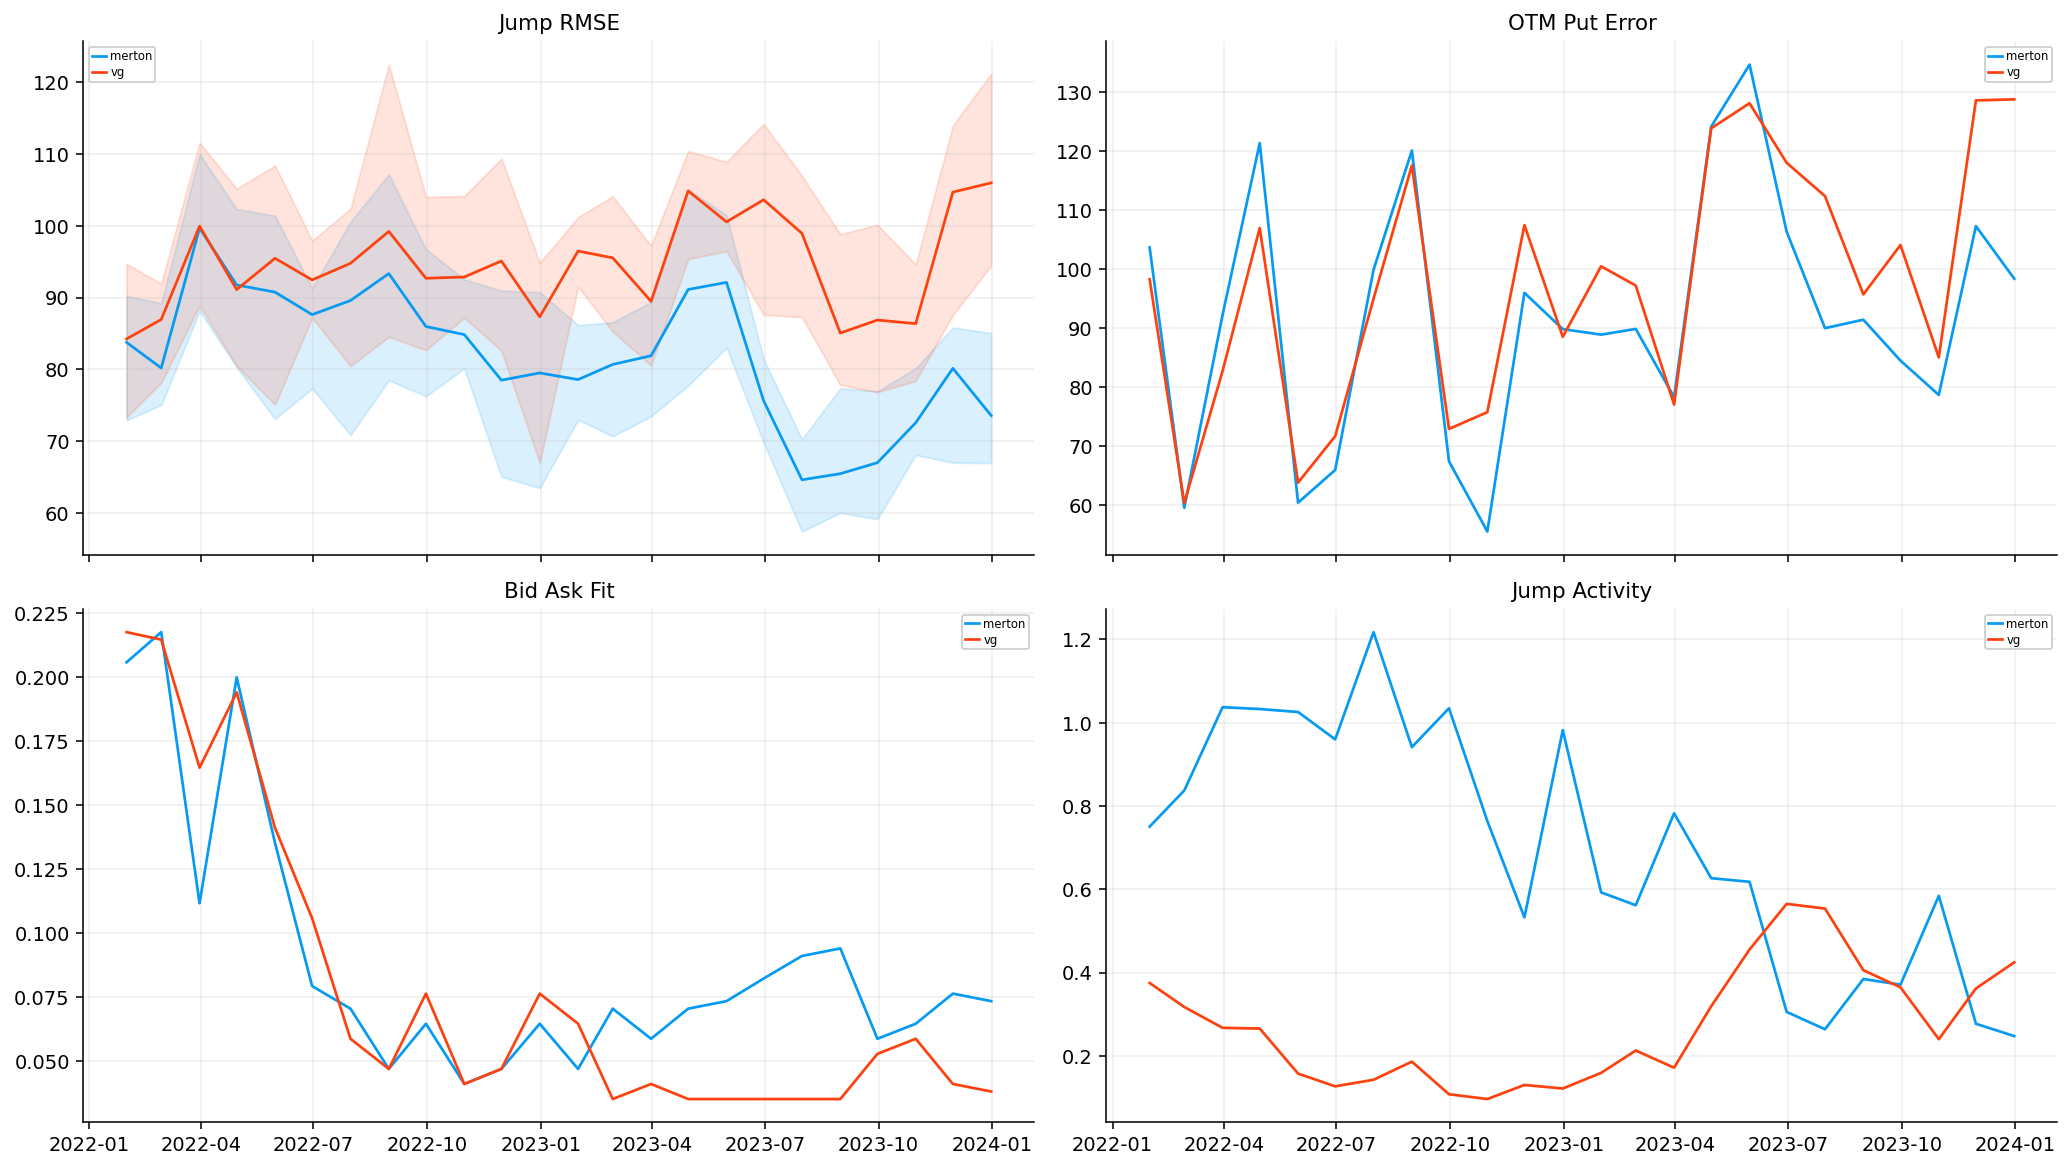

In [ ]:
jump_plot = jump_daily_fits.copy()
jump_plot["month"] = jump_plot["date"].dt.to_period("M").dt.to_timestamp("M")
jump_month = jump_plot.groupby(["model", "month"], observed=True).agg(
    rmse=("weighted_price_rmse", "median"),
    rmse_lo=("weighted_price_rmse", lambda v: np.nanquantile(v, 0.25)),
    rmse_hi=("weighted_price_rmse", lambda v: np.nanquantile(v, 0.75)),
    otm=("otm_put_rmse", "median"),
    hit=("bid_ask_hit_rate", "median"),
    p1=("p1", "median"),
    p2=("p2", "median"),
).reset_index()
fig, axes = plt.subplots(2, 2, figsize=(15, 8.5), sharex=True)
for i, (model, g) in enumerate(jump_month.groupby("model")):
    g = g.sort_values("month")
    axes[0, 0].plot(g["month"], g["rmse"], lw=1.4, color=palette[i], label=model)
    axes[0, 0].fill_between(g["month"], g["rmse_lo"].to_numpy(float), g["rmse_hi"].to_numpy(float), color=palette[i], alpha=0.14)
    axes[0, 1].plot(g["month"], g["otm"], lw=1.4, color=palette[i], label=model)
    axes[1, 0].plot(g["month"], g["hit"], lw=1.4, color=palette[i], label=model)
    y = g["p1"] if model == "merton" else g["p2"]
    axes[1, 1].plot(g["month"], y, lw=1.4, color=palette[i], label=model)
axes[0, 0].set_title("Jump RMSE")
axes[0, 1].set_title("OTM Put Error")
axes[1, 0].set_title("Bid Ask Fit")
axes[1, 1].set_title("Jump Activity")
for ax in axes.ravel():
    ax.legend(**legend_kw)
    ax.grid(True, alpha=0.20)
fig.tight_layout(pad=1.25, h_pad=1.0, w_pad=1.0)
plt.show()

The jump comparison plot confirms that Merton and VG both reduce RMSE relative to BSM, but Merton is generally lower through much of the sample. OTM put error is also better for Merton. The bid/ask fit remains modest for both, which shows that jump models are an improvement, not the end of the story.

The jump-activity panel also tells us that tail pricing is time-varying. In 2022, the market repeatedly repriced downside protection as rates rose and equities sold off. A static jump structure can't absorb all of that variation. This sets up the next step: stochastic-volatility models with and without jumps.


## 12) Stochastic-Volatility Models Through COS

Heston and Bates were already taught in the stochastic-volatility project, so the focus here is calibration through Fourier/COS pricing.

Heston explains skew through correlated spot and variance shocks. A negative $\rho$ means stock declines tend to arrive with variance increases, which raises put prices and creates the equity-index skew.

Bates adds jumps to Heston. Its structure is:

$$
\text{stochastic variance} + \text{finite jump risk}
$$

That extra flexibility is valuable for SPX options because the surface often contains both persistent stochastic-volatility skew and discrete crash-premium behavior.

The cost is calibration difficulty. Bates has eight parameters and a slower pricing kernel. It can fit better, but it can also fail more often or produce unstable parameter paths. So the comparison must include success rate, residuals, tail error, and runtime.


### 12.1 Why Stochastic Volatility Beats Pure Jump Models

Jump models add non-Gaussian tails, but SPX option surfaces also have maturity-dependent skew and time-varying volatility risk. Heston-style stochastic variance gives the model a way to move the whole distribution shape through time.

The variance process introduces a second state variable. The option price is no longer a function only of $S$, $K$, and $T$; it also depends on current variance and variance dynamics:

$$
V=V(S_0,v_0,K,T;r,q,\kappa,\theta,\xi,\rho)
$$

The parameter $\rho$ changes skew. The parameter $\xi$ changes curvature and vol-of-vol premium. The pair $(\kappa,\theta)$ controls how quickly high variance is expected to mean revert.

In Fourier space, these effects are bundled into the affine coefficients $C(u,T)$ and $D(u,T)$. Calibration then chooses the parameters that make the transform-generated option prices match the surface.

The fact that Heston and Bates beat Merton by a large margin tells us that the SPX surface is not only asking for jumps. It is asking for stochastic variance dynamics too.


In [ ]:
sv_cache = cache_dir / "spx_sv_daily_fits.parquet"
sv_settings = {"models": ["heston", "bates"], "carry": clean_settings["carry"], "pricing_q": "row dividend_yield v2", "pricing_engine": "grouped_cos_numba_v4", "dates": int(len(sv_dates)), "quotes": int(len(calibration_quotes)), "n_terms": 128, "width": 14.0}
sv_daily_fits, sv_fit_prices = fit_dates(calibration_quotes, ["heston", "bates"], sv_dates, sv_cache, sv_settings, max_nfev=45, n_terms=128, width=14.0, min_quotes=120)
sv_summary = sv_daily_fits.groupby("model", as_index=False).agg(dates=("date", "nunique"), quotes=("quotes", "sum"), success_rate=("success", "mean"), weighted_price_rmse=("weighted_price_rmse", "mean"), median_abs_price_error=("median_abs_price_error", "median"), bid_ask_hit_rate=("bid_ask_hit_rate", "mean"), otm_put_rmse=("otm_put_rmse", "mean"), runtime_sec=("runtime_sec", "sum")).sort_values("weighted_price_rmse")
display(sv_summary.round(6))
display(sv_daily_fits.sort_values("weighted_price_rmse", ascending=False).iloc[:10].round(6))
eligible_sv = sv_summary[sv_summary["success_rate"].ge(0.70)].copy()
best_sv = str(eligible_sv.sort_values("weighted_price_rmse").iloc[0]["model"]) if not eligible_sv.empty else str(sv_summary.sort_values(["success_rate", "weighted_price_rmse"], ascending=[False, True]).iloc[0]["model"])
display(pd.DataFrame([{"best_sv_model": best_sv, "eligible_success_rate": float(sv_summary.loc[sv_summary["model"].eq(best_sv), "success_rate"].iloc[0])}]))

,model,dates,quotes,success_rate,weighted_price_rmse,median_abs_price_error,bid_ask_hit_rate,otm_put_rmse,runtime_sec
0,bates,505,85850,0.845545,22.253968,0.709802,0.198858,25.452794,"1,450.239977"
1,heston,505,85850,0.994059,26.773618,0.897124,0.172673,32.972342,326.602765


C:\Users\Lenovo\AppData\Local\Temp\ipykernel_6324\746512219.py:6: UserWarning: obj.round has no effect with datetime, timedelta, or period dtypes. Use obj.dt.round(...) instead.
  display(sv_daily_fits.sort_values("weighted_price_rmse", ascending=False).iloc[:10].round(6))


,model,date,success,nfev,runtime_sec,quotes,weighted_price_rmse,median_abs_price_error,weighted_iv_rmse,bid_ask_hit_rate,otm_put_rmse,short_maturity_rmse,p0,p1,p2,p3,p4,p5,p6,p7
497,heston,2023-12-19,True,6,0.586175,170,60.012762,1.177459,1.584634,0.017647,62.893826,65.925045,0.008783,5.504903,0.037765,1.414453,-0.494130,NaN,NaN,NaN
475,heston,2023-11-16,True,7,0.578256,170,57.730037,1.058395,1.595831,0.064706,75.029842,72.630740,0.012564,6.006610,0.033659,1.401901,-0.555559,NaN,NaN,NaN
474,heston,2023-11-15,True,12,0.969748,170,54.942539,1.280399,1.576039,0.064706,64.843443,57.350182,0.012171,8.847593,0.032549,1.752612,-0.532349,NaN,NaN,NaN
366,heston,2023-06-13,True,6,0.472399,170,54.819373,1.377238,1.730479,0.100000,54.752669,67.631545,0.014982,3.393271,0.050371,1.410768,-0.601550,NaN,NaN,NaN
469,heston,2023-11-08,True,9,0.722593,170,54.522500,0.888573,1.325297,0.100000,69.833388,74.209870,0.014179,6.828548,0.034410,1.360167,-0.597168,NaN,NaN,NaN
485,heston,2023-12-01,True,12,0.807562,170,53.633378,1.107889,1.523794,0.041176,66.636683,54.065528,0.011818,3.001820,0.042804,1.011120,-0.555627,NaN,NaN,NaN
391,heston,2023-07-20,True,6,0.546153,170,50.914711,1.208437,1.568661,0.047059,56.321260,66.941859,0.014550,3.263525,0.046073,1.255728,-0.627384,NaN,NaN,NaN
390,heston,2023-07-19,True,10,0.532014,170,49.688119,1.284910,1.984492,0.064706,63.462056,54.029695,0.013946,3.292915,0.046090,1.336472,-0.571431,NaN,NaN,NaN
482,heston,2023-11-28,True,7,0.621867,170,49.580527,1.257363,1.537237,0.058824,55.385201,41.046573,0.011145,7.475346,0.030200,1.607351,-0.545725,NaN,NaN,NaN
477,heston,2023-11-20,True,12,0.624698,170,49.172979,1.140939,1.487835,0.035294,58.386285,42.357885,0.011663,4.148268,0.038224,1.226742,-0.546768,NaN,NaN,NaN


,best_sv_model,eligible_success_rate
0,bates,0.845545


The stochastic-volatility summary is the first major model-quality jump. Bates has weighted RMSE around **22.25**, while Heston has around **26.77**. Both are far better than Merton's **82.25** and BSM's **259.51**.

Bates also has a stronger OTM put RMSE, about **25.45** versus Heston's **32.97**. The bid/ask hit rate is also higher for Bates: about **19.9%** versus **17.3%**.

The caveat is success rate and runtime. Heston succeeds on about **99.4%** of dates and runs in about **327 seconds**. Bates succeeds on about **84.6%** and takes about **1,450 seconds**. So Bates wins on fit but loses on simplicity and stability. The notebook still chooses Bates as the best SV model because it clears the success-rate threshold and has much better error metrics.


,model,rows,direct_numba_runtime,direct_cpp_runtime,direct_speedup_cpp_vs_numba,direct_implementation_median_diff,fft_numba_runtime,fft_cpp_runtime,fft_speedup_cpp_vs_numba,fft_implementation_median_diff,numba_runtime,cpp_runtime,speedup_cpp_vs_numba,numba_reference_error,cpp_reference_error,implementation_max_diff,implementation_median_diff,numba_prices_per_sec,cpp_prices_per_sec
3,Heston,10000,0.245864,0.437394,0.562110,0.000000,0.003726,0.007834,0.475631,0.000000,0.978928,1.518277,0.644763,0.000000,0.000000,0.000000,0.000000,"10,215.251698","6,586.413415"


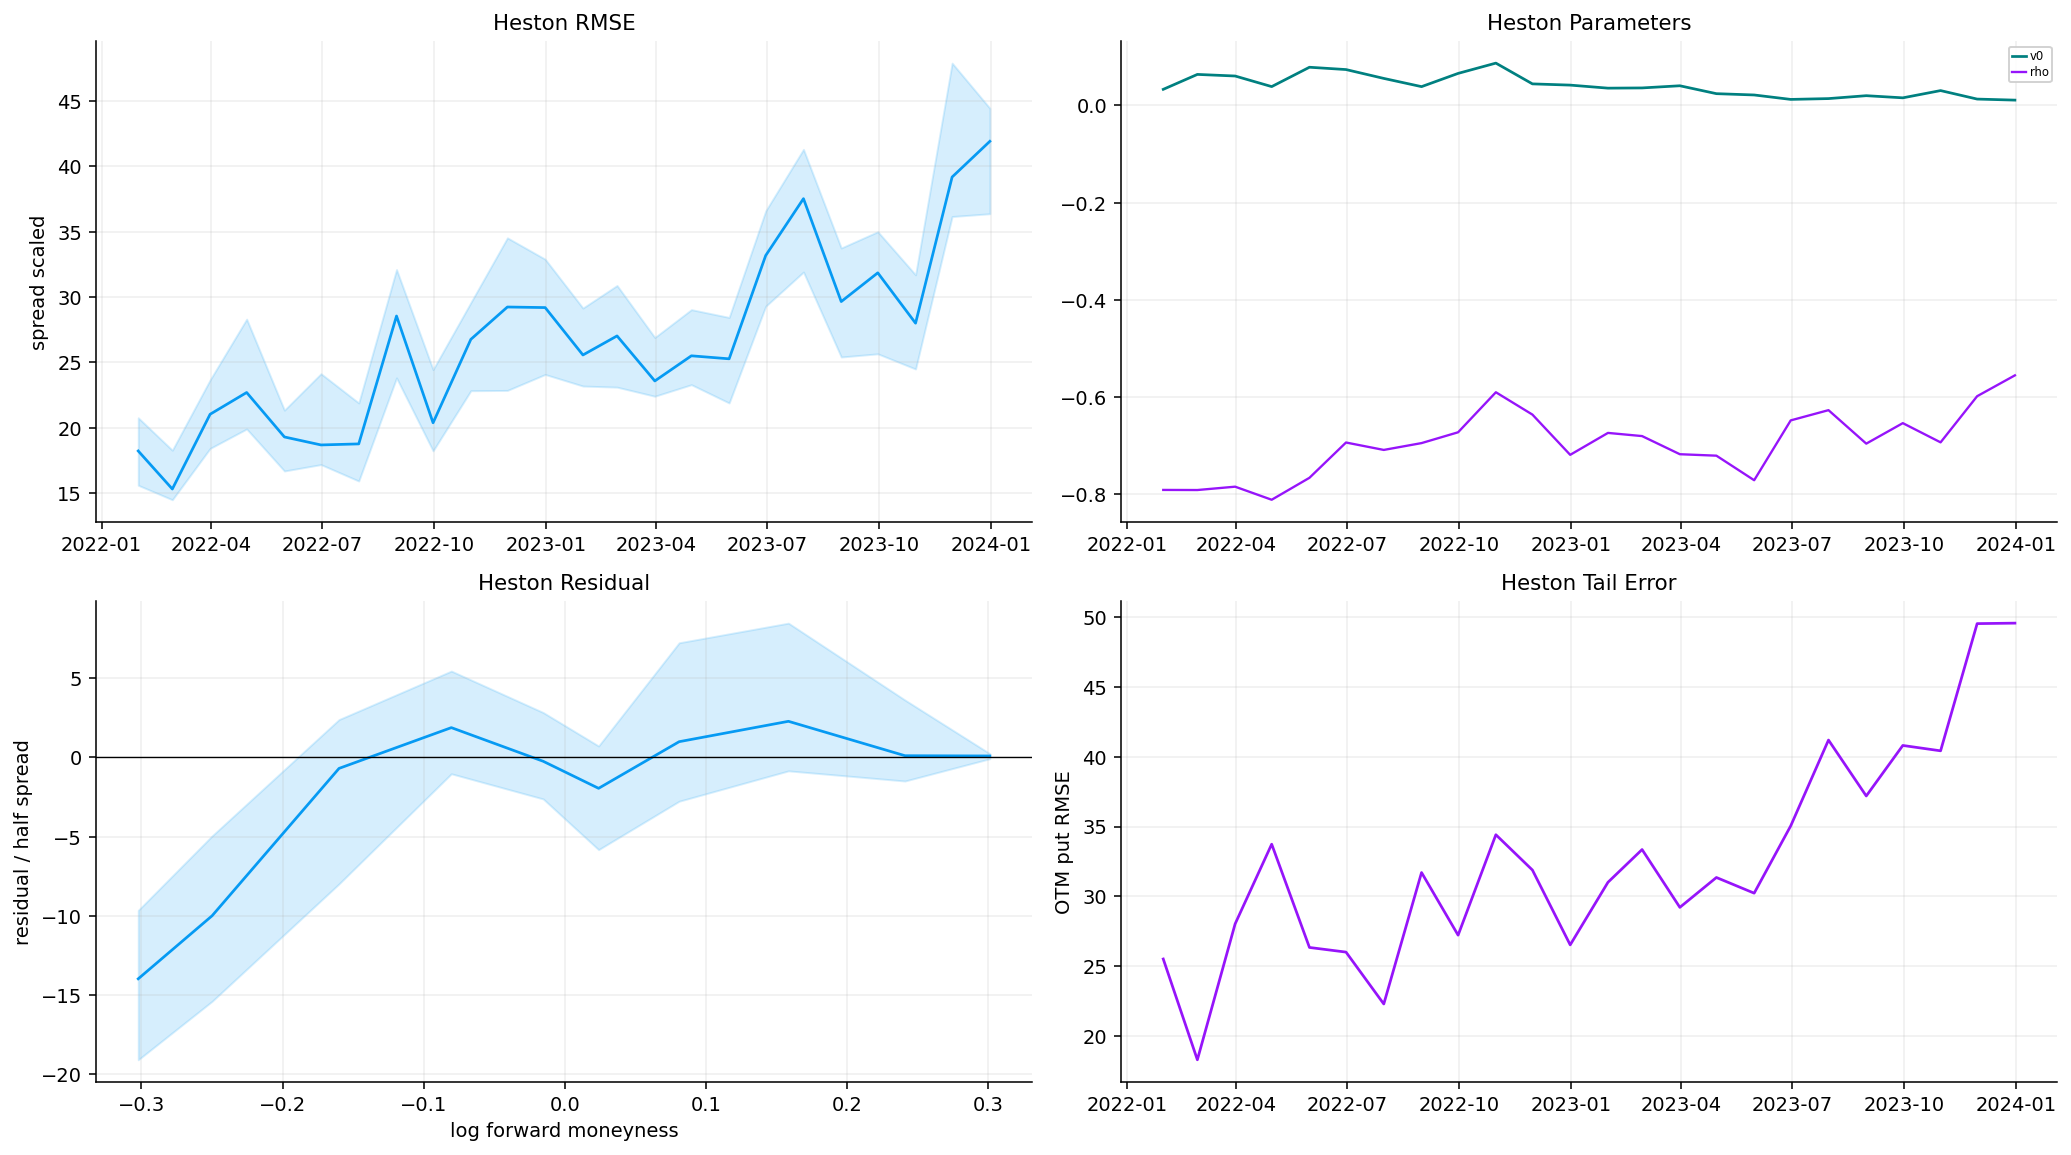

In [ ]:
heston_month = sv_daily_fits[sv_daily_fits["model"].eq("heston")].assign(month=lambda x: x["date"].dt.to_period("M").dt.to_timestamp("M")).groupby("month", observed=True).agg(
    rmse=("weighted_price_rmse", "median"),
    rmse_lo=("weighted_price_rmse", lambda v: np.nanquantile(v, 0.25)),
    rmse_hi=("weighted_price_rmse", lambda v: np.nanquantile(v, 0.75)),
    tail=("otm_put_rmse", "median"),
    v0=("p0", "median"),
    rho=("p4", "median"),
).reset_index()
heston_resid = sv_fit_prices[sv_fit_prices["model"].eq("heston")].copy()
heston_resid["scaled_residual"] = heston_resid["price_residual"] / heston_resid["calib_scale_px"].clip(lower=1e-6)
heston_resid["log_bucket"] = pd.cut(heston_resid["log_moneyness"], [-0.45, -0.30, -0.20, -0.12, -0.06, 0.0, 0.06, 0.12, 0.20, 0.30, 0.45])
heston_smile = heston_resid.groupby("log_bucket", observed=True).agg(x=("log_moneyness", "median"), med=("scaled_residual", "median"), lo=("scaled_residual", lambda v: np.nanquantile(v, 0.25)), hi=("scaled_residual", lambda v: np.nanquantile(v, 0.75))).reset_index()
display(model_10k_certificate[model_10k_certificate["model"].eq("Heston")].round(8))
fig, axes = plt.subplots(2, 2, figsize=(15, 8.4))
axes[0, 0].plot(heston_month["month"], heston_month["rmse"], color=palette[0], lw=1.4)
axes[0, 0].fill_between(heston_month["month"], heston_month["rmse_lo"].to_numpy(float), heston_month["rmse_hi"].to_numpy(float), color=palette[0], alpha=0.16)
axes[0, 0].set_title("Heston RMSE")
axes[0, 0].set_ylabel("spread scaled")
axes[0, 1].plot(heston_month["month"], heston_month["v0"], color=palette[3], lw=1.4, label="v0")
axes[0, 1].plot(heston_month["month"], heston_month["rho"], color=palette[6], lw=1.2, label="rho")
axes[0, 1].set_title("Heston Parameters")
axes[0, 1].legend(**legend_kw)
axes[1, 0].plot(heston_smile["x"], heston_smile["med"], color=palette[0], lw=1.4)
axes[1, 0].fill_between(heston_smile["x"].to_numpy(float), heston_smile["lo"].to_numpy(float), heston_smile["hi"].to_numpy(float), color=palette[0], alpha=0.16)
axes[1, 0].axhline(0.0, color="black", lw=0.7)
axes[1, 0].set_xlabel("log forward moneyness")
axes[1, 0].set_ylabel("residual / half spread")
axes[1, 0].set_title("Heston Residual")
axes[1, 1].plot(heston_month["month"], heston_month["tail"], color=palette[6], lw=1.4)
axes[1, 1].set_title("Heston Tail Error")
axes[1, 1].set_ylabel("OTM put RMSE")
for ax in axes.ravel():
    ax.grid(True, alpha=0.20)
fig.tight_layout(pad=1.25, h_pad=1.0, w_pad=1.0)
plt.show()

### Heston Diagnostics

The Heston diagnostics show RMSE, parameter paths, residual smile, and OTM put error. The most important parameters in the plotted diagnostics are $v_0$ and $\rho$.

The current variance $v_0$ moves with the market's volatility regime. When SPX stress rises, $v_0$ rises. The correlation $\rho$ is usually negative, which is the leverage/skew channel. More negative $\rho$ means downside spot moves are more tightly linked to variance increases.

In Fourier form, this enters the characteristic function through the complex terms $C(u,T)$ and $D(u,T)$. In market language, it changes the relative price of puts and calls across strikes.

The residual smile improves enormously compared with BSM and jump-only models. However, Heston still has structured tail errors because it relies on continuous variance shocks. It can create skew, but abrupt crash jumps may still require a jump component.


,model,rows,direct_numba_runtime,direct_cpp_runtime,direct_speedup_cpp_vs_numba,direct_implementation_median_diff,fft_numba_runtime,fft_cpp_runtime,fft_speedup_cpp_vs_numba,fft_implementation_median_diff,numba_runtime,cpp_runtime,speedup_cpp_vs_numba,numba_reference_error,cpp_reference_error,implementation_max_diff,implementation_median_diff,numba_prices_per_sec,cpp_prices_per_sec
4,Bates,10000,0.265325,0.498537,0.532208,0.000000,0.003509,0.005964,0.588336,0.000000,0.849236,2.176017,0.390271,0.000000,0.000000,0.000000,0.000000,"11,775.282857","4,595.551488"


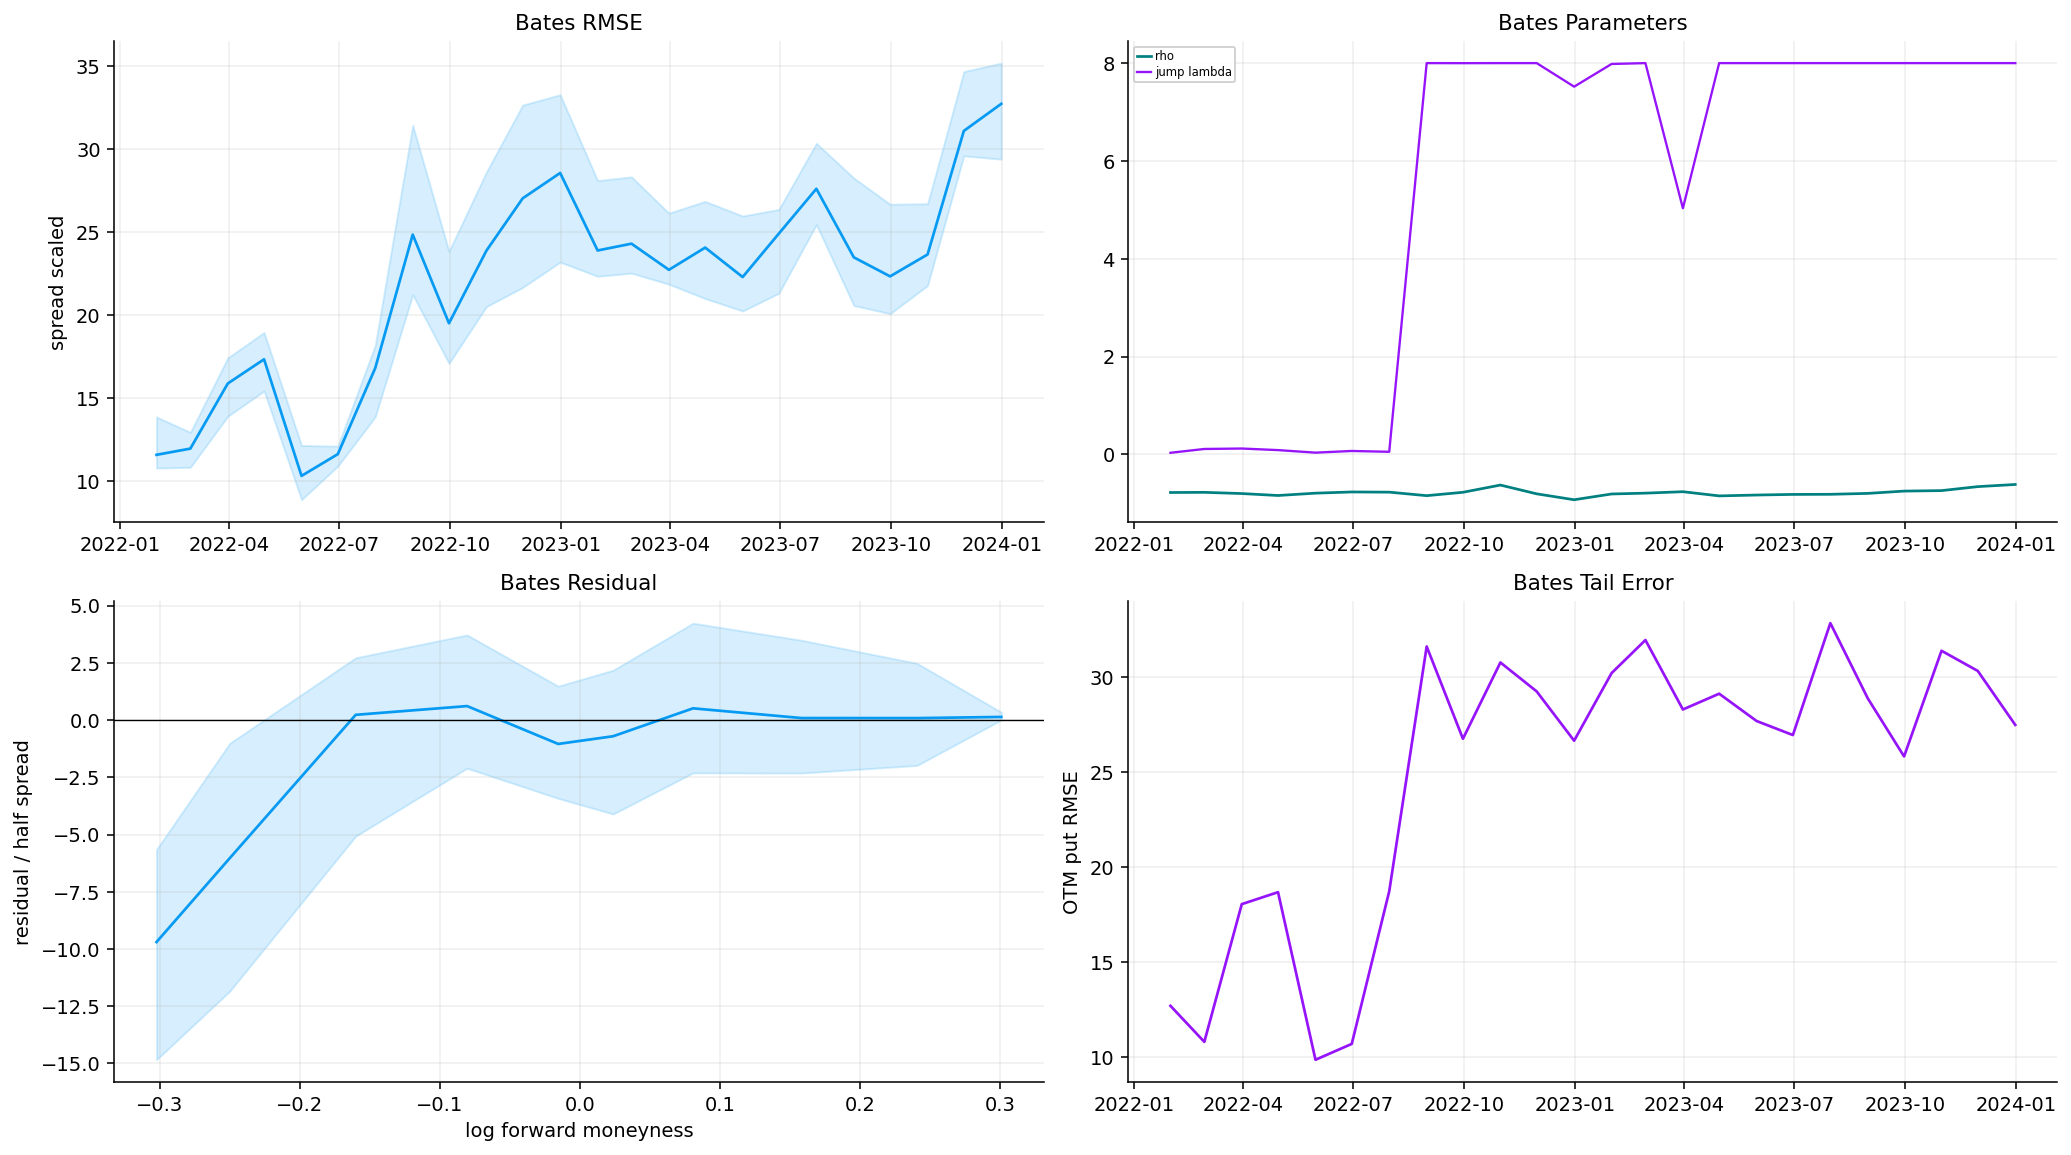

In [ ]:
bates_month = sv_daily_fits[sv_daily_fits["model"].eq("bates")].assign(month=lambda x: x["date"].dt.to_period("M").dt.to_timestamp("M")).groupby("month", observed=True).agg(
    rmse=("weighted_price_rmse", "median"),
    rmse_lo=("weighted_price_rmse", lambda v: np.nanquantile(v, 0.25)),
    rmse_hi=("weighted_price_rmse", lambda v: np.nanquantile(v, 0.75)),
    tail=("otm_put_rmse", "median"),
    rho=("p4", "median"),
    lam=("p5", "median"),
).reset_index()
bates_resid = sv_fit_prices[sv_fit_prices["model"].eq("bates")].copy()
bates_resid["scaled_residual"] = bates_resid["price_residual"] / bates_resid["calib_scale_px"].clip(lower=1e-6)
bates_resid["log_bucket"] = pd.cut(bates_resid["log_moneyness"], [-0.45, -0.30, -0.20, -0.12, -0.06, 0.0, 0.06, 0.12, 0.20, 0.30, 0.45])
bates_smile = bates_resid.groupby("log_bucket", observed=True).agg(x=("log_moneyness", "median"), med=("scaled_residual", "median"), lo=("scaled_residual", lambda v: np.nanquantile(v, 0.25)), hi=("scaled_residual", lambda v: np.nanquantile(v, 0.75))).reset_index()
display(model_10k_certificate[model_10k_certificate["model"].eq("Bates")].round(8))
fig, axes = plt.subplots(2, 2, figsize=(15, 8.4))
axes[0, 0].plot(bates_month["month"], bates_month["rmse"], color=palette[0], lw=1.4)
axes[0, 0].fill_between(bates_month["month"], bates_month["rmse_lo"].to_numpy(float), bates_month["rmse_hi"].to_numpy(float), color=palette[0], alpha=0.16)
axes[0, 0].set_title("Bates RMSE")
axes[0, 0].set_ylabel("spread scaled")
axes[0, 1].plot(bates_month["month"], bates_month["rho"], color=palette[3], lw=1.4, label="rho")
axes[0, 1].plot(bates_month["month"], bates_month["lam"], color=palette[6], lw=1.2, label="jump lambda")
axes[0, 1].set_title("Bates Parameters")
axes[0, 1].legend(**legend_kw)
axes[1, 0].plot(bates_smile["x"], bates_smile["med"], color=palette[0], lw=1.4)
axes[1, 0].fill_between(bates_smile["x"].to_numpy(float), bates_smile["lo"].to_numpy(float), bates_smile["hi"].to_numpy(float), color=palette[0], alpha=0.16)
axes[1, 0].axhline(0.0, color="black", lw=0.7)
axes[1, 0].set_xlabel("log forward moneyness")
axes[1, 0].set_ylabel("residual / half spread")
axes[1, 0].set_title("Bates Residual")
axes[1, 1].plot(bates_month["month"], bates_month["tail"], color=palette[6], lw=1.4)
axes[1, 1].set_title("Bates Tail Error")
axes[1, 1].set_ylabel("OTM put RMSE")
for ax in axes.ravel():
    ax.grid(True, alpha=0.20)
fig.tight_layout(pad=1.25, h_pad=1.0, w_pad=1.0)
plt.show()

### Bates Diagnostics

Bates combines Heston's stochastic variance with Merton's jump component. The calibration result shows why that combination is useful. Bates produces the lowest average weighted RMSE and tail RMSE among the final SPX models.

The model has two tail channels:

1. **Stochastic volatility:** negative $\rho$ raises downside variance when the index falls.
2. **Jumps:** negative or volatile jump sizes add direct crash probability.

The fitted Bates residual smile is much closer to zero across most moneyness buckets. It still underprices the far left wing in some places, but the error is much smaller than BSM's deep negative residuals.

The price of the improvement is computational. Bates is slowest and has the lowest success rate among the main fitted models. That is exactly the tradeoff a production desk faces: better surface fit versus calibration stability and runtime.


### Why Bates Can Win While Looking Messier

Bates has more parameters and lower success rate, so its results need careful reading. The model can fit more surface features because it has more channels:

$$
\theta_{Bates}=(v_0,\kappa,\bar{v},\xi,\rho,\lambda,\mu_J,\sigma_J)
$$

The stochastic-volatility block shapes the persistent skew and volatility term structure. The jump block adds discrete crash risk. When both are present, the optimizer can match far more of the SPX surface.

The downside is that the parameters are less uniquely identified. For example, a short-dated put wing can be made expensive by:

- increasing jump intensity $\lambda$,
- making jump mean $\mu_J$ more negative,
- raising jump volatility $\sigma_J$,
- raising vol-of-vol $\xi$,
- making correlation $\rho$ more negative,
- or raising current variance $v_0$.

These choices don't have identical effects, but they can partially substitute in finite data. That is why the notebook doesn't rely on a single Bates parameter story. It evaluates Bates by out-of-sample-style diagnostics inside the sample: residual shape, tail RMSE, success rate, and tail probabilities.


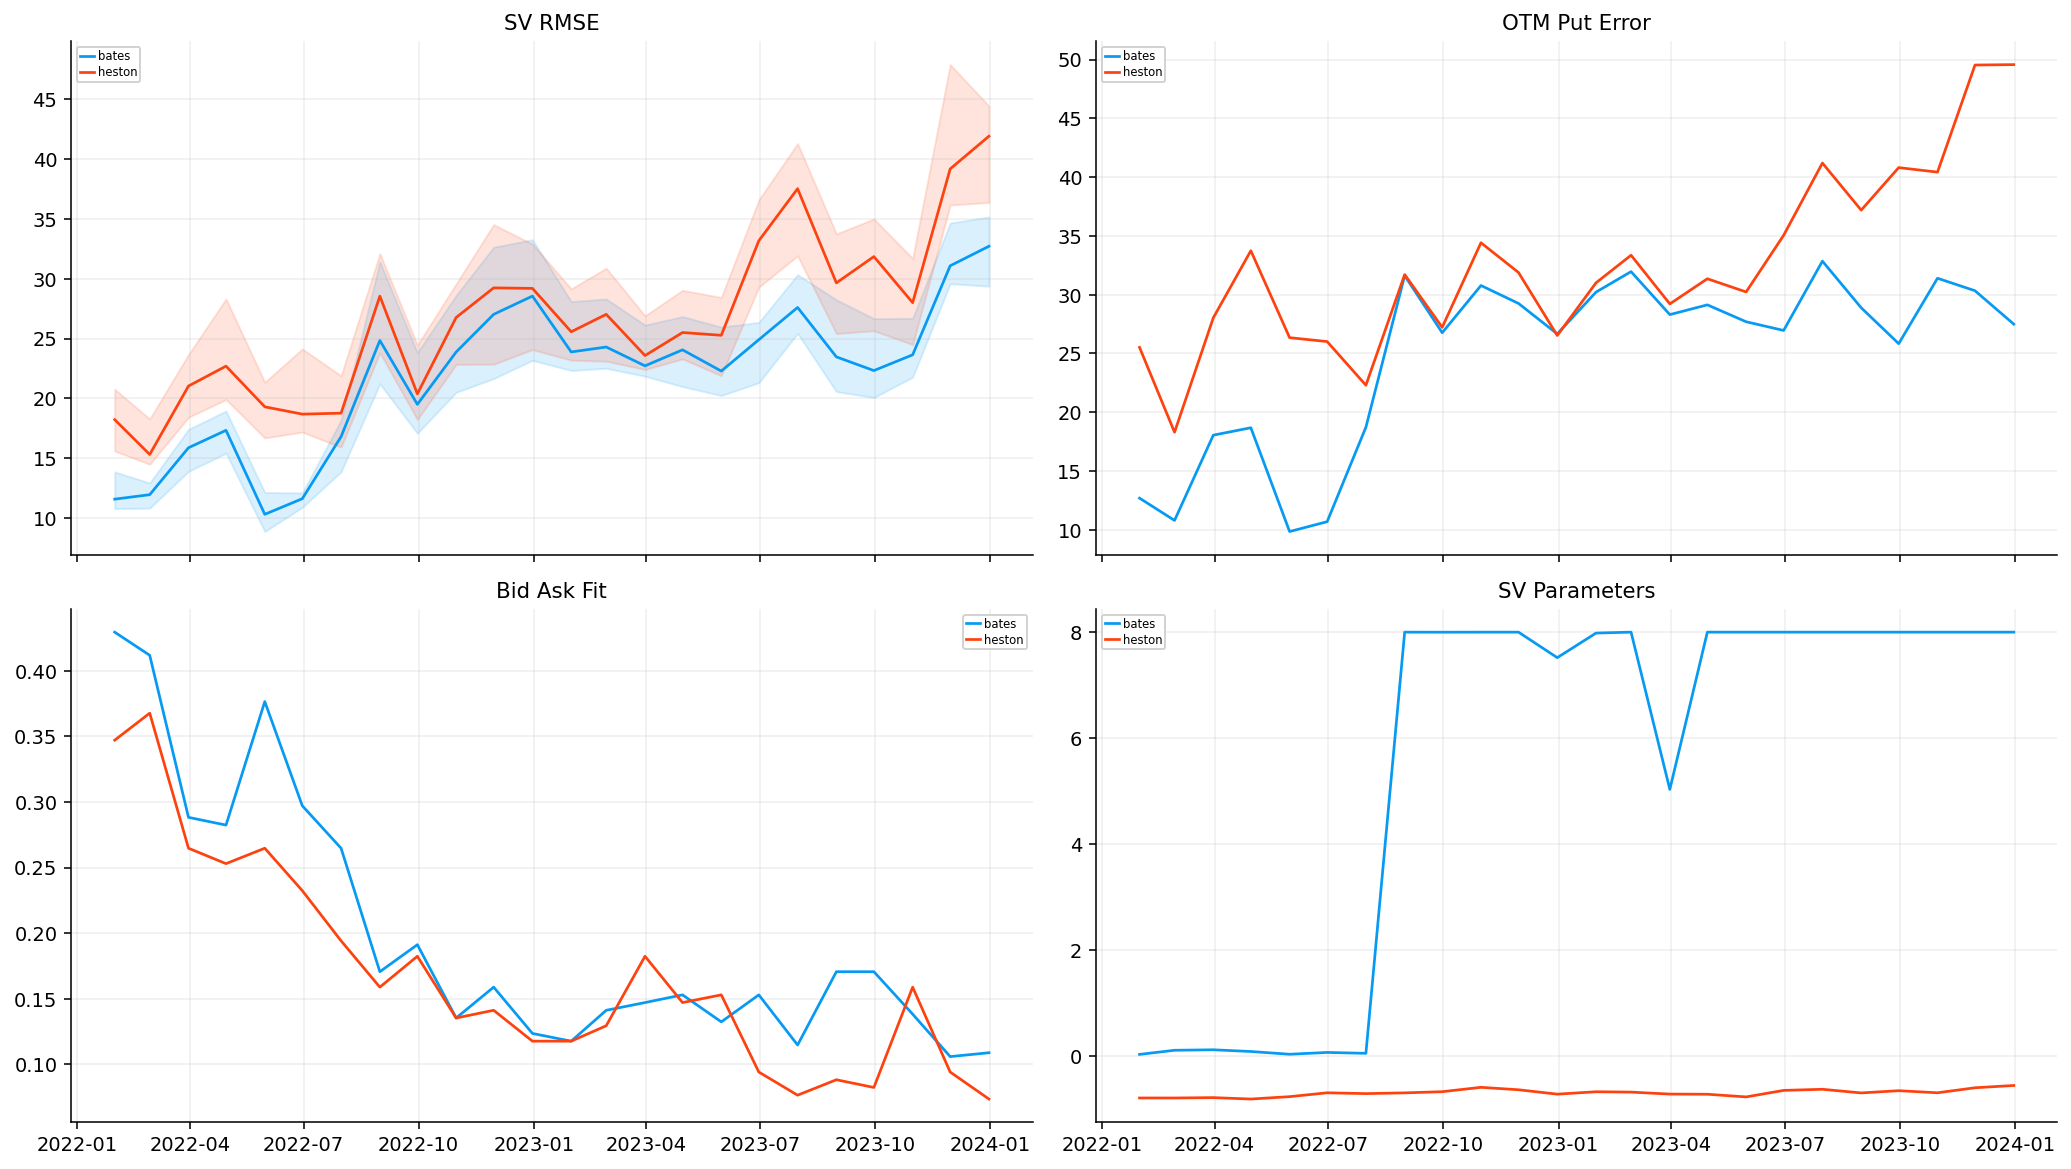

In [ ]:
sv_plot = sv_daily_fits.copy()
sv_plot["month"] = sv_plot["date"].dt.to_period("M").dt.to_timestamp("M")
sv_month = sv_plot.groupby(["model", "month"], observed=True).agg(
    rmse=("weighted_price_rmse", "median"),
    rmse_lo=("weighted_price_rmse", lambda v: np.nanquantile(v, 0.25)),
    rmse_hi=("weighted_price_rmse", lambda v: np.nanquantile(v, 0.75)),
    otm=("otm_put_rmse", "median"),
    hit=("bid_ask_hit_rate", "median"),
    v0=("p0", "median"),
    rho=("p4", "median"),
    jump=("p5", "median"),
).reset_index()
fig, axes = plt.subplots(2, 2, figsize=(15, 8.5), sharex=True)
for i, (model, g) in enumerate(sv_month.groupby("model")):
    g = g.sort_values("month")
    axes[0, 0].plot(g["month"], g["rmse"], lw=1.4, color=palette[i], label=model)
    axes[0, 0].fill_between(g["month"], g["rmse_lo"].to_numpy(float), g["rmse_hi"].to_numpy(float), color=palette[i], alpha=0.14)
    axes[0, 1].plot(g["month"], g["otm"], lw=1.4, color=palette[i], label=model)
    axes[1, 0].plot(g["month"], g["hit"], lw=1.4, color=palette[i], label=model)
    y = g["jump"] if model == "bates" and g["jump"].notna().any() else g["rho"]
    axes[1, 1].plot(g["month"], y, lw=1.4, color=palette[i], label=model)
axes[0, 0].set_title("SV RMSE")
axes[0, 1].set_title("OTM Put Error")
axes[1, 0].set_title("Bid Ask Fit")
axes[1, 1].set_title("SV Parameters")
for ax in axes.ravel():
    ax.legend(**legend_kw)
    ax.grid(True, alpha=0.20)
fig.tight_layout(pad=1.25, h_pad=1.0, w_pad=1.0)
plt.show()

The SV comparison plot shows Bates and Heston moving together through time, with Bates usually lower on RMSE and OTM put error. The bid/ask fit is also better for Bates. The parameter panel shows the extra jump component becoming part of the fitted surface behavior.

This is useful because it separates two kinds of model complexity:

- Heston complexity explains time-varying variance and skew.
- Bates complexity explains both variance dynamics and discrete jump premium.

For SPX index options in 2022-2023, the market seems to reward the second kind. The surface contains enough tail structure that Bates' extra jump flexibility improves the fit materially.


## 13) Final Model Tournament

The final tournament compares the baseline diffusion model, the winning jump model, and the winning stochastic-volatility model on the same common date set. The goal is to compare model families on fit quality, tail error, runtime, and stability using the same calibration grid.


In [ ]:
common_dates = sorted(
    set(pd.to_datetime(bsm_daily_fits["date"]).dt.normalize())
    & set(pd.to_datetime(jump_daily_fits[jump_daily_fits["model"].eq(best_jump)]["date"]).dt.normalize())
    & set(pd.to_datetime(sv_daily_fits[sv_daily_fits["model"].eq(best_sv)]["date"]).dt.normalize())
)
final_daily_all = pd.concat([
    bsm_daily_fits,
    jump_daily_fits[jump_daily_fits["model"].eq(best_jump)],
    sv_daily_fits[sv_daily_fits["model"].eq(best_sv)],
], ignore_index=True)
final_daily = final_daily_all[final_daily_all["date"].isin(common_dates)].copy()
final_model_comparison = final_daily.groupby("model", as_index=False).agg(dates=("date", "nunique"), quotes=("quotes", "sum"), success_rate=("success", "mean"), weighted_price_rmse=("weighted_price_rmse", "mean"), median_abs_price_error=("median_abs_price_error", "median"), bid_ask_hit_rate=("bid_ask_hit_rate", "mean"), otm_put_rmse=("otm_put_rmse", "mean"), runtime_sec=("runtime_sec", "sum")).sort_values("weighted_price_rmse")
display(pd.DataFrame([{"common_dates": len(common_dates), "start": min(common_dates), "end": max(common_dates)}]))
display(final_model_comparison.round(6))

,common_dates,start,end
0,505,2022-01-03,2023-12-29


,model,dates,quotes,success_rate,weighted_price_rmse,median_abs_price_error,bid_ask_hit_rate,otm_put_rmse,runtime_sec
0,bates,505,85850,0.845545,22.253968,0.709802,0.198858,25.452794,"1,450.239977"
2,merton,505,85850,0.998020,82.246634,2.494583,0.089109,93.947641,193.025027
1,bsm,505,85850,1.000000,259.511954,8.697427,0.036808,359.590318,26.777009


The final comparison keeps only the common dates where BSM, the best jump model, and the best stochastic-volatility model are all available. That gives **505 common dates** from 2022-01-03 to 2023-12-29.

The final ranking is clear:

| Model family | Selected model | Main role |
|---|---|---|
| Diffusion | BSM | baseline and sanity check |
| Jump | Merton | finite crash-risk improvement |
| Stochastic volatility + jumps | Bates | best surface fit |

The final weighted RMSE values are approximately:

$$
RMSE_{Bates}=22.25
$$

$$
RMSE_{Merton}=82.25
$$

$$
RMSE_{BSM}=259.51
$$

The OTM put RMSE tells the same story:

$$
\text{OTM put RMSE}_{Bates}=25.45
$$

$$
\text{OTM put RMSE}_{Merton}=93.95
$$

$$
\text{OTM put RMSE}_{BSM}=359.59
$$

This is a huge improvement from diffusion to jumps, and another huge improvement from jumps to jump-stochastic volatility.


### 13.1 Model Risk in the Final Ranking

The final ranking is clear, but model comparison still needs caution. Bates wins because it has the best fit, not because it is the true data-generating process. A flexible model can fit the cross-section better while producing less stable parameters.

The calibration problem is ill-conditioned in some regions. For example, Bates jump intensity and Heston vol-of-vol can both raise short-dated wing prices. Several parameter combinations can reduce RMSE in similar ways. That is why we look at:

- success rate,
- runtime,
- residual shape,
- OTM put RMSE,
- tail probability disagreement,
- and hedge behavior.

The strongest practical result is that BSM is inadequate, Merton is a big improvement, and Bates is the best surface model in this experiment. The weaker claim would be to say the Bates parameters themselves are all economically stable day by day. The notebook avoids relying only on parameter interpretation; it checks prices, residuals, and tail quantities.


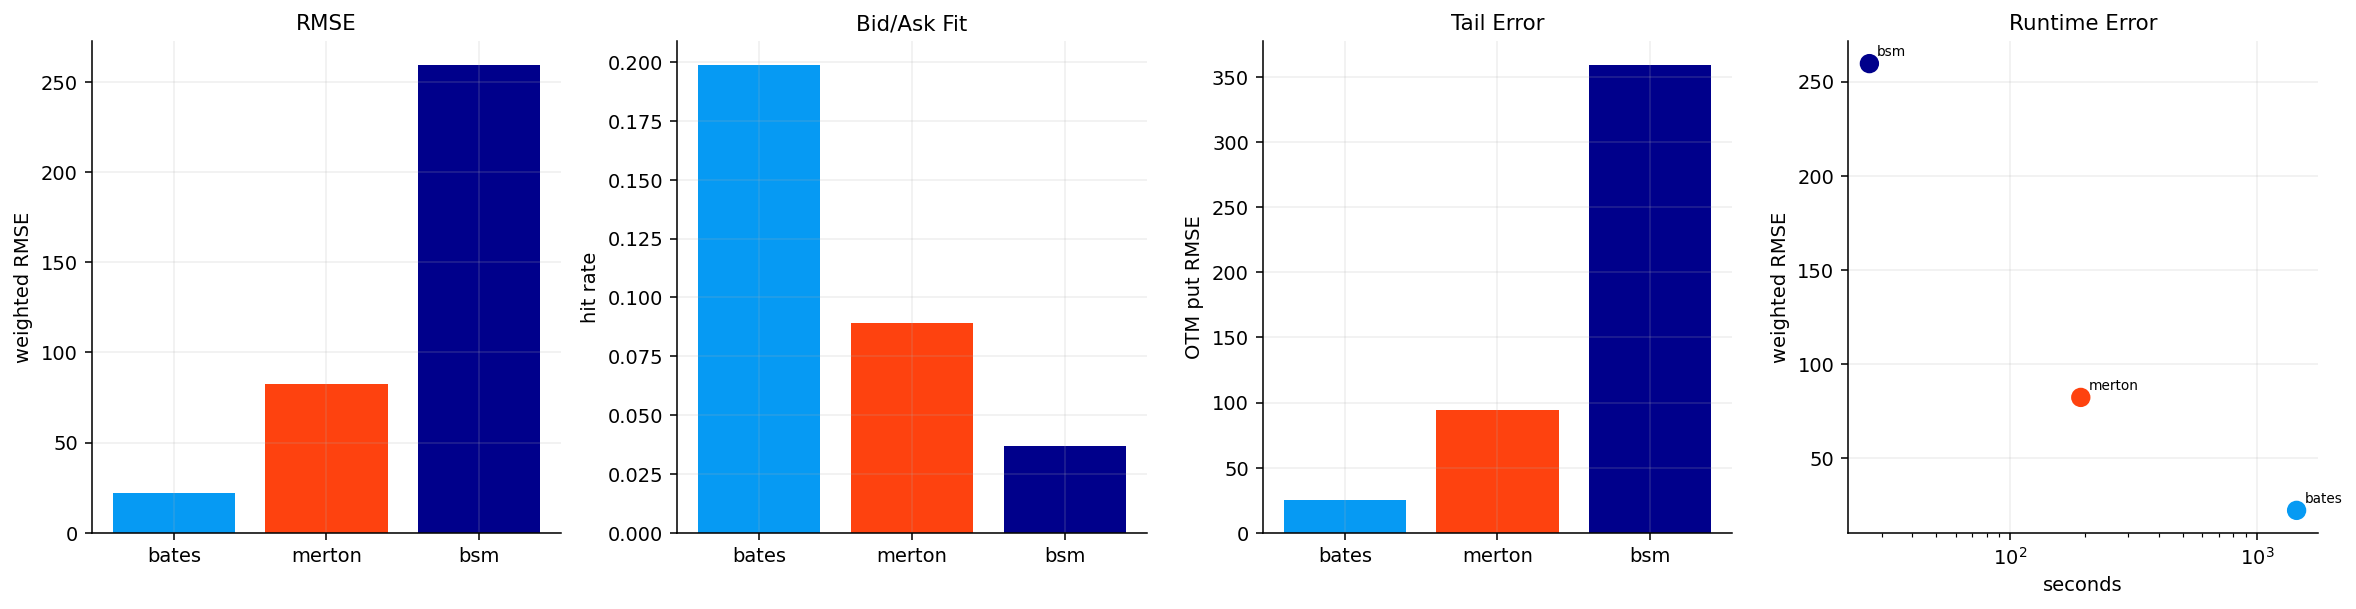

In [ ]:
fig, axes = plt.subplots(1, 4, figsize=(17, 4.5))
axes[0].bar(final_model_comparison["model"], final_model_comparison["weighted_price_rmse"], color=palette[:len(final_model_comparison)])
axes[0].set_ylabel("weighted RMSE")
axes[0].set_title("RMSE")
axes[1].bar(final_model_comparison["model"], final_model_comparison["bid_ask_hit_rate"], color=palette[:len(final_model_comparison)])
axes[1].set_ylabel("hit rate")
axes[1].set_title("Bid/Ask Fit")
axes[2].bar(final_model_comparison["model"], final_model_comparison["otm_put_rmse"], color=palette[:len(final_model_comparison)])
axes[2].set_ylabel("OTM put RMSE")
axes[2].set_title("Tail Error")
axes[3].scatter(final_model_comparison["runtime_sec"], final_model_comparison["weighted_price_rmse"], s=80, color=palette[:len(final_model_comparison)])
for _, row in final_model_comparison.iterrows():
    axes[3].annotate(row["model"], (row["runtime_sec"], row["weighted_price_rmse"]), fontsize=7, xytext=(4, 4), textcoords="offset points")
axes[3].set_xscale("log")
axes[3].set_xlabel("seconds")
axes[3].set_ylabel("weighted RMSE")
axes[3].set_title("Runtime Error")
fig.tight_layout(pad=1.25, h_pad=1.0, w_pad=1.0)
plt.show()

The tournament plot makes the tradeoff visible. Bates dominates on RMSE, bid/ask hit rate, and tail error. Merton sits in the middle. BSM is fastest but weakest. Runtime is on a log scale because Bates is much more expensive than the simple models.

The important model-comparison point is that speed alone isn't a good objective. BSM is cheap because it is too simple. Bates is expensive because it is trying to fit the actual shape of the SPX surface. In a calibration pipeline, the right model depends on what we need:

- for a quick volatility proxy, BSM is enough;
- for rough jump-tail pricing, Merton is useful;
- for detailed surface and tail diagnostics, Bates is the strongest here.

The project then uses this model hierarchy to study residuals, tail probabilities, and hedging overlays.


### Residual Smile and Term Diagnostics

Residual diagnostics show where each model fails. The residual is scaled by quote half-spread:

$$
z_j=\frac{\hat{V}_j-V_j^{mkt}}{\text{half-spread}_j}
$$

This makes errors comparable across cheap and expensive options. A residual of $-10$ means the model price is ten half-spreads below the market. That is economically meaningful because the model is outside the market by a large amount relative to quote width.

The residual smile table already shows the central message. In the deep left-wing bucket $(-0.45,-0.30]$, BSM has a median residual around **-53.66**, while Bates is around **-9.70**. Both underprice far OTM puts, but Bates is much closer.

Across the middle of the smile, Bates residuals are near zero compared with BSM. That tells us the Bates model is not only lowering average RMSE by fitting ATM options. It genuinely improves the moneyness structure.


### Residual Diagnostics as Model Surgery

Residuals are more informative than one scalar error because they show which part of the surface the model can't explain. We can organize residual failures into three directions.

**Moneyness residuals** tell us whether the model fits skew and smile:

$$
z(k)=\text{median}\left(\frac{\hat{V}-V^{mkt}}{\text{half-spread}}\mid \log(K/F)\in \text{bucket}(k)\right)
$$

If $z(k)$ is very negative on the left wing, the model underprices downside protection. If it is positive on the right wing, the model overprices upside calls.

**Term residuals** tell us whether the model fits maturity structure:

$$
z(T)=\text{median}\left(\frac{\hat{V}-V^{mkt}}{\text{half-spread}}\mid DTE\in \text{bucket}(T)\right)
$$

A short-maturity error usually points to jumps, event risk, or near-term variance. A long-maturity error usually points to term-structure limitations.

**Stress residuals** tell us whether the model survives the dates where the market surface is hardest. A model can look acceptable in calm periods and fail exactly when hedging matters. That is why the notebook isolates the worst RMSE dates and plots their residual smiles separately.

This diagnostic structure is one of the strongest parts of the project. It turns calibration from a single number into a map of model weaknesses.


In [ ]:
final_fit_prices = pd.concat([
    bsm_fit_prices[bsm_fit_prices["date"].isin(common_dates)],
    jump_fit_prices[jump_fit_prices["model"].eq(best_jump) & jump_fit_prices["date"].isin(common_dates)],
    sv_fit_prices[sv_fit_prices["model"].eq(best_sv) & sv_fit_prices["date"].isin(common_dates)],
], ignore_index=True)
residual_work = final_fit_prices.copy()
residual_work["scaled_residual"] = residual_work["price_residual"] / residual_work["calib_scale_px"].clip(lower=1e-6)
residual_work["log_bucket"] = pd.cut(residual_work["log_moneyness"], [-0.45, -0.30, -0.20, -0.12, -0.06, 0.0, 0.06, 0.12, 0.20, 0.30, 0.45])
residual_work["dte_bucket"] = pd.cut(residual_work["dte_days"], [7, 14, 30, 60, 90, 120, 180])
residual_smile = residual_work.groupby(["model", "log_bucket"], observed=True).agg(x=("log_moneyness", "median"), med=("scaled_residual", "median"), lo=("scaled_residual", lambda v: np.nanquantile(v, 0.25)), hi=("scaled_residual", lambda v: np.nanquantile(v, 0.75)), rows=("scaled_residual", "size")).reset_index()
residual_term = residual_work.groupby(["model", "dte_bucket"], observed=True).agg(x=("dte_days", "median"), med=("scaled_residual", "median"), lo=("scaled_residual", lambda v: np.nanquantile(v, 0.25)), hi=("scaled_residual", lambda v: np.nanquantile(v, 0.75)), rows=("scaled_residual", "size")).reset_index()
display(residual_smile.iloc[:12].round(5))

,model,log_bucket,x,med,lo,hi,rows
0,bates,"(-0.45, -0.3]",-0.302260,-9.697950,-14.840410,-5.655810,2245
1,bates,"(-0.3, -0.2]",-0.249920,-6.031760,-11.845140,-1.013670,10237
2,bates,"(-0.2, -0.12]",-0.159980,0.228780,-5.073810,2.722390,10265
3,bates,"(-0.12, -0.06]",-0.080420,0.610510,-2.105950,3.718370,7553
4,bates,"(-0.06, 0.0]",-0.015340,-1.043290,-3.421730,1.481420,12790
5,bates,"(0.0, 0.06]",0.023910,-0.706820,-4.104870,2.180000,16894
6,bates,"(0.06, 0.12]",0.080980,0.512120,-2.308760,4.234060,11040
7,bates,"(0.12, 0.2]",0.158410,0.087790,-2.317150,3.487990,10366
8,bates,"(0.2, 0.3]",0.240990,0.085860,-1.983020,2.478890,4392
9,bates,"(0.3, 0.45]",0.301130,0.136150,0.003230,0.345160,68


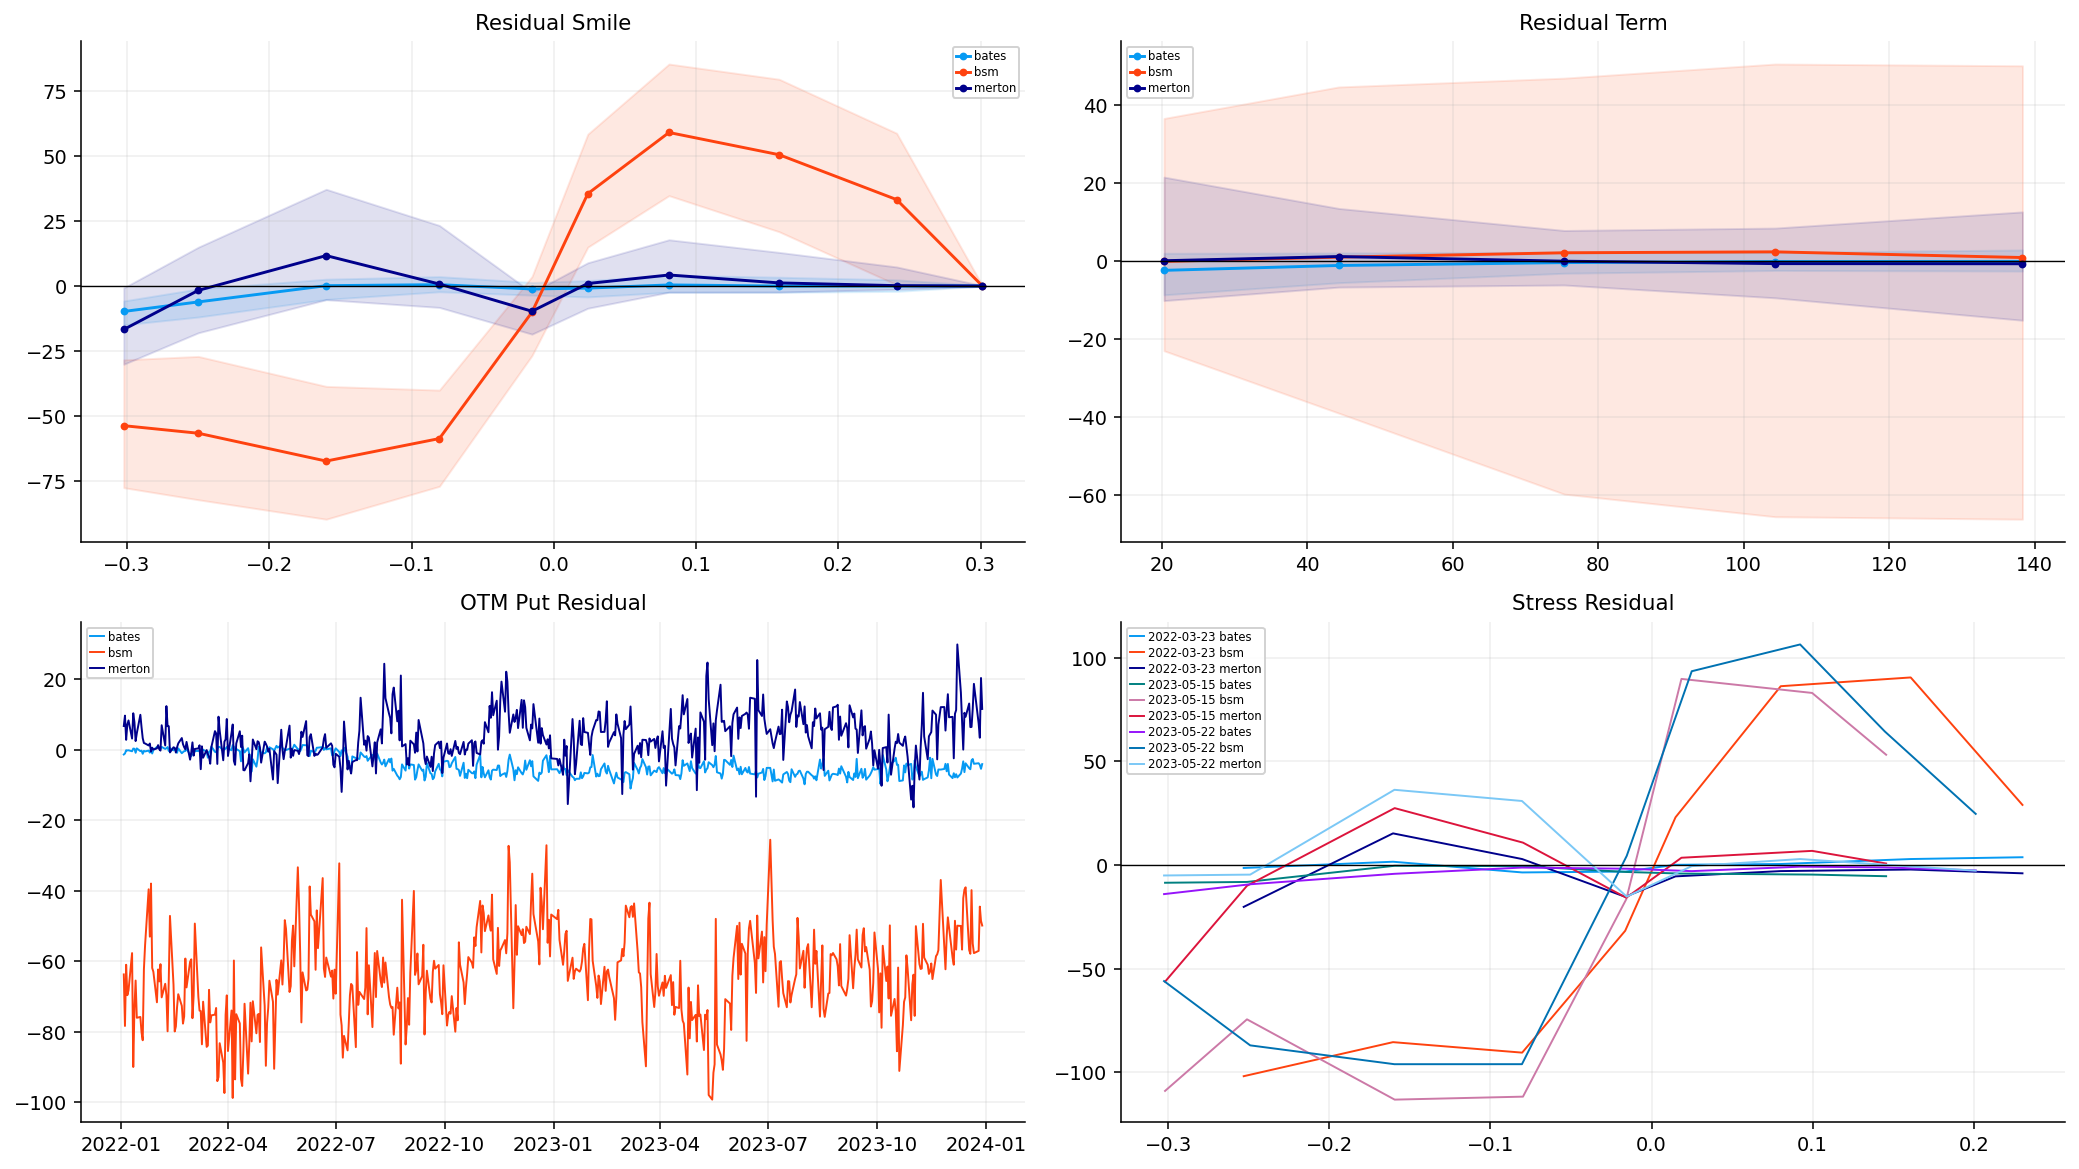

In [ ]:
stress_dates = final_daily.sort_values("weighted_price_rmse", ascending=False)["date"].drop_duplicates().iloc[:3].tolist()
otm_put = residual_work[residual_work["option_type"].astype(str).str.lower().str.startswith("p") & residual_work["moneyness"].le(0.90)].groupby(["date", "model"])["scaled_residual"].median().reset_index()
stress_residual = residual_work[residual_work["date"].isin(stress_dates)].groupby(["date", "model", "log_bucket"], observed=True).agg(x=("log_moneyness", "median"), med=("scaled_residual", "median"), lo=("scaled_residual", lambda v: np.nanquantile(v, 0.25)), hi=("scaled_residual", lambda v: np.nanquantile(v, 0.75))).reset_index()
fig, axes = plt.subplots(2, 2, figsize=(15, 8.5))
for i, (model, g) in enumerate(residual_smile.groupby("model")):
    axes[0, 0].plot(g["x"], g["med"], marker="o", ms=3, color=palette[i], label=model)
    axes[0, 0].fill_between(g["x"].to_numpy(float), g["lo"].to_numpy(float), g["hi"].to_numpy(float), color=palette[i], alpha=0.12)
for i, (model, g) in enumerate(residual_term.groupby("model")):
    axes[0, 1].plot(g["x"], g["med"], marker="o", ms=3, color=palette[i], label=model)
    axes[0, 1].fill_between(g["x"].to_numpy(float), g["lo"].to_numpy(float), g["hi"].to_numpy(float), color=palette[i], alpha=0.12)
for i, (model, g) in enumerate(otm_put.groupby("model")):
    axes[1, 0].plot(g["date"], g["scaled_residual"], lw=1.0, color=palette[i], label=model)
for i, ((date, model), g) in enumerate(stress_residual.groupby(["date", "model"])):
    axes[1, 1].plot(g["x"], g["med"], lw=1.0, color=palette[i % len(palette)], label=f"{pd.Timestamp(date).date()} {model}")
axes[0, 0].axhline(0, color="black", lw=0.7)
axes[0, 1].axhline(0, color="black", lw=0.7)
axes[1, 1].axhline(0, color="black", lw=0.7)
axes[0, 0].set_title("Residual Smile")
axes[0, 1].set_title("Residual Term")
axes[1, 0].set_title("OTM Put Residual")
axes[1, 1].set_title("Stress Residual")
for ax in axes.ravel():
    ax.legend(**legend_kw)
fig.tight_layout(pad=1.25, h_pad=1.0, w_pad=1.0)
plt.show()

The residual plots show four diagnostic views.

The residual smile plot confirms that BSM severely underprices downside puts. Merton reduces the left-wing error, and Bates reduces it further. The residual term plot shows whether errors cluster by maturity. If a model fits short expiries but misses longer ones, the term residual will bend. The OTM put residual time series shows when downside-tail mispricing is worst. The stress residual panel isolates the hardest dates.

These plots are important because a low average RMSE can hide systematic model failure. A model that is always wrong in the deep left wing may look acceptable if most quotes are near ATM. Here the OTM put diagnostics prevent that.


## 14) Tail Probabilities from the Fitted Models

Once we have fitted models, we can ask distributional questions directly. For a crash level $L$, the tail probability is:

$$
P\left(\frac{S_T}{S_0}\le L\right)=\int_{-\infty}^{\log(LS_0)}f_{X_T}(x)\,dx
$$

The notebook computes this by recovering the model-implied density from the characteristic function and integrating the left tail.

Three crash levels are used:

$$
L\in\{0.90,0.85,0.80\}
$$

These correspond to 10%, 15%, and 20% downside moves over the chosen horizon. For tail hedging, the 80% and 85% levels are especially important because they connect to deep OTM put payoff convexity.


### 14.1 Tail Probability as a Model-Implied Quantity

A tail probability from an option model is risk-neutral, not physical. It answers:

$$
Q(S_T/S_0\le L)
$$

not:

$$
P(S_T/S_0\le L)
$$

The risk-neutral probability includes risk premia embedded in option prices. If investors are willing to pay a lot for crash protection, the fitted model may imply high crash probability even if the real-world probability is lower. That is not an error. Option prices reflect both probability and compensation for bearing tail risk.

For hedge selection, this is still useful. We are buying options in the risk-neutral market. If the market is pricing high crash risk, option premiums will be high. If the model thinks crash probability is high relative to the premium paid, some puts may look attractive.

The model disagreement is also useful. If Bates says the 80% crash probability is high and BSM says it is tiny, the difference tells us the tail estimate depends strongly on distributional assumptions. A model-risk-aware selector can prefer options that look acceptable across models rather than depending on one aggressive tail estimate.


In [ ]:
def params_from_row(model, row):
    count = {"bsm": 1, "merton": 4, "vg": 3, "heston": 5, "bates": 8}[model]
    return row[[f"p{i}" for i in range(count)]].to_numpy(float)

tail_dates = pd.DatetimeIndex(sorted(set(pd.to_datetime(sv_dates[::max(1, len(sv_dates)//24)]).tolist() + pd.to_datetime(stress_dates).tolist())))
tail_rows = []
density_rows = []
for d in tail_dates:
    qd = calibration_quotes[calibration_quotes["date"].eq(pd.Timestamp(d).normalize())]
    if qd.empty:
        continue
    s = float(qd["spot"].median())
    r = float(qd["rate"].median())
    q = float(qd["dividend_yield"].median())
    x = np.linspace(np.log(s) - 0.55, np.log(s) + 0.35, 520)
    for model in ["bsm", best_jump, best_sv]:
        source = final_daily[final_daily["model"].eq(model)]
        source = source[source["date"].le(pd.Timestamp(d).normalize())].sort_values("date")
        if source.empty:
            continue
        p = params_from_row(model, source.iloc[-1])
        den = density_from_cf(model_id(model), p, x, s, r, q, 60 / ann_days, 180.0, 1024)
        area = np.trapezoid(den, x)
        if area > 0:
            den = den / area
        rel = np.exp(x) / s
        for level in [0.90, 0.85, 0.80]:
            tail_rows.append({"date": pd.Timestamp(d).normalize(), "model": model, "level": level, "tail_probability": float(np.trapezoid(den[rel <= level], x[rel <= level]))})
        if d in stress_dates or d == tail_dates[0] or d == tail_dates[-1]:
            for xi, yi in zip(rel, den):
                density_rows.append({"date": pd.Timestamp(d).normalize(), "model": model, "s_over_s0": xi, "density": yi, "dividend_yield": q})
tail_diagnostics = pd.DataFrame(tail_rows)
density_summary = pd.DataFrame(density_rows)
display(tail_diagnostics.groupby(["model", "level"])["tail_probability"].agg(["mean", "max"]).reset_index().round(6))

,model,level,mean,max
0,bates,0.800000,0.026241,0.053461
1,bates,0.850000,0.050506,0.093037
2,bates,0.900000,0.095225,0.156473
3,bsm,0.800000,0.005277,0.022120
4,bsm,0.850000,0.024829,0.073800
5,bsm,0.900000,0.088169,0.179700
6,merton,0.800000,0.034291,0.069443
7,merton,0.850000,0.054513,0.101891
8,merton,0.900000,0.081787,0.143681


The fitted average tail probabilities show clear model disagreement. At the 80% level, BSM assigns only about **0.53%** average probability, Bates about **2.62%**, and Merton about **3.43%**. At the 90% level, all models are closer, but still disagree on timing and magnitude.

This is exactly why tail overlays use model disagreement. Tail probabilities are not directly observable, and different risk-neutral models can imply very different crash risks while fitting the surface with different quality.


C:\Users\Lenovo\AppData\Local\Temp\ipykernel_6324\2226895617.py:20: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(**legend_kw)


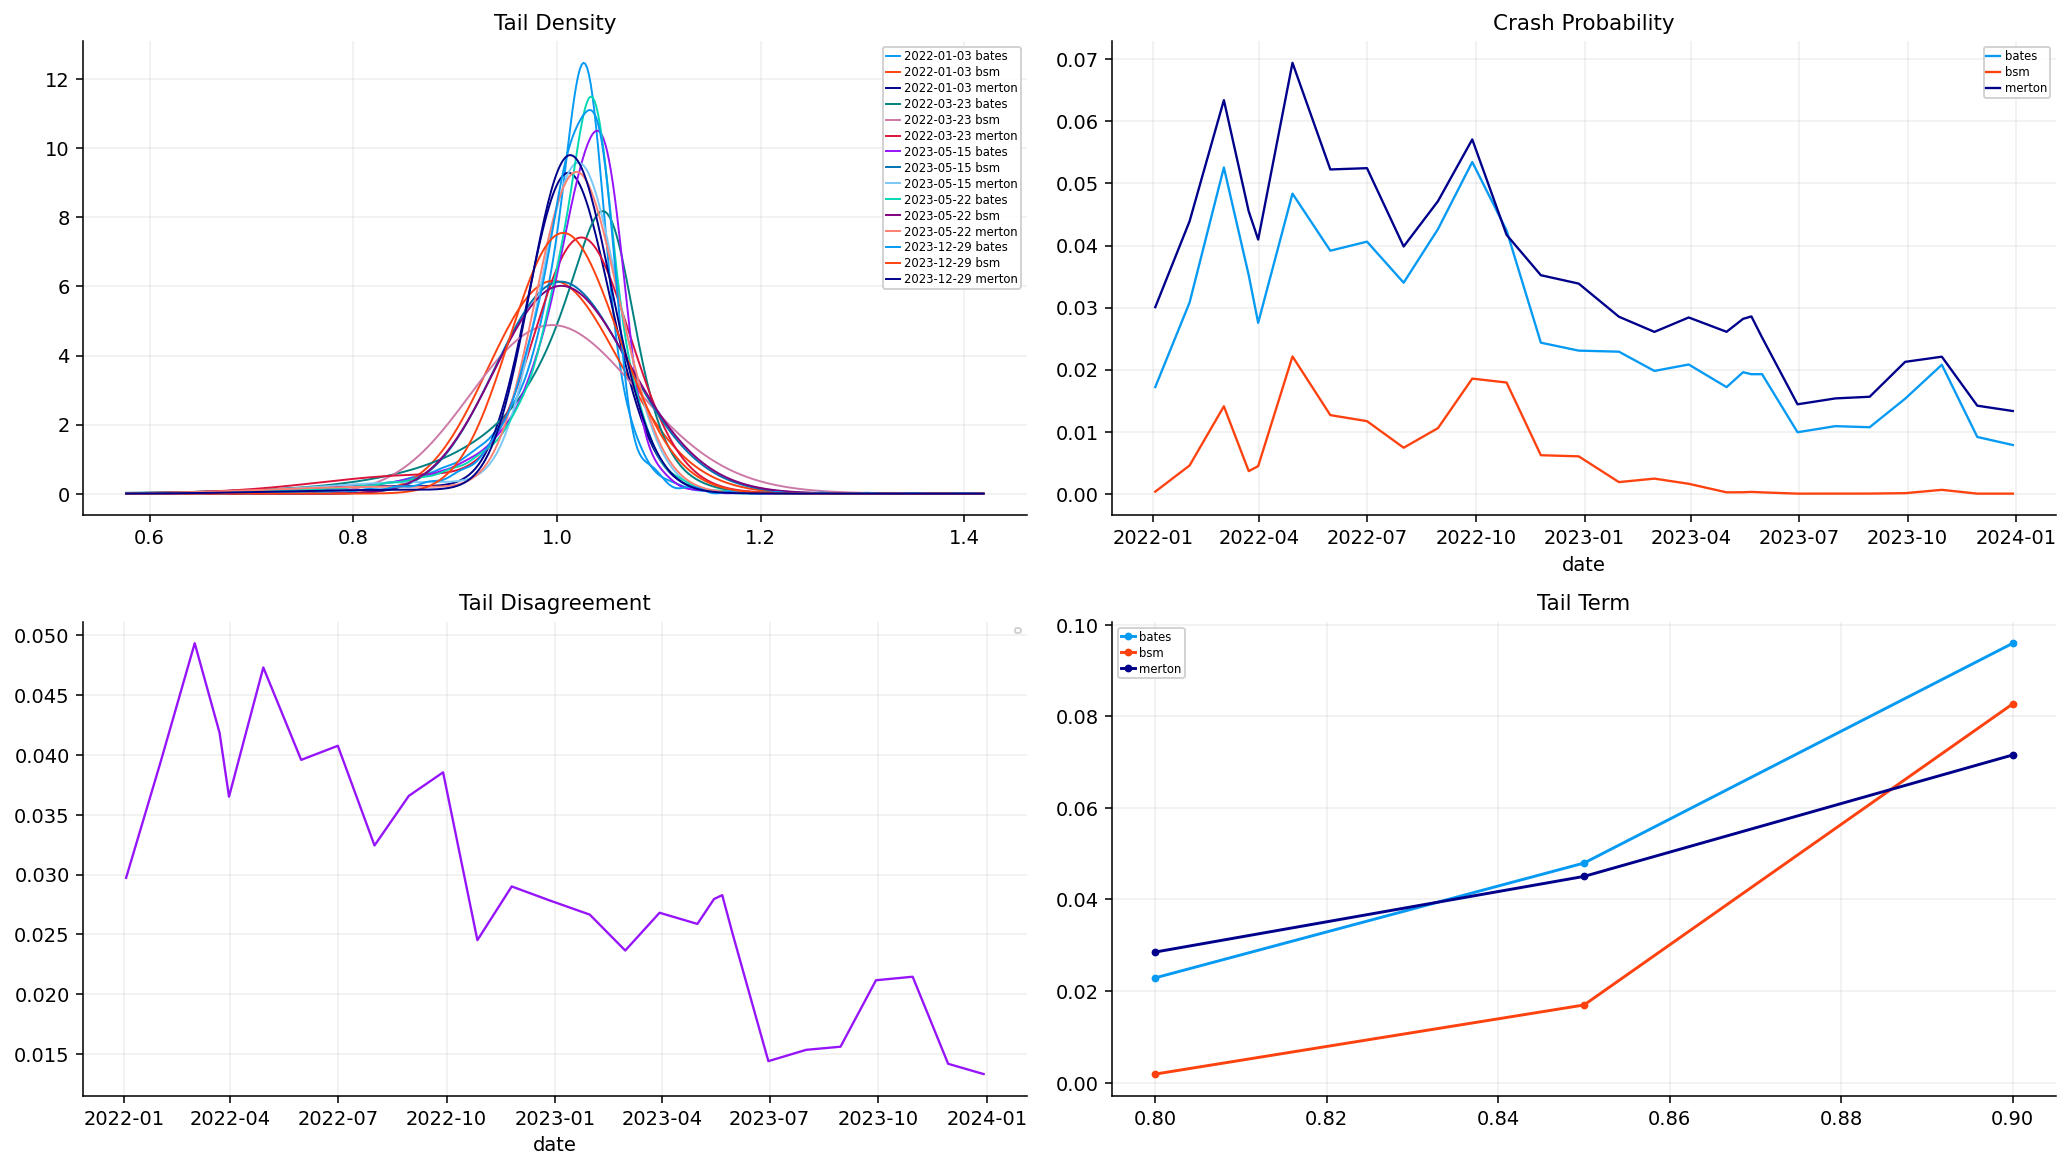

In [ ]:
tail80 = tail_diagnostics[tail_diagnostics["level"].eq(0.80)].copy()
tail_term_date = tail_dates[min(len(tail_dates) - 1, len(tail_dates) // 2)] if len(tail_dates) else main_day
fig, axes = plt.subplots(2, 2, figsize=(15, 8.5))
for i, ((date, model), g) in enumerate(density_summary.groupby(["date", "model"])):
    axes[0, 0].plot(g["s_over_s0"], g["density"], lw=1.0, color=palette[i % len(palette)], label=f"{pd.Timestamp(date).date()} {model}")
for i, (model, g) in enumerate(tail80.groupby("model")):
    axes[0, 1].plot(g["date"], g["tail_probability"], lw=1.2, color=palette[i], label=model)
pivot_tail = tail80.pivot_table(index="date", columns="model", values="tail_probability")
if not pivot_tail.empty:
    axes[1, 0].plot(pivot_tail.index, pivot_tail.max(axis=1) - pivot_tail.min(axis=1), color=palette[6], lw=1.2)
tail_term = tail_diagnostics[tail_diagnostics["date"].eq(pd.Timestamp(tail_term_date).normalize())]
for i, (model, g) in enumerate(tail_term.groupby("model")):
    axes[1, 1].plot(g["level"], g["tail_probability"], marker="o", ms=3, color=palette[i], label=model)
axes[0, 0].set_title("Tail Density")
axes[0, 1].set_title("Crash Probability")
axes[1, 0].set_title("Tail Disagreement")
axes[1, 1].set_title("Tail Term")
for ax in axes.ravel():
    ax.set_xlabel("date" if ax in [axes[0, 1], axes[1, 0]] else "")
    ax.legend(**legend_kw)
fig.tight_layout(pad=1.25, h_pad=1.0, w_pad=1.0)
plt.show()

The tail-density plot shows how the models allocate probability around the crash region. The crash-probability time series shows that tail risk is not constant. It rises during stress and falls as the market calms. The tail-disagreement panel is particularly useful because it measures model uncertainty: when the max-min gap is large, the models don't agree about crash probability.

The tail-term panel compares 90%, 85%, and 80% levels on a selected date. Moving from 90% to 80% is not just moving further left. It changes which model assumptions matter most. BSM can sometimes match moderate downside probability by raising volatility, but it often struggles with the far-left tail shape. Jump models can put more mass into deep crash states without raising all volatility equally.


## 15) Tail-Hedging Candidate Logic

The hedging section turns model prices and model-implied tail probabilities into option-selection rules. The universe is SPX puts with:

$$
21\le DTE\le 120
$$

$$
0.75\le \frac{K}{S}\le 0.98
$$

and relative spread below 30%. These are tail-hedge candidates: not tiny lottery tickets, not pure ATM hedges, but puts with enough convexity to matter in a downside move.

For each candidate, the project computes payoff at crash levels:

$$
\text{payoff}_{90}=\max(K-0.90S,0)
$$

$$
\text{payoff}_{85}=\max(K-0.85S,0)
$$

$$
\text{payoff}_{80}=\max(K-0.80S,0)
$$

Then it scales these by premium. A put that pays $50$ in a crash but costs $10$ has payoff-per-premium of 5. A put that pays $50$ but costs $2$ has payoff-per-premium of 25. Tail hedging is heavily about this convexity per dollar spent.


### 15.1 Expected Crash Efficiency

The expected crash-efficiency score combines crash probabilities and payoffs at several downside levels:

$$
ECE= p_{90}\frac{(K-0.90S)^+}{mid}+p_{85}\frac{(K-0.85S)^+}{mid}+p_{80}\frac{(K-0.80S)^+}{mid}
$$

where $p_{90}$, $p_{85}$, and $p_{80}$ are model-implied probabilities of crossing the corresponding downside levels.

This score rewards puts that deliver a lot of crash payoff per premium dollar. It also uses multiple crash levels instead of one. A put with strike near 0.90 may look good for a 10% drawdown but less convex for a 20% crash. A deeper put may look bad for a 10% drawdown but excellent for a 20% crash. Combining levels gives a smoother view of tail usefulness.

The score also subtracts premium bleed:

$$
\text{premium bleed}=\frac{mid/S}{\sqrt{DTE/365}}
$$

This penalizes options that are expensive relative to spot and short maturity. Short-dated puts can have high convexity, but they decay quickly. A hedge selector needs to pay attention to both payoff and cost.


The model-based edge is:

$$
\text{model edge}=\hat{V}^{model}-V^{mid}
$$

and the edge ratio is:

$$
\text{edge ratio}=\frac{\hat{V}^{model}-V^{mid}}{V^{mid}}
$$

A positive edge ratio means the model thinks the option is cheap relative to its fair value. The model-risk selector penalizes disagreement between jump and SV prices:

$$
\text{robust edge}=\frac{1}{2}(V^{jump}+V^{SV})-V^{mid}-\frac{1}{2}|V^{jump}-V^{SV}|
$$

This is a conservative rule. If both models agree the option is cheap, the robust edge is positive. If one model loves it and the other hates it, the disagreement penalty reduces the score.

The hedge score combines tail efficiency, model edge, convexity, spread cost, premium bleed, and model uncertainty:

$$
\text{score}=0.45\times \text{expected crash efficiency}+0.25\times \text{edge ratio}+0.15\times \text{convexity per premium}-0.10\times \text{spread}-0.10\times \text{premium bleed}-0.10\times \text{model uncertainty}+\text{target score}
$$

This makes the strategy more than a model-price sort. It asks whether the option is cheap, convex, liquid enough, and useful under crash scenarios.


In [ ]:
def latest_params(model, d):
    source = final_daily[final_daily["model"].eq(model)]
    source = source[source["date"].le(pd.Timestamp(d).normalize())].sort_values("date")
    if source.empty:
        return None
    return params_from_row(model, source.iloc[-1])

def latest_tail_values(model, d):
    source = tail_diagnostics[tail_diagnostics["model"].eq(model)]
    source = source[source["date"].le(pd.Timestamp(d).normalize())].sort_values("date")
    out = {0.90: 0.12, 0.85: 0.07, 0.80: 0.04}
    if source.empty:
        return out
    last_date = source["date"].iloc[-1]
    last = source[source["date"].eq(last_date)]
    for _, row in last.iterrows():
        out[float(row["level"])] = float(row["tail_probability"])
    return out

def tail_budget(model, d, edge_ratio=0.0, relative_spread=0.0, base_bps=35.0):
    source = tail_diagnostics[(tail_diagnostics["model"].eq(model)) & (tail_diagnostics["level"].eq(0.80))].sort_values("date")
    source = source[source["date"].le(pd.Timestamp(d).normalize())]
    if len(source) < 8:
        return base_bps
    hist = source["tail_probability"].tail(60)
    p = float(hist.iloc[-1])
    q70 = float(hist.quantile(0.70))
    q85 = float(hist.quantile(0.85))
    q95 = float(hist.quantile(0.95))
    edge = float(edge_ratio) if np.isfinite(edge_ratio) else 0.0
    spread = float(relative_spread) if np.isfinite(relative_spread) else 1.0
    add = 0.0
    if spread <= 0.30 and p > q70 and edge > -0.05:
        add += 25.0
    if spread <= 0.30 and p > q85 and edge > 0.0:
        add += 40.0
    if spread <= 0.30 and p > q95 and edge > 0.0:
        add += 60.0
    return min(base_bps + add, 120.0)

def hedge_candidates_for_date(q_by_date, d, selector, crash_level=0.85):
    gated = str(selector).endswith("_gated")
    base = str(selector).replace("_fixed", "").replace("_gated", "")
    day = q_by_date.get(pd.Timestamp(d).normalize())
    if day is None:
        return pd.DataFrame()
    day = day.copy()
    if day.empty:
        return day
    if base == "fixed_delta":
        day["model_price"] = day["mid"]
        day["model_edge"] = 0.0
        day["model_uncertainty"] = 0.0
        if "delta" in day.columns and day["delta"].notna().any():
            day["target_score"] = -(day["delta"].abs() - 0.25).abs() - 0.15 * day["relative_spread"]
        else:
            day["target_score"] = -(day["moneyness"] - 0.88).abs() - 0.15 * day["relative_spread"]
        tail = latest_tail_values(best_sv, d)
    else:
        p_jump = latest_params(best_jump, d)
        p_sv = latest_params(best_sv, d)
        if p_jump is None or p_sv is None:
            return day.iloc[:0]
        day["jump_price"] = price_with_cos(best_jump, p_jump, day, n_terms=128, width=30.0 if best_jump == "vg" else 14.0)
        day["sv_price"] = price_with_cos(best_sv, p_sv, day, n_terms=128, width=14.0)
        if base == best_jump:
            day["model_price"] = day["jump_price"]
            tail = latest_tail_values(best_jump, d)
        elif base == best_sv:
            day["model_price"] = day["sv_price"]
            tail = latest_tail_values(best_sv, d)
        else:
            day["model_price"] = 0.5 * (day["jump_price"] + day["sv_price"])
            tail = latest_tail_values(best_sv, d)
        robust_penalty = 0.5 * (day.get("jump_price", day["model_price"]) - day.get("sv_price", day["model_price"])).abs()
        day["model_edge"] = day["model_price"] - day["mid"] - np.where(base == "model_risk", robust_penalty, 0.0)
        day["model_uncertainty"] = (day["jump_price"] - day["sv_price"]).abs() / day["spot"]
        day["calibration_penalty"] = 0.0
        day["target_score"] = 0.0
        if base == "model_risk":
            day = day[day["moneyness"].le(0.93)].copy()
            if day.empty:
                return day
    spot_v = day["spot"].clip(lower=1e-8)
    mid = day["mid"].clip(lower=1e-8)
    day["payoff_at_90"] = np.maximum(day["strike"] - 0.90 * spot_v, 0.0)
    day["payoff_at_85"] = np.maximum(day["strike"] - 0.85 * spot_v, 0.0)
    day["payoff_at_80"] = np.maximum(day["strike"] - 0.80 * spot_v, 0.0)
    day["p90"] = tail[0.90]
    day["p85"] = tail[0.85]
    day["p80"] = tail[0.80]
    day["payoff_per_premium"] = np.maximum(day["strike"] - crash_level * spot_v, 0.0) / mid
    day["expected_crash_efficiency"] = day["p90"] * day["payoff_at_90"] / mid + day["p85"] * day["payoff_at_85"] / mid + day["p80"] * day["payoff_at_80"] / mid
    day["edge_ratio"] = day["model_edge"] / mid
    day["convexity_per_premium"] = (day["payoff_at_80"] - day["payoff_at_90"]).clip(lower=0.0) / (0.10 * spot_v * mid)
    day["premium_bleed"] = mid / spot_v / np.sqrt(day["dte_days"] / ann_days)
    if "calibration_penalty" not in day.columns:
        day["calibration_penalty"] = 0.0
    if gated:
        budget_model = best_sv if base in {"fixed_delta", "model_risk"} else base
        day["budget_bps"] = [
            tail_budget(budget_model, d, edge_ratio=e, relative_spread=sp)
            for e, sp in zip(day["edge_ratio"].to_numpy(float), day["relative_spread"].to_numpy(float))
        ]
    else:
        day["budget_bps"] = 35.0
    day["hedge_score"] = (
        0.45 * day["expected_crash_efficiency"]
        + 0.25 * day["edge_ratio"]
        + 0.15 * day["convexity_per_premium"]
        - 0.10 * day["relative_spread"]
        - 0.10 * day["premium_bleed"]
        - 0.10 * day["model_uncertainty"]
        + day["target_score"]
    )
    day["selector"] = selector
    return day.sort_values("hedge_score", ascending=False)

In [ ]:
def build_hedge_schedule(q, selectors, dates, notional=1_000_000.0, budget_bps=35.0, multiplier=100.0, spacing_days=21):
    rows = []
    candidates = []
    last = {name: None for name in selectors}
    q_by_date = {d: g for d, g in q.groupby("date", sort=False)}
    for d in dates:
        for selector in selectors:
            if last[selector] is not None and (pd.Timestamp(d) - last[selector]).days < spacing_days:
                continue
            cand = hedge_candidates_for_date(q_by_date, d, selector)
            if cand.empty:
                continue
            chosen = cand.iloc[0].copy()
            price = float(chosen["ask"])
            budget = notional * float(chosen.get("budget_bps", budget_bps)) / 10000.0
            qty = budget / max(price * multiplier, 1e-8)
            rows.append({"strategy": selector, "entry_date": pd.Timestamp(d).normalize(), "contract_key": chosen["contract_key"], "expiry": pd.Timestamp(chosen.expiry).normalize(), "strike": float(chosen.strike), "option_type": str(chosen.option_type), "quantity": qty, "label": "tail_put", "premium_budget": budget, "premium_budget_bps": float(chosen.get("budget_bps", budget_bps))})
            candidates.append(chosen)
            last[selector] = pd.Timestamp(d).normalize()
    cands = pd.DataFrame(candidates)
    sched = pd.DataFrame(rows)
    return cands, sched

hedge_cols = ["date", "expiry", "option_type", "strike", "spot", "bid", "ask", "mid", "tau", "dte_days", "moneyness", "log_moneyness", "relative_spread", "rate", "dividend_yield", "delta"]
hedge_mask = clean_quotes["option_type"].astype(str).str.lower().str.startswith("p") & clean_quotes["dte_days"].between(21, 120) & clean_quotes["moneyness"].between(0.75, 0.98) & clean_quotes["relative_spread"].le(0.30)
hedge_quotes = clean_quotes.loc[hedge_mask, [c for c in hedge_cols if c in clean_quotes.columns]].copy()
hedge_quotes["contract_key"] = hedge_quotes["option_type"].astype(str) + "_" + hedge_quotes["expiry"].dt.strftime("%Y-%m-%d") + "_" + hedge_quotes["strike"].map(lambda x: f"{float(x):.6f}".rstrip("0").rstrip("."))
rebalance_dates = pd.DatetimeIndex(sorted(clean_quotes["date"].drop_duplicates()))[::21]
selectors = ["fixed_delta_fixed", f"{best_jump}_fixed", f"{best_jump}_gated", f"{best_sv}_fixed", f"{best_sv}_gated", "model_risk_fixed", "model_risk_gated"]
hedge_candidates, hedge_schedule = build_hedge_schedule(hedge_quotes, selectors, rebalance_dates, notional=1_000_000.0, budget_bps=35.0, multiplier=100.0, spacing_days=21)
display(hedge_schedule.groupby("strategy").size().rename("scheduled_trades").reset_index())
display(hedge_candidates.groupby("selector").agg(avg_score=("hedge_score", "mean"), avg_moneyness=("moneyness", "mean"), avg_dte=("dte_days", "mean"), avg_mid=("mid", "mean"), avg_budget_bps=("budget_bps", "mean"), avg_payoff_per_premium=("payoff_per_premium", "mean"), avg_edge_ratio=("edge_ratio", "mean")).reset_index().round(5))

,strategy,scheduled_trades
0,bates_fixed,25
1,bates_gated,25
2,fixed_delta_fixed,25
3,merton_fixed,25
4,merton_gated,25
5,model_risk_fixed,25
6,model_risk_gated,25


,selector,avg_score,avg_moneyness,avg_dte,avg_mid,avg_budget_bps,avg_payoff_per_premium,avg_edge_ratio
0,bates_fixed,1.775470,0.910190,21.933330,9.975000,35.000000,45.980840,0.021530
1,bates_gated,1.775470,0.910190,21.933330,9.975000,40.400000,45.980840,0.021530
2,fixed_delta_fixed,1.586440,0.912150,21.933330,10.952000,35.000000,45.619480,0.000000
3,merton_fixed,2.370680,0.892290,21.933330,7.197000,35.000000,45.598240,1.289080
4,merton_gated,2.370680,0.892290,21.933330,7.197000,37.000000,45.598240,1.289080
5,model_risk_fixed,1.772490,0.909360,21.933330,9.475000,35.000000,45.993790,0.014640
6,model_risk_gated,1.772490,0.909360,21.933330,9.475000,38.000000,45.993790,0.014640


The hedge schedule creates **25 scheduled trades** for each selector. The average candidate table shows the character of each strategy.

Merton selectors choose lower-moneyness puts on average, around **0.892**, with lower average mid prices around **7.20** and very high average edge ratios around **1.29**. Bates and model-risk selectors choose moneyness around **0.91**, with higher average premiums and lower model edge. Fixed delta sits close to the same region but has zero model edge by construction because it uses the market price as fair value.

The gated versions raise average budget in some cases. For example, Bates gated averages about **40.4 bps** versus 35 bps fixed, while Merton gated averages about **37 bps**. The gate spends more when tail probabilities are high, spreads are acceptable, and edge is not negative.


In [ ]:
from quantfinlab.backtest.overlays import run_overlay_backtest, overlay_summary, mark_book_for_schedules

spx_underlying = spot["close"].reindex(pd.DatetimeIndex(sorted(clean_quotes["date"].unique()))).ffill()
schedules = {}
for name, group in hedge_schedule.groupby("strategy"):
    schedules[name] = group[["entry_date", "contract_key", "expiry", "strike", "option_type", "quantity", "label"]].copy()
selected_contracts = hedge_schedule[["expiry", "strike", "option_type"]].drop_duplicates().copy()
selected_contracts["expiry"] = pd.to_datetime(selected_contracts["expiry"], errors="coerce").dt.normalize()
mark_cols = ["date", "expiry", "option_type", "strike", "spot", "bid", "ask", "mid", "dte_days", "moneyness"]
mark_mask = clean_quotes["expiry"].isin(selected_contracts["expiry"].unique()) & clean_quotes["strike"].isin(selected_contracts["strike"].unique()) & clean_quotes["option_type"].astype(str).isin(selected_contracts["option_type"].astype(str).unique())
hedge_book = clean_quotes.loc[mark_mask, [c for c in mark_cols if c in clean_quotes.columns]].merge(selected_contracts, on=["expiry", "strike", "option_type"], how="inner")
hedge_book["contract_key"] = hedge_book["option_type"].astype(str) + "_" + hedge_book["expiry"].dt.strftime("%Y-%m-%d") + "_" + hedge_book["strike"].map(lambda x: f"{float(x):.6f}".rstrip("0").rstrip("."))
shares = 1_000_000.0 / float(spx_underlying.dropna().iloc[0])
hedge_nav_path = cache_dir / "spx_hedge_nav.parquet"
hedge_trades_path = cache_dir / "spx_hedge_trades.parquet"
hedge_settings = {"version": 7, "selectors": selectors, "schedule_rows": int(len(hedge_schedule)), "mark_rows": int(len(hedge_book)), "base_budget_bps": 35.0, "tail_gated_budget": "price_aware", "risk_penalty": 0.0, "risk_moneyness_max": 0.93, "spacing_days": 21}
if hedge_nav_path.exists() and hedge_trades_path.exists() and same_settings(hedge_nav_path, hedge_settings):
    hedge_nav = pd.read_parquet(hedge_nav_path).set_index("date")
    hedge_nav.index = pd.to_datetime(hedge_nav.index, errors="coerce").normalize()
    hedge_trades = pd.read_parquet(hedge_trades_path)
    hedge_drawdown = hedge_nav / hedge_nav.cummax() - 1.0
    hedge_results = {"nav": hedge_nav, "drawdown": hedge_drawdown, "trades": hedge_trades, "cash": pd.DataFrame(index=hedge_nav.index), "option_marks": pd.DataFrame(index=hedge_nav.index), "holdings": pd.DataFrame(index=hedge_nav.index), "call_holdings": pd.DataFrame(index=hedge_nav.index), "put_holdings": pd.DataFrame(index=hedge_nav.index)}
else:
    hedge_results = run_overlay_backtest(schedules, hedge_book, spx_underlying, initial_nav=1_000_000.0, contract_multiplier=100.0, shares=shares)
    hedge_results["nav"].reset_index(names="date").to_parquet(hedge_nav_path, index=False)
    hedge_results["trades"].to_parquet(hedge_trades_path, index=False)
    write_meta(hedge_nav_path, hedge_settings, len(hedge_results["nav"]))
hedge_summary = overlay_summary(hedge_results)
hedge_trades = hedge_results["trades"].copy()
display(pd.DataFrame([{"candidate_rows": len(hedge_quotes), "scheduled_trades": len(hedge_schedule), "mark_rows": len(hedge_book), "selected_contracts": selected_contracts.shape[0]}]))
display(hedge_summary.round(6))
if hedge_trades.empty or not {"strategy", "event"}.issubset(hedge_trades.columns):
    display(pd.DataFrame(columns=["strategy", "open", "roll_close", "expiry_settlement"]))
else:
    display(hedge_trades.groupby(["strategy", "event"]).size().unstack(fill_value=0))

,candidate_rows,scheduled_trades,mark_rows,selected_contracts
0,674228,175,1171,57


,strategy,final_nav,total_pnl,total_return,annualized_return,max_drawdown,downside_deviation,worst_month,best_month,trades,roll_closes,assignment_defense_closes,expiry_settlements,net_open_premium_cashflow,spread_cost,ann_vol
0,bates_fixed,"937,990.033639","-62,009.966361",-0.062010,-0.031440,-0.258556,0.124069,-0.094314,0.091251,49,0,0,24,"-87,500.000000","1,871.067066",0.187743
1,bates_gated,"924,490.033639","-75,509.966361",-0.075510,-0.038421,-0.264695,0.124224,-0.089993,0.092771,49,0,0,24,"-101,000.000000","2,026.312600",0.187988
2,fixed_delta_fixed,"946,982.622612","-53,017.377388",-0.053017,-0.026817,-0.249466,0.122876,-0.093273,0.090265,49,0,0,24,"-87,500.000000","1,804.352878",0.186318
3,merton_fixed,"920,958.646813","-79,041.353187",-0.079041,-0.040256,-0.277014,0.126753,-0.096477,0.093120,49,0,0,24,"-87,500.000000","2,065.272423",0.191977
4,merton_gated,"915,958.646813","-84,041.353187",-0.084041,-0.042860,-0.280875,0.126762,-0.094715,0.093701,49,0,0,24,"-92,500.000000","2,191.808783",0.192188
5,model_risk_fixed,"937,990.033639","-62,009.966361",-0.062010,-0.031440,-0.258675,0.124179,-0.094314,0.091251,49,0,0,24,"-87,500.000000","1,907.194565",0.187859
6,model_risk_gated,"930,490.033639","-69,509.966361",-0.069510,-0.035312,-0.264096,0.124158,-0.095232,0.092089,49,0,0,24,"-95,000.000000","2,015.448503",0.188160


event,expiry_settlement,open
strategy,,
bates_fixed,24,25
bates_gated,24,25
fixed_delta_fixed,24,25
merton_fixed,24,25
merton_gated,24,25
model_risk_fixed,24,25
model_risk_gated,24,25


The overlay backtest compares the hedged portfolio to an unhedged SPX holding. Each hedge strategy buys puts periodically using a premium budget. The mark-to-market book tracks option values, rolls, and cashflows.

The summary is honest: over this sample, the unhedged portfolio ends with the highest final NAV, about **1.434M**, while the hedged strategies end around **1.415M to 1.419M**. The hedges spend premium, and the sample doesn't contain a crash large enough for the puts to dominate the cost.

Max drawdowns are also slightly worse for the hedged versions in this run, around **-26.4% to -26.6%**, compared with about **-26.2%** for unhedged. That can happen when hedges are repeatedly bought during volatile markets but expire or are rolled before a sufficiently large payoff occurs.

This doesn't invalidate the modeling. It shows that tail hedging is a cost-benefit problem. A model can identify convex protection, but if the realized path doesn't include the tail event, premium bleed can dominate.


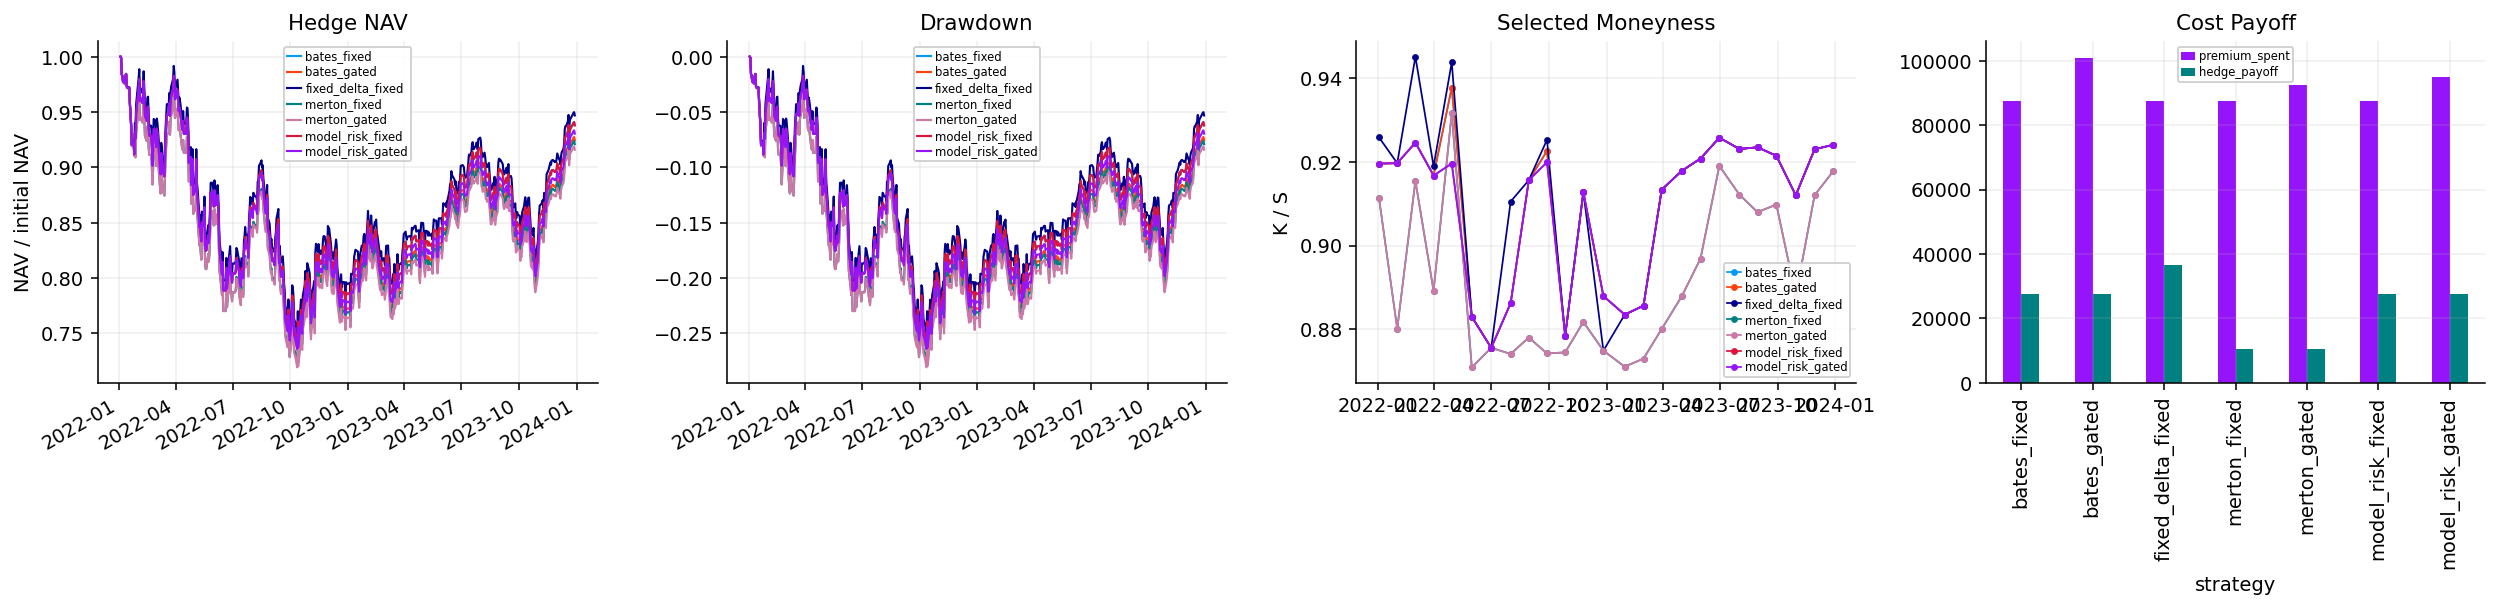

In [ ]:
fig, axes = plt.subplots(1, 4, figsize=(18, 4.5))
hedge_results["nav"].div(hedge_results["nav"].iloc[0]).plot(ax=axes[0], lw=1.1)
axes[0].set_title("Hedge NAV")
axes[0].set_ylabel("NAV / initial NAV")
axes[0].legend(**legend_kw)
hedge_results["drawdown"].plot(ax=axes[1], lw=1.1)
axes[1].set_title("Drawdown")
axes[1].legend(**legend_kw)
for i, (name, g) in enumerate(hedge_candidates.groupby("selector")):
    axes[2].plot(pd.to_datetime(g["date"]), g["moneyness"], marker="o", ms=2.5, lw=0.9, color=palette[i], label=name)
axes[2].set_ylabel("K / S")
axes[2].set_title("Selected Moneyness")
axes[2].legend(**legend_kw)
cash = hedge_trades.copy()
cash["premium_spent"] = np.where(cash["event"].eq("open"), -cash["cashflow"], 0.0)
cash["hedge_payoff"] = np.where(cash["event"].isin(["expiry_settlement", "roll_close"]), cash["cashflow"], 0.0)
cash.groupby("strategy")[["premium_spent", "hedge_payoff"]].sum().plot(kind="bar", ax=axes[3], color=[palette[6], palette[3]])
axes[3].set_title("Cost Payoff")
axes[3].legend(**legend_kw)
fig.tight_layout(pad=1.25, h_pad=1.0, w_pad=1.0)
plt.show()

The hedge NAV and drawdown plots reinforce the table. The hedged paths stay close to the unhedged path, with small differences driven by option premium, mark-to-market changes, and occasional tail payoff. The hedge cashflow panel shows the repeated cost of protection.

The key interpretation is that model sophistication doesn't guarantee better realized performance over a short sample. Tail hedges are insurance. Insurance can be correctly priced and still reduce return when the insured event doesn't happen. The useful comparison here is across selectors: which ones spend more, pick cheaper convexity, rely more on model edge, or respond more strongly to tail probability regimes.


### Why Tail Hedges Can Lose Even When the Tail Model Is Better

A tail hedge has negative carry. If we buy puts repeatedly, the expected cashflow over calm periods is usually negative because option sellers demand compensation for convexity and crash risk.

Let the premium paid at entry be $P_0$ and the future payoff be $H_T$. The realized hedge P&L is:

$$
\Pi=H_T-P_0
$$

The model may estimate:

$$
E^Q[H_T]>P_0
$$

for some candidates, but realized physical outcomes can still be calm. Also, $Q$ is not the same as the physical measure $P$. Risk-neutral tail probabilities include risk premium. Buying options at market prices means buying that risk premium too.

So the overlay result has to be interpreted as an insurance backtest, not a pure alpha backtest. The model can help choose better insurance contracts, but if the insured event doesn't happen, the strategy can lag unhedged exposure. That is what we see in both SPX and BTC samples.


,selector,edge,payoff,uncertainty,spread
0,bates_fixed,0.014040,41.407690,0.001310,0.042550
1,bates_gated,0.014040,41.407690,0.001310,0.042550
2,fixed_delta_fixed,0.000000,39.274020,0.000000,0.041960
3,merton_fixed,1.380390,36.842790,0.001360,0.046510
4,merton_gated,1.380390,36.842790,0.001360,0.046510
5,model_risk_fixed,0.014040,41.407690,0.001150,0.042550
6,model_risk_gated,0.014040,41.407690,0.001150,0.042550


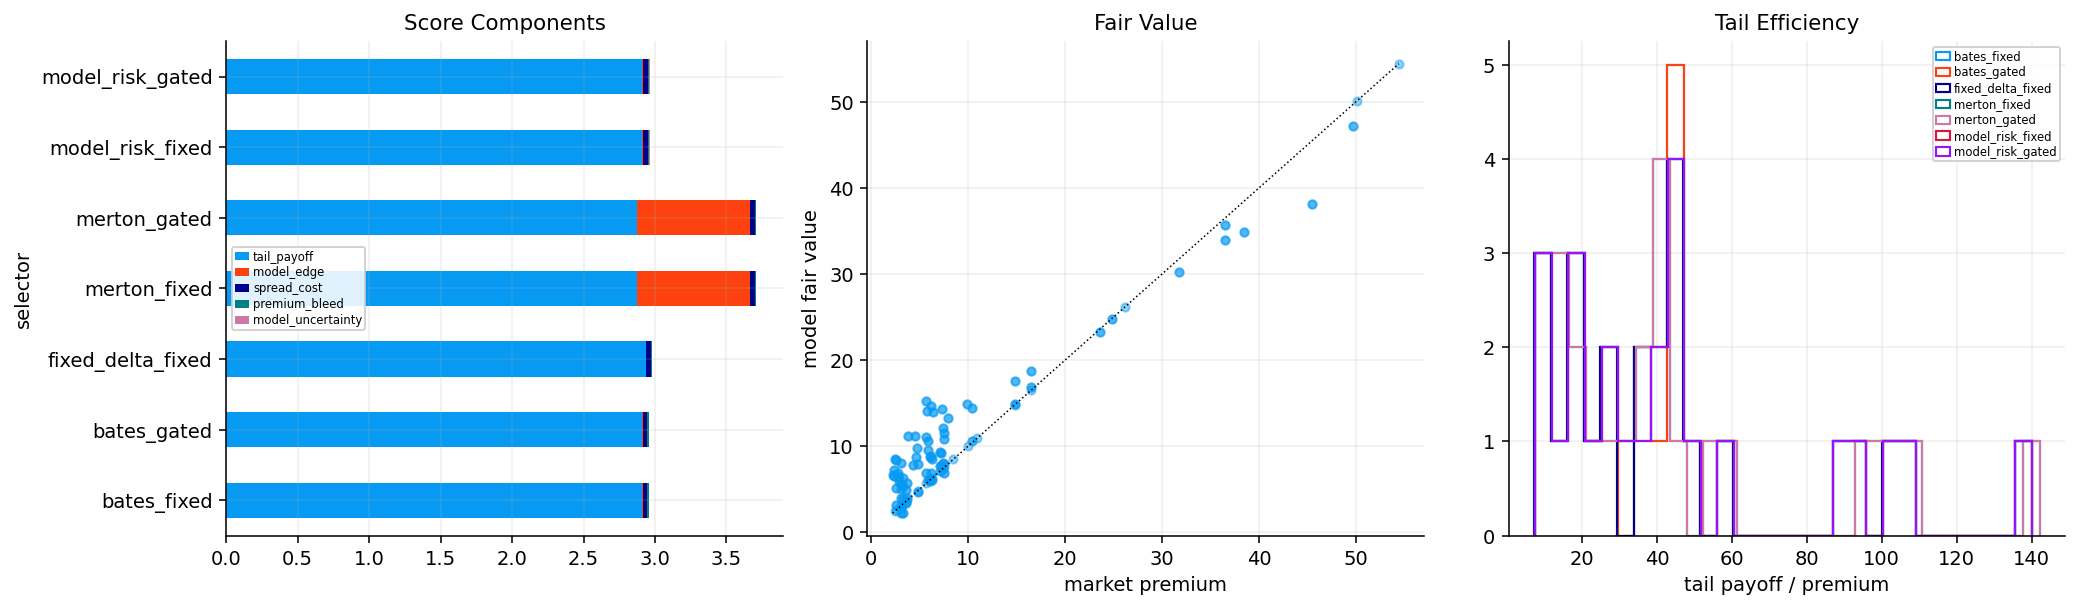

In [ ]:
component_rows = []
for _, row in hedge_candidates.iloc[:80].iterrows():
    component_rows.append({"selector": row["selector"], "date": row["date"], "tail_payoff": np.log1p(row["payoff_per_premium"]), "model_edge": np.tanh(row["edge_ratio"]), "spread_cost": row["relative_spread"], "premium_bleed": row["premium_bleed"], "model_uncertainty": row["model_uncertainty"]})
hedge_components = pd.DataFrame(component_rows)
edge_table = hedge_candidates.groupby("selector").agg(edge=("edge_ratio", "median"), payoff=("payoff_per_premium", "median"), uncertainty=("model_uncertainty", "median"), spread=("relative_spread", "median")).reset_index()
display(edge_table.round(5))
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
comp = hedge_components.groupby("selector")[["tail_payoff", "model_edge", "spread_cost", "premium_bleed", "model_uncertainty"]].median()
comp.plot(kind="barh", stacked=True, ax=axes[0], color=palette[:5])
axes[0].set_title("Score Components")
axes[0].legend(**legend_kw)
axes[1].scatter(hedge_candidates["mid"], hedge_candidates.get("model_price", hedge_candidates["mid"]), s=18, alpha=0.45, color=palette[0])
lo = min(hedge_candidates["mid"].min(), hedge_candidates.get("model_price", hedge_candidates["mid"]).min())
hi = max(hedge_candidates["mid"].max(), hedge_candidates.get("model_price", hedge_candidates["mid"]).max())
axes[1].plot([lo, hi], [lo, hi], color="black", lw=0.8, ls=":")
axes[1].set_xlabel("market premium")
axes[1].set_ylabel("model fair value")
axes[1].set_title("Fair Value")
for i, (name, g) in enumerate(hedge_candidates.groupby("selector")):
    axes[2].hist(g["payoff_per_premium"], bins=30, histtype="step", lw=1.1, color=palette[i], label=name)
axes[2].set_xlabel("tail payoff / premium")
axes[2].set_title("Tail Efficiency")
axes[2].legend(**legend_kw)
fig.tight_layout(pad=1.25, h_pad=1.0, w_pad=1.0)
plt.show()

The hedge score-component table and plots show what the selectors are actually doing. The model-based selectors have higher edge scores, while fixed-delta selection relies more on simple target exposure. The fair-value scatter checks whether model prices are systematically above or below market premiums. The tail-efficiency histogram shows how much crash payoff per premium each selector tends to buy.

This is a good diagnostic layer because final NAV alone can be misleading. A hedge may underperform because no crash happened, while still selecting more efficient protection. The score components separate selection quality from realized path luck.


In [ ]:
project_objects = {
    "clean_quotes": clean_quotes,
    "calibration_quotes": calibration_quotes,
    "direct_validation": direct_validation,
    "fft_validation_table": fft_validation_table,
    "cos_validation_table": cos_validation_table,
    "jump_daily_fits": jump_daily_fits,
    "sv_daily_fits": sv_daily_fits,
    "common_dates": pd.Index(common_dates),
    "final_model_comparison": final_model_comparison,
    "residual_smile": residual_smile,
    "tail_diagnostics": tail_diagnostics,
    "hedge_candidates": hedge_candidates,
    "hedge_schedule": hedge_schedule,
    "hedge_trades": hedge_trades,
    "hedge_summary": hedge_summary,
}
object_summary = pd.DataFrame([{"name": k, "type": type(v).__name__, "rows": len(v) if hasattr(v, "__len__") and not isinstance(v, dict) else np.nan} for k, v in project_objects.items()])
display(object_summary)

,name,type,rows
0,clean_quotes,DataFrame,4164745
1,calibration_quotes,DataFrame,85850
2,direct_validation,DataFrame,3000
3,fft_validation_table,DataFrame,10
4,cos_validation_table,DataFrame,25
5,jump_daily_fits,DataFrame,1010
6,sv_daily_fits,DataFrame,1010
7,common_dates,DatetimeIndex,505
8,final_model_comparison,DataFrame,3
9,residual_smile,DataFrame,30


The object summary confirms the main artifacts created by the project: over **4.16 million** cleaned SPX quotes, **85,850** calibration quotes, direct/FFT/COS validation tables, jump and SV daily fits, residual diagnostics, tail diagnostics, hedge candidates, hedge schedules, hedge trades, and hedge summary.

This matters because the project isn't only a pricing demonstration. It builds a full Fourier option-pricing workflow:

1. clean real quotes,
2. create representative calibration grids,
3. validate pricing engines,
4. fit models daily,
5. diagnose residuals and tails,
6. translate model outputs into an overlay strategy.


## 16) BTC Secondary Application

The BTC section repeats the production workflow through the library. The data comes from the exact BTC folders listed at the start:

- [btc_options_chain](https://github.com/ramtin-asadi/Quantitative-Finance-Lab/tree/main/data/btc_options_chain)
- [btc_usd_ohlcv](https://github.com/ramtin-asadi/Quantitative-Finance-Lab/tree/main/data/btc_usd_ohlcv)

This market is structurally different from SPX options. BTC has much higher volatility, more extreme jumps, a 24/7 underlying market, different liquidity patterns, and a quote universe that can be thinner across some expiries/strikes. The project converts quotes to USD-equivalent terms, assigns a simple rate assumption, and builds a calibration grid similar in spirit to the SPX grid.


### 16.1 Why Fourier Methods Transfer Well to BTC

BTC is a useful secondary application because it stresses the same models differently. The underlying is much more volatile, option prices are much larger in absolute terms, and tails are more important. But the Fourier machinery barely changes.

The model still supplies:

$$
\phi_T(u;\theta)
$$

The pricing engine still computes prices through FFT or COS. The calibration still minimizes spread-scaled residuals. The tail module still integrates model-implied densities.

What changes is the economic interpretation of parameters and residuals. A high volatility level in SPX may represent crisis conditions. A high volatility level in BTC can be normal. A 20% downside event in SPX is a major crash. A 20% BTC move can happen in a much shorter window. This means the same tail levels $0.90$, $0.85$, and $0.80$ are less extreme for BTC than for SPX.

That is why BTC hedges can be expensive and still not dominate realized performance. The market already prices high movement probability. Buying puts in a high-volatility market means paying for convexity that many traders already know is valuable.


,btc_rows,calibration_rows,calibration_dates,avg_quotes_per_date,jump_winner,sv_winner
0,96695,26958,269,100.215600,merton,heston


,step,rows,removed
0,clean quotes,96695,0
1,finite market fields,96695,0
2,DTE window,90127,6568
3,log-moneyness window,84044,6083
4,spread window,84044,0
5,OTM side by strike,44863,39181
6,expiry support,44856,7
7,date support,44838,18
8,daily grid,26958,17880


,model,dates,quotes,success_rate,weighted_price_rmse,median_abs_price_error,weighted_iv_rmse,bid_ask_hit_rate,otm_put_rmse,short_maturity_rmse,runtime_sec
0,heston,90,9037,0.888889,"219,721.689531",50.921645,16.884578,0.313979,"156,043.887820","135,635.307901",132.746129
1,merton,269,26958,0.933086,"326,547.990085",80.954874,13.732222,0.212765,"269,626.583733","263,267.495891",113.790403
2,bsm,269,26958,1.000000,"547,644.803277",133.812161,17.356554,0.122437,"404,110.922422","478,264.446398",14.837551


,strategy,open_trades,max_quantity,median_quantity,median_open_price,premium_spent,median_moneyness,median_dte,mark_rows
0,fixed_delta_35bps,13,2.314300,1.438800,"2,432.650500","45,500.000000",0.874300,74.000000,2608
1,heston_35bps,13,2.622100,1.085900,"3,223.126100","45,500.000000",0.967700,32.000000,2608
2,heston_tail_gated,13,2.622100,1.085900,"3,223.126100","45,500.000000",0.967700,32.000000,2608
3,merton_35bps,13,2.053500,1.085900,"3,223.126100","45,500.000000",0.971700,32.000000,2608
4,merton_tail_gated,13,2.053500,1.258700,"3,223.126100","50,500.000000",0.971700,32.000000,2608
5,model_risk_35bps,13,3.408700,1.712700,"2,043.599100","45,500.000000",0.922300,32.000000,2608
6,model_risk_tail_gated,13,3.408700,1.712700,"2,043.599100","45,500.000000",0.922300,32.000000,2608


,strategy,final_nav,total_pnl,total_return,annualized_return,max_drawdown,downside_deviation,worst_month,best_month,trades,roll_closes,assignment_defense_closes,expiry_settlements,net_open_premium_cashflow,spread_cost,ann_vol
0,fixed_delta_35bps,"1,419,424.616740","419,424.616740",0.419425,0.386665,-0.265315,0.278467,-0.151437,0.434222,25,12,0,0,"-45,500.000000",566.764603,0.457073
1,heston_35bps,"1,418,600.808647","418,600.808647",0.418601,0.385914,-0.264249,0.278509,-0.151540,0.434564,25,12,0,0,"-45,500.000000",497.453520,0.457584
2,heston_tail_gated,"1,418,600.808647","418,600.808647",0.418601,0.385914,-0.264249,0.278509,-0.151540,0.434564,25,12,0,0,"-45,500.000000",497.453520,0.457584
3,merton_35bps,"1,418,616.831764","418,616.831764",0.418617,0.385928,-0.264247,0.278507,-0.151538,0.434327,25,12,0,0,"-45,500.000000",485.776041,0.457585
4,merton_tail_gated,"1,415,628.473038","415,628.473038",0.415628,0.383203,-0.264808,0.278509,-0.152039,0.434327,25,12,0,0,"-50,500.000000",535.177097,0.457669
5,model_risk_35bps,"1,414,559.893114","414,559.893114",0.414560,0.382229,-0.266100,0.278450,-0.152081,0.435267,25,12,0,0,"-45,500.000000",752.587062,0.458046
6,model_risk_tail_gated,"1,414,559.893114","414,559.893114",0.414560,0.382229,-0.266100,0.278450,-0.152081,0.435267,25,12,0,0,"-45,500.000000",752.587062,0.458046
7,unhedged,"1,433,853.870892","433,853.870892",0.433854,0.399817,-0.261820,0.279144,-0.149954,0.437169,0,0,0,0,NaN,NaN,0.454900


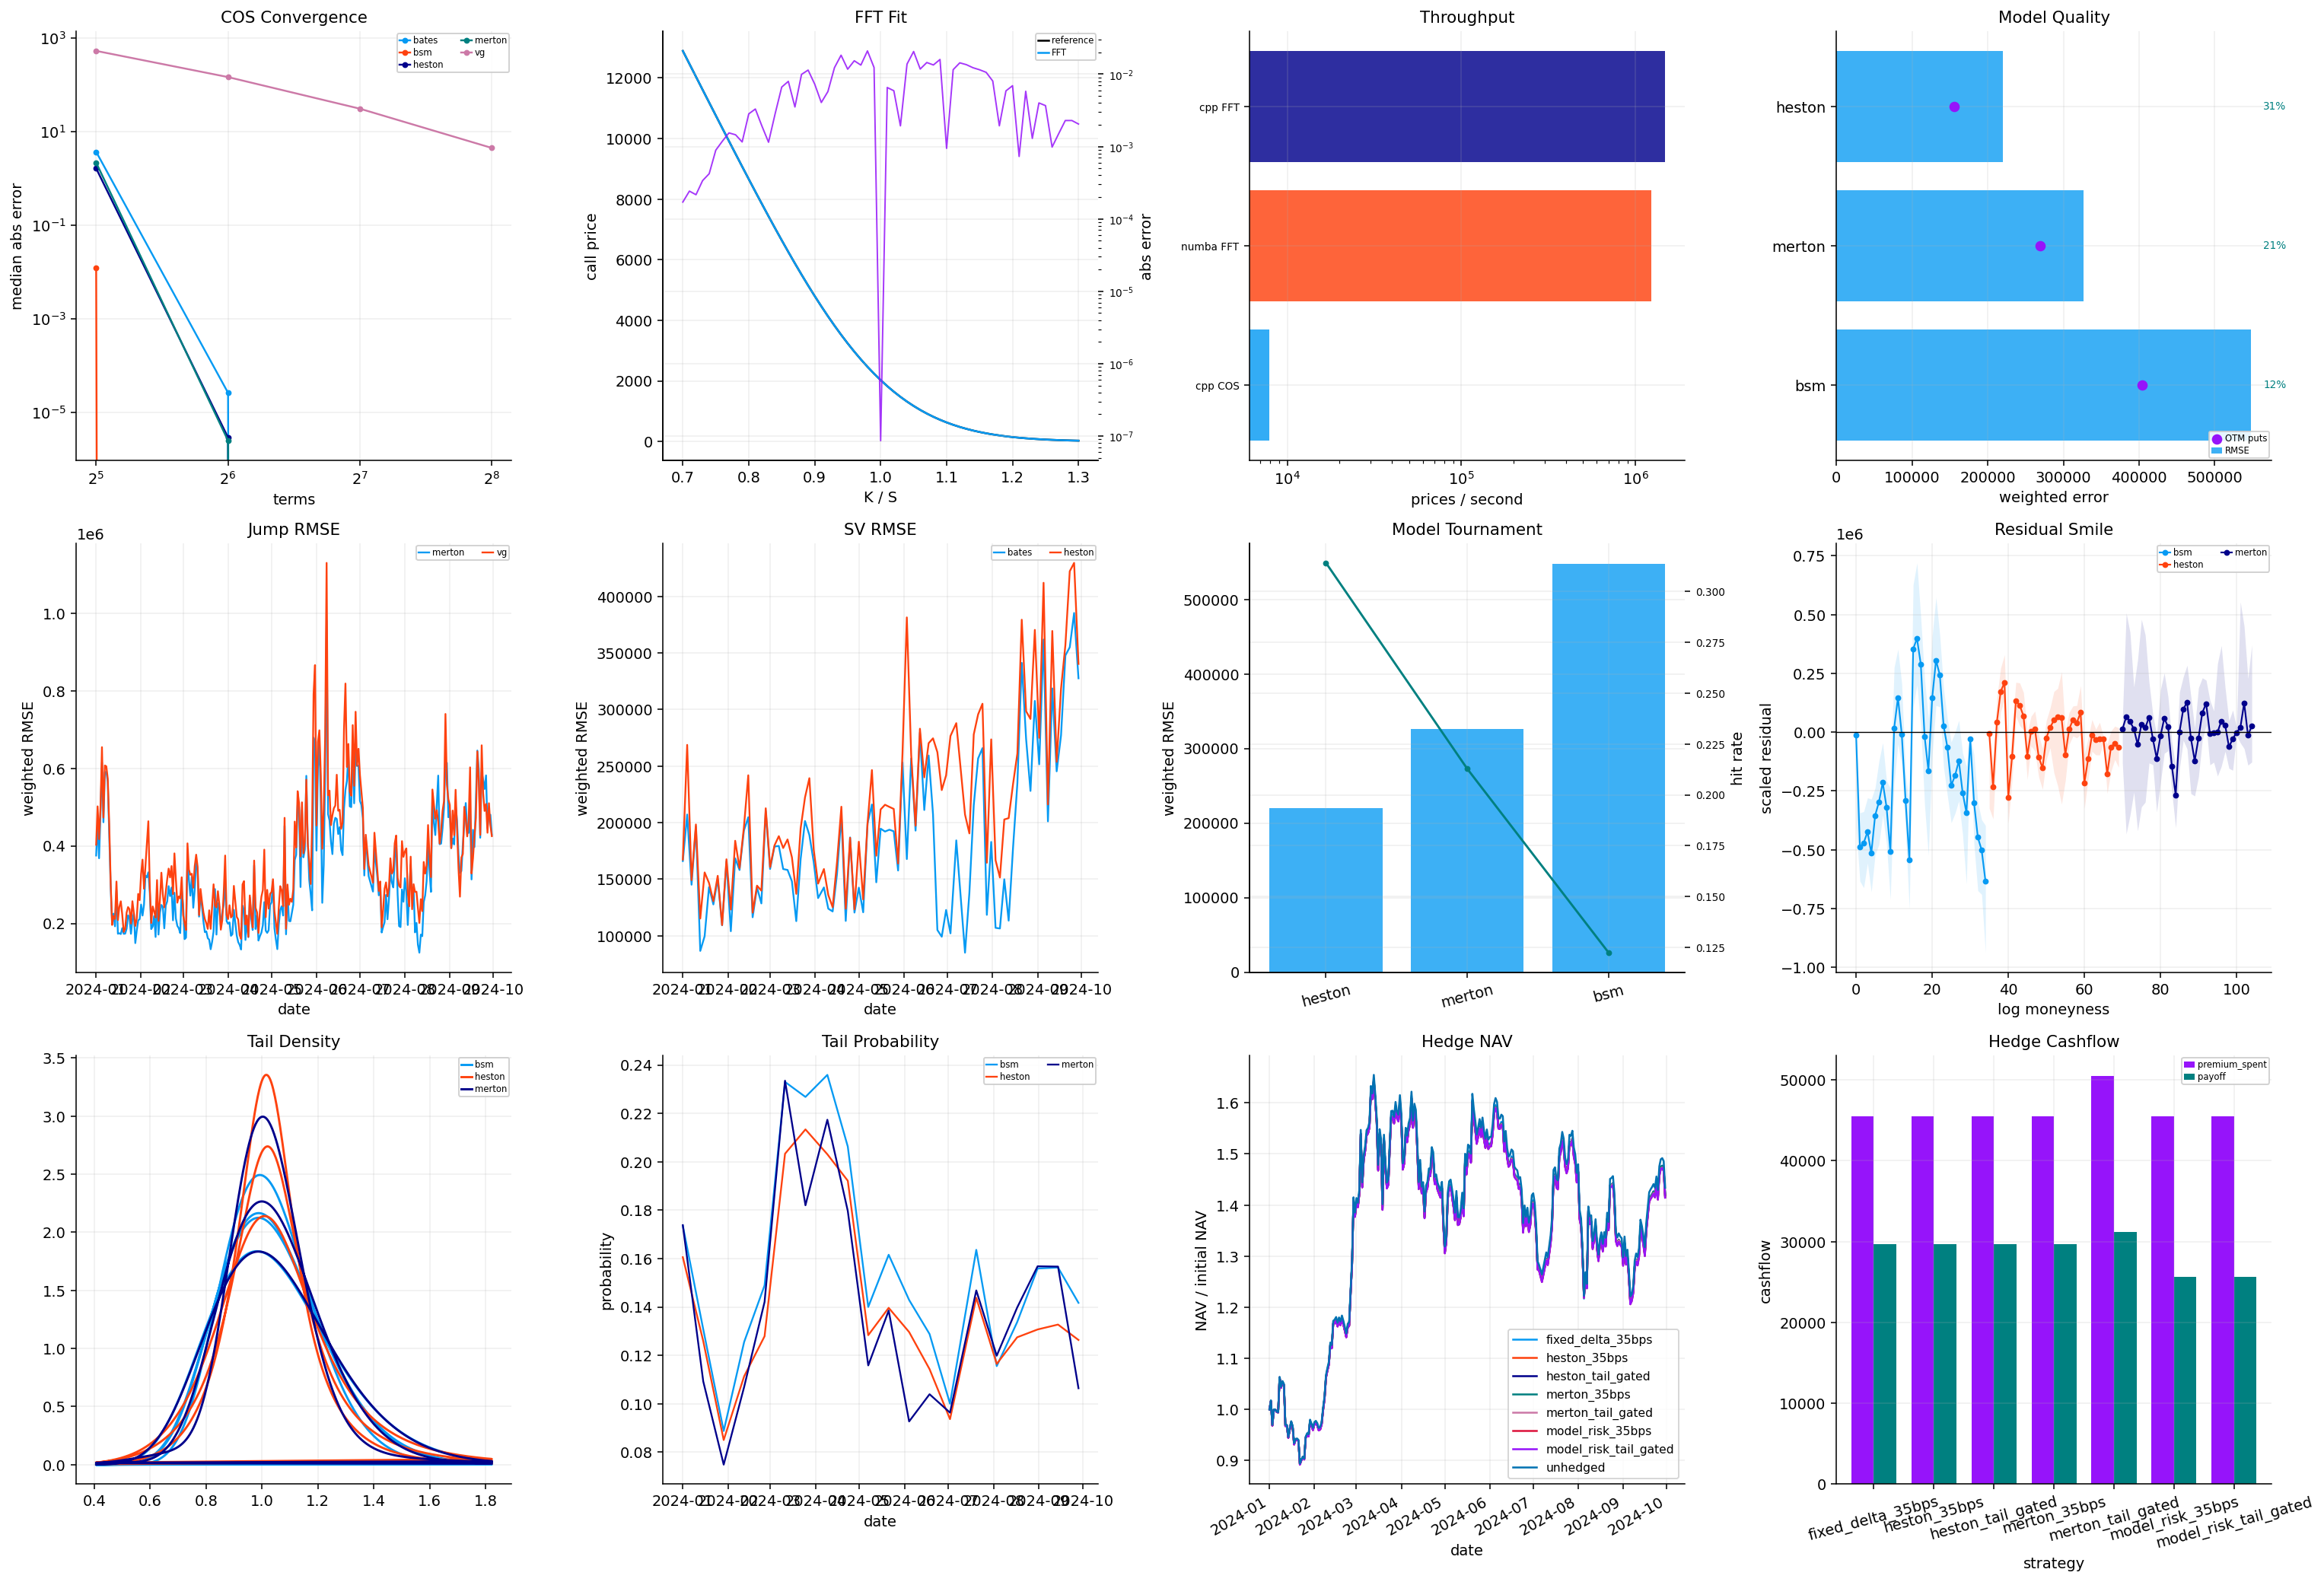

In [ ]:
from quantfinlab.options.fourier import direct_price, fft_grid, cos_prices, cos_density, tail_probability, model_cf
from quantfinlab.options.quote_cleaning import convert_quotes_to_usd_equivalent
from quantfinlab.options.bsm import bsm_price
from quantfinlab.dataio import load_option_chain, load_ohlcv
from quantfinlab.calibration.fft_cos import calibration_grid_quotes, calibration_weights, fit_daily_models, compare_fourier_models, family_winner, residual_by_bucket
from quantfinlab.calibration.jump_models import fixed_delta_hedge_candidates, tail_hedge_candidates, tail_hedge_schedule, hedge_score_components
from quantfinlab.backtest.overlays import run_overlay_backtest, overlay_summary, mark_book_for_schedules
from quantfinlab.plotting.options import cos_convergence, fft_fit, throughput, model_quality, daily_calibration_error, model_tournament, residual_smiles, tail_density, tail_probability_series, overlay_equity, hedge_selection, hedge_cost_payoff

btc_cache = cache_dir / "btc"
btc_cache.mkdir(parents=True, exist_ok=True)
btc_raw = load_option_chain(data_dir / "btc_options_chain.parquet", source="btc_deribit")
btc_raw = convert_quotes_to_usd_equivalent(btc_raw, contract_size=1.0)
btc_raw["date"] = pd.to_datetime(btc_raw["date"], errors="coerce").dt.normalize()
btc_raw["expiry"] = pd.to_datetime(btc_raw["expiry"], errors="coerce").dt.normalize()
btc_raw["dte_days"] = btc_raw["tau"] * 365.0
btc_raw["moneyness"] = btc_raw["strike"] / btc_raw["spot"]
btc_raw["log_moneyness"] = np.log(btc_raw["moneyness"])
btc_raw["relative_spread"] = btc_raw.get("rel_spread", (btc_raw["ask"] - btc_raw["bid"]) / btc_raw["mid"].replace(0, np.nan))
btc_raw["iv_mid"] = pd.to_numeric(btc_raw.get("iv", btc_raw.get("mark_iv")), errors="coerce")
btc_raw["rate"] = 0.04
btc_raw["dividend_yield"] = 0.0
btc_raw["discount_factor"] = np.exp(-btc_raw["rate"] * btc_raw["tau"])
btc_quotes = btc_raw[
    (btc_raw["bid"] >= 0)
    & (btc_raw["ask"] >= btc_raw["bid"])
    & (btc_raw["mid"] > 0)
    & btc_raw["dte_days"].between(3, 120)
    & btc_raw["moneyness"].between(0.55, 1.60)
    & btc_raw["relative_spread"].between(0, 0.50)
    & btc_raw["iv_mid"].between(0.05, 3.00)
].copy()
btc_quotes["half_spread"] = 0.5 * (pd.to_numeric(btc_quotes["ask"], errors="coerce") - pd.to_numeric(btc_quotes["bid"], errors="coerce"))
btc_quotes["calib_scale_px"] = np.maximum.reduce([
    btc_quotes["half_spread"].to_numpy(float),
    0.001 * pd.to_numeric(btc_quotes["mid"], errors="coerce").to_numpy(float),
    np.full(len(btc_quotes), 5.0),
])
btc_quotes["obs_weight"] = 1.0 / (btc_quotes["relative_spread"].clip(lower=0.01) ** 2 + 0.05 ** 2)
btc_quotes["obs_weight"] = btc_quotes["obs_weight"] / btc_quotes["obs_weight"].median()
btc_quotes["contract_key"] = btc_quotes["option_type"].astype(str) + "_" + btc_quotes["expiry"].dt.strftime("%Y-%m-%d") + "_" + btc_quotes["strike"].round(4).astype(str)
btc_spot = load_ohlcv(data_dir / "btc_usd_ohlcv.csv", fields=("close",))
btc_calib_path = btc_cache / "btc_calibration_grid_quotes.parquet"
btc_steps_path = btc_cache / "btc_calibration_grid_steps.parquet"
btc_calib_settings = {"version": 2, "rows": int(len(btc_quotes)), "min_quotes_per_date": 100, "max_quotes_per_date": 160}
if btc_calib_path.exists() and btc_steps_path.exists() and same_settings(btc_calib_path, btc_calib_settings):
    btc_calibration = pd.read_parquet(btc_calib_path)
    btc_selection_steps = pd.read_parquet(btc_steps_path)
else:
    btc_calibration, btc_selection_steps = calibration_grid_quotes(
        btc_quotes,
        min_dte=7.0,
        max_dte=120.0,
        min_vega=0.0,
        max_relative_spread=0.50,
        max_abs_log_moneyness=0.45,
        min_quotes_per_expiry=6,
        min_expiries_per_date=4,
        dte_targets=(7.0, 14.0, 21.0, 30.0, 45.0, 60.0, 75.0, 90.0, 120.0),
        k_targets=(-0.40, -0.32, -0.25, -0.18, -0.12, -0.08, -0.04, 0.0, 0.04, 0.08, 0.12, 0.18, 0.25, 0.32, 0.40),
        min_quotes_per_date=100,
        max_quotes_per_date=160,
        return_steps=True,
    )
    btc_calibration.to_parquet(btc_calib_path, index=False)
    btc_selection_steps.to_parquet(btc_steps_path, index=False)
    write_meta(btc_calib_path, btc_calib_settings, len(btc_calibration))
btc_dates = btc_calibration.groupby("date").size()
btc_fit_dates = btc_dates[btc_dates >= 80].index
btc_sv_dates = btc_fit_dates[::3]
btc_jump_path = btc_cache / "btc_jump_daily_fits_scale_v2.parquet"
btc_sv_path = btc_cache / "btc_sv_daily_fits_scale_v2.parquet"
if btc_jump_path.exists():
    btc_jump_daily = pd.read_parquet(btc_jump_path)
    btc_jump_fit = pd.read_parquet(btc_cache / "btc_jump_daily_fit_prices_scale_v2.parquet")
else:
    out = fit_daily_models(btc_calibration, ["merton", "vg"], calibration_dates=btc_fit_dates, min_quotes=80, max_nfev=45, engine="cpp", n_terms=128, truncation_width=16.0)
    btc_jump_daily, btc_jump_fit = out["params"], out["fit"]
    btc_jump_daily.to_parquet(btc_jump_path, index=False)
    btc_jump_fit.to_parquet(btc_cache / "btc_jump_daily_fit_prices_scale_v2.parquet", index=False)
if btc_sv_path.exists():
    btc_sv_daily = pd.read_parquet(btc_sv_path)
    btc_sv_fit = pd.read_parquet(btc_cache / "btc_sv_daily_fit_prices_scale_v2.parquet")
else:
    out = fit_daily_models(btc_calibration, ["heston", "bates"], calibration_dates=btc_sv_dates, min_quotes=80, max_nfev=40, engine="cpp", n_terms=112, truncation_width=16.0)
    btc_sv_daily, btc_sv_fit = out["params"], out["fit"]
    btc_sv_daily.to_parquet(btc_sv_path, index=False)
    btc_sv_fit.to_parquet(btc_cache / "btc_sv_daily_fit_prices_scale_v2.parquet", index=False)
btc_jump_summary = compare_fourier_models(daily=btc_jump_daily)
btc_sv_summary = compare_fourier_models(daily=btc_sv_daily)
btc_jump_winner = family_winner(btc_jump_summary)
btc_sv_winner = family_winner(btc_sv_summary)
btc_bsm_path = btc_cache / "btc_bsm_daily_fits_scale_v2.parquet"
if btc_bsm_path.exists():
    btc_bsm_daily = pd.read_parquet(btc_bsm_path)
    btc_bsm_fit = pd.read_parquet(btc_cache / "btc_bsm_daily_fit_prices_scale_v2.parquet")
else:
    out = fit_daily_models(btc_calibration, ["bsm"], calibration_dates=btc_fit_dates, min_quotes=80, max_nfev=25, engine="cpp", n_terms=112, truncation_width=14.0)
    btc_bsm_daily, btc_bsm_fit = out["params"], out["fit"]
    btc_bsm_daily.to_parquet(btc_bsm_path, index=False)
    btc_bsm_fit.to_parquet(btc_cache / "btc_bsm_daily_fit_prices_scale_v2.parquet", index=False)
btc_final_daily = pd.concat([btc_bsm_daily, btc_jump_daily[btc_jump_daily["model"].eq(btc_jump_winner)], btc_sv_daily[btc_sv_daily["model"].eq(btc_sv_winner)]], ignore_index=True)
btc_final_comparison = compare_fourier_models(daily=btc_final_daily)
btc_fit_prices = pd.concat([btc_bsm_fit, btc_jump_fit[btc_jump_fit["model"].eq(btc_jump_winner)], btc_sv_fit[btc_sv_fit["model"].eq(btc_sv_winner)]], ignore_index=True)
btc_residuals = residual_by_bucket(btc_fit_prices)
btc_sample = btc_quotes.iloc[:80].copy()
spot0 = float(btc_sample["spot"].median())
rate0 = float(btc_sample["rate"].median())
tau0 = float(btc_sample["tau"].median())
strikes = np.linspace(0.70, 1.30, 1000) * spot0
closed = np.asarray(bsm_price("call", spot0, strikes, tau0, float(btc_sample["iv_mid"].median()), rate0, 0.0), dtype=float)
btc_engine_settings = {"version": 2, "spot": round(spot0, 6), "tau": round(tau0, 8), "rows": int(len(btc_sample))}
btc_fft_path = btc_cache / "btc_fft_validation_grid.parquet"
btc_cos_path = btc_cache / "btc_cos_validation_grid.parquet"
btc_fft_fit_path = btc_cache / "btc_fft_fit_grid.parquet"
if btc_fft_path.exists() and btc_cos_path.exists() and btc_fft_fit_path.exists() and same_settings(btc_fft_path, btc_engine_settings):
    btc_fft_validation = pd.read_parquet(btc_fft_path)
    btc_cos_validation = pd.read_parquet(btc_cos_path)
    btc_fft_fit = pd.read_parquet(btc_fft_fit_path)
else:
    fft_rows = []
    fft_fit_rows = []
    for engine in ["numba", "cpp"]:
        for n in [4096, 8192, 16384]:
            t0 = time.perf_counter()
            grid = fft_grid("bsm", [float(btc_sample["iv_mid"].median())], spot0, rate0, 0.0, tau0, n=n, eta=0.35, alpha=1.5, engine=engine)
            runtime = time.perf_counter() - t0
            interp = np.interp(strikes, grid["strike"], grid["price"])
            fft_rows.append({"engine": engine, "n": n, "runtime_sec": runtime, "median_abs_error": float(np.median(np.abs(interp - closed))), "max_abs_error": float(np.max(np.abs(interp - closed)))})
            if engine == "cpp" and n == 16384:
                fft_fit_rows.extend([{"strike": float(k), "moneyness": float(k / spot0), "fft_price": float(px), "reference_price": float(ref), "abs_error": float(abs(px - ref))} for k, px, ref in zip(strikes, interp, closed)])
    btc_fft_validation = pd.DataFrame(fft_rows)
    cos_rows = []
    for model, params, width in [("bsm", [float(btc_sample["iv_mid"].median())], 12.0), ("merton", [0.65, 0.60, -0.08, 0.35], 16.0), ("vg", [0.65, -0.10, 0.35], 30.0), ("heston", [0.45, 2.0, 0.45, 0.80, -0.45], 16.0), ("bates", [0.45, 2.0, 0.45, 0.80, -0.45, 0.60, -0.08, 0.35], 16.0)]:
        ref = cos_prices(model, params, strikes, np.full_like(strikes, tau0), spot0, rate0, 0.0, n_terms=512, truncation_width=width, option_type="call", engine="numba")
        for n_terms in [32, 64, 128, 256]:
            num = cos_prices(model, params, strikes, np.full_like(strikes, tau0), spot0, rate0, 0.0, n_terms=n_terms, truncation_width=width, option_type="call", engine="numba")
            t0 = time.perf_counter()
            cpp = cos_prices(model, params, strikes, np.full_like(strikes, tau0), spot0, rate0, 0.0, n_terms=n_terms, truncation_width=width, option_type="call", engine="cpp")
            runtime = time.perf_counter() - t0
            cos_rows.append({"model": model, "n_terms": n_terms, "runtime_sec": runtime, "items": len(strikes), "max_abs_error": float(np.max(np.abs(num - ref))), "median_abs_error": float(np.median(np.abs(num - ref))), "cpp_numba_diff": float(np.max(np.abs(num - cpp)))})
    btc_cos_validation = pd.DataFrame(cos_rows)
    btc_fft_fit = pd.DataFrame(fft_fit_rows)
    btc_fft_validation.to_parquet(btc_fft_path, index=False)
    btc_cos_validation.to_parquet(btc_cos_path, index=False)
    btc_fft_fit.to_parquet(btc_fft_fit_path, index=False)
    write_meta(btc_fft_path, btc_engine_settings, len(btc_fft_validation))
btc_throughput = pd.concat([
    btc_fft_validation.assign(label=btc_fft_validation["engine"] + " FFT", items=btc_fft_validation["n"]),
    btc_cos_validation.assign(label="cpp COS", items=btc_cos_validation["items"]),
], ignore_index=True)
btc_model_quality = btc_final_comparison.copy()
btc_tail_path = btc_cache / "btc_tail_series_grid.parquet"
btc_density_path = btc_cache / "btc_density_grid.parquet"
btc_tail_settings = {"version": 2, "jump": btc_jump_winner, "sv": btc_sv_winner, "dates": int(btc_final_daily["date"].nunique())}
if btc_tail_path.exists() and btc_density_path.exists() and same_settings(btc_tail_path, btc_tail_settings):
    btc_tail_series = pd.read_parquet(btc_tail_path)
    btc_density = pd.read_parquet(btc_density_path)
else:
    tail_rows = []
    density_rows = []
    for d in pd.DatetimeIndex(sorted(btc_final_daily["date"].drop_duplicates()))[::max(1, len(btc_final_daily["date"].drop_duplicates()) // 18)]:
        day = btc_quotes[btc_quotes["date"].eq(pd.Timestamp(d).normalize())]
        if day.empty:
            continue
        s = float(day["spot"].median())
        r = float(day["rate"].median())
        x = np.linspace(np.log(s) - 0.9, np.log(s) + 0.6, 520)
        for model in ["bsm", btc_jump_winner, btc_sv_winner]:
            source = btc_final_daily[btc_final_daily["model"].eq(model)]
            source = source[source["date"].le(pd.Timestamp(d).normalize())].sort_values("date")
            if source.empty:
                continue
            params = source.iloc[-1][[c for c in source.columns if c.startswith("p")]].dropna().to_numpy(float)
            den = cos_density(model, params, x, s, r, 0.0, 45 / 365.0)
            rel = np.exp(x) / s
            probs = {}
            for level in [0.90, 0.85, 0.80]:
                mask = rel <= level
                probs[level] = float(np.trapezoid(den[mask], x[mask])) if mask.any() else 0.0
                tail_rows.append({"date": pd.Timestamp(d).normalize(), "model": model, "level": level, "left_tail_probability": probs[level], "tail_probability": probs[level], "tail_prob_80": probs[0.80] if level == 0.80 else np.nan})
            if len(density_rows) < 5000:
                density_rows.extend([{"date": pd.Timestamp(d).normalize(), "model": model, "x": float(xi), "density": float(yi)} for xi, yi in zip(rel, den)])
    btc_tail_series = pd.DataFrame(tail_rows)
    btc_density = pd.DataFrame(density_rows)
    btc_tail_series.to_parquet(btc_tail_path, index=False)
    btc_density.to_parquet(btc_density_path, index=False)
    write_meta(btc_tail_path, btc_tail_settings, len(btc_tail_series))
btc_tail_wide = btc_tail_series.pivot_table(index=["date", "model"], columns="level", values="tail_probability").reset_index().rename(columns={0.9: "p90", 0.85: "p85", 0.8: "p80"})
btc_tail_plot = btc_tail_series[btc_tail_series["level"].eq(0.80)].copy()
hedge_input = btc_quotes[btc_quotes["option_type"].astype(str).str.lower().str.startswith("p") & btc_quotes["dte_days"].between(21, 120) & btc_quotes["moneyness"].between(0.70, 0.98) & btc_quotes["relative_spread"].le(0.40)].copy()
btc_hedge_prices_path = btc_cache / "btc_hedge_prices_grid.parquet"
btc_hedge_price_settings = {"version": 4, "rows": int(len(hedge_input)), "jump": btc_jump_winner, "sv": btc_sv_winner, "engine": "cpp date batches", "scale": "usd floor v2"}
if btc_hedge_prices_path.exists() and same_settings(btc_hedge_prices_path, btc_hedge_price_settings):
    hedge_input = pd.read_parquet(btc_hedge_prices_path)
else:
    hedge_input["jump_price"] = np.nan
    hedge_input["sv_price"] = np.nan
    for price_col, model, daily, width in [("jump_price", btc_jump_winner, btc_jump_daily, 30.0 if btc_jump_winner == "vg" else 16.0), ("sv_price", btc_sv_winner, btc_sv_daily, 16.0)]:
        values = np.full(len(hedge_input), np.nan)
        daily_model = daily[daily["model"].eq(model)].copy()
        for d, idx in hedge_input.groupby("date", sort=True).groups.items():
            source = daily_model[daily_model["date"].le(pd.Timestamp(d).normalize())].sort_values("date")
            if source.empty:
                continue
            params = source.iloc[-1][[c for c in source.columns if c.startswith("p")]].dropna().to_numpy(float)
            g = hedge_input.loc[idx]
            values[hedge_input.index.get_indexer(idx)] = cos_prices(model, params, g["strike"].to_numpy(float), g["tau"].to_numpy(float), float(g["spot"].median()), float(g["rate"].median()), 0.0, option_type="put", n_terms=112, truncation_width=width, engine="cpp")
        hedge_input[price_col] = values
    hedge_input.to_parquet(btc_hedge_prices_path, index=False)
    write_meta(btc_hedge_prices_path, btc_hedge_price_settings, len(hedge_input))
hedge_input = hedge_input.dropna(subset=["jump_price", "sv_price"]).copy()
hedge_input["model_uncertainty"] = (hedge_input["jump_price"] - hedge_input["sv_price"]).abs() / hedge_input["spot"].clip(lower=1e-8)
def btc_tail_for(model, d):
    q = btc_tail_wide[btc_tail_wide["model"].eq(model)].copy()
    q = q[q["date"].le(pd.Timestamp(d).normalize())].sort_values("date")
    if q.empty:
        return pd.Series({"p90": 0.12, "p85": 0.07, "p80": 0.04})
    return q.iloc[-1][["p90", "p85", "p80"]].fillna({"p90": 0.12, "p85": 0.07, "p80": 0.04})

def btc_budget_for(model, d, edge_ratio=0.0, relative_spread=0.0, base_bps=35.0):
    q = btc_tail_wide[btc_tail_wide["model"].eq(model)].copy()
    q = q[q["date"].le(pd.Timestamp(d).normalize())].sort_values("date")
    if len(q) < 8:
        return base_bps
    hist = q["p80"].tail(60).dropna()
    if hist.empty:
        return base_bps
    p = float(hist.iloc[-1])
    edge = float(edge_ratio) if np.isfinite(edge_ratio) else 0.0
    spread = float(relative_spread) if np.isfinite(relative_spread) else 1.0
    add = 0.0
    if spread <= 0.30 and p > float(hist.quantile(0.70)) and edge > -0.05:
        add += 25.0
    if spread <= 0.30 and p > float(hist.quantile(0.85)) and edge > 0.0:
        add += 40.0
    if spread <= 0.30 and p > float(hist.quantile(0.95)) and edge > 0.0:
        add += 60.0
    return min(base_bps + add, 120.0)

def with_tail_budget(q, model, gated=False):
    out = q.copy()
    vals = out["date"].map(lambda d: btc_tail_for(model, d))
    out["p90"] = [float(v["p90"]) for v in vals]
    out["p85"] = [float(v["p85"]) for v in vals]
    out["p80"] = [float(v["p80"]) for v in vals]
    if gated:
        edge = pd.to_numeric(out.get("model_edge", 0.0), errors="coerce").fillna(0.0) / pd.to_numeric(out.get("mid", 1.0), errors="coerce").replace(0.0, np.nan).fillna(1.0)
        spread = pd.to_numeric(out.get("relative_spread", 1.0), errors="coerce").fillna(1.0)
        out["budget_bps"] = [
            btc_budget_for(model, d, edge_ratio=e, relative_spread=sp)
            for d, e, sp in zip(out["date"], edge, spread)
        ]
    else:
        out["budget_bps"] = 35.0
    return out

fixed = fixed_delta_hedge_candidates(with_tail_budget(hedge_input, btc_sv_winner, False), top_n=None, top_n_per_date=1)
jump_fixed = tail_hedge_candidates(with_tail_budget(hedge_input.assign(model_price=hedge_input["jump_price"], model_edge=hedge_input["jump_price"] - hedge_input["mid"]), btc_jump_winner, False), top_n=None, top_n_per_date=1, crash_level=0.85)
jump_gated = tail_hedge_candidates(with_tail_budget(hedge_input.assign(model_price=hedge_input["jump_price"], model_edge=hedge_input["jump_price"] - hedge_input["mid"]), btc_jump_winner, True), top_n=None, top_n_per_date=1, crash_level=0.85)
sv_fixed = tail_hedge_candidates(with_tail_budget(hedge_input.assign(model_price=hedge_input["sv_price"], model_edge=hedge_input["sv_price"] - hedge_input["mid"]), btc_sv_winner, False), top_n=None, top_n_per_date=1, crash_level=0.80)
sv_gated = tail_hedge_candidates(with_tail_budget(hedge_input.assign(model_price=hedge_input["sv_price"], model_edge=hedge_input["sv_price"] - hedge_input["mid"]), btc_sv_winner, True), top_n=None, top_n_per_date=1, crash_level=0.80)
risk_price = 0.5 * (hedge_input["jump_price"] + hedge_input["sv_price"])
risk_edge = risk_price - hedge_input["mid"] - 0.5 * (hedge_input["jump_price"] - hedge_input["sv_price"]).abs()
risk_frame = hedge_input[hedge_input["moneyness"].le(0.93)].copy()
risk_price = 0.5 * (risk_frame["jump_price"] + risk_frame["sv_price"])
risk_edge = risk_price - risk_frame["mid"] - 0.5 * (risk_frame["jump_price"] - risk_frame["sv_price"]).abs()
risk_frame = risk_frame.assign(model_price=risk_price, model_edge=risk_edge, calibration_penalty=0.0)
risk_fixed = tail_hedge_candidates(with_tail_budget(risk_frame, btc_sv_winner, False), top_n=None, top_n_per_date=1, crash_level=0.80)
risk_gated = tail_hedge_candidates(with_tail_budget(risk_frame, btc_sv_winner, True), top_n=None, top_n_per_date=1, crash_level=0.80)
btc_hedge_candidates = pd.concat([
    fixed.assign(selector="fixed_delta_35bps"),
    jump_fixed.assign(selector=f"{btc_jump_winner}_35bps"),
    jump_gated.assign(selector=f"{btc_jump_winner}_tail_gated"),
    sv_fixed.assign(selector=f"{btc_sv_winner}_35bps"),
    sv_gated.assign(selector=f"{btc_sv_winner}_tail_gated"),
    risk_fixed.assign(selector="model_risk_35bps"),
    risk_gated.assign(selector="model_risk_tail_gated"),
], ignore_index=True)
btc_schedules = {}
for selector, group in btc_hedge_candidates.groupby("selector"):
    sched = tail_hedge_schedule(group, spacing_days=21, budget_notional=1_000_000.0, premium_budget_bps=35.0, budget_col="budget_bps", contract_multiplier=1.0, label="tail_put")
    btc_schedules[selector] = sched
btc_schedules["unhedged"] = pd.DataFrame(columns=["entry_date", "contract_key", "expiry", "strike", "option_type", "quantity", "label"])
btc_underlying = btc_spot["close"].reindex(pd.DatetimeIndex(sorted(btc_quotes["date"].unique()))).ffill()
btc_shares = 1_000_000.0 / float(btc_underlying.dropna().iloc[0])
btc_hedge_book = mark_book_for_schedules(btc_quotes, btc_schedules)
btc_hedge_nav_path = btc_cache / "btc_hedge_nav_grid.parquet"
btc_hedge_trades_path = btc_cache / "btc_hedge_trades_grid.parquet"
btc_hedge_settings = {"version": 8, "schedule_rows": int(sum(len(x) for x in btc_schedules.values())), "mark_rows": int(len(btc_hedge_book)), "base_budget_bps": 35.0, "tail_gated_budget": "price_aware", "risk_penalty": 0.0, "risk_moneyness_max": 0.93, "spacing_days": 21}
if btc_hedge_nav_path.exists() and btc_hedge_trades_path.exists() and same_settings(btc_hedge_nav_path, btc_hedge_settings):
    btc_hedge_nav = pd.read_parquet(btc_hedge_nav_path).set_index("date")
    btc_hedge_nav.index = pd.to_datetime(btc_hedge_nav.index, errors="coerce").normalize()
    if not btc_hedge_nav.empty and float((btc_hedge_nav.iloc[0] - 1_000_000.0).abs().max()) > 1e-8:
        btc_hedge_nav = pd.concat([pd.DataFrame({c: 1_000_000.0 for c in btc_hedge_nav.columns}, index=[btc_hedge_nav.index.min()]), btc_hedge_nav])
    btc_hedge_trades = pd.read_parquet(btc_hedge_trades_path)
    btc_hedge_results = {"nav": btc_hedge_nav, "drawdown": btc_hedge_nav / btc_hedge_nav.cummax() - 1.0, "trades": btc_hedge_trades}
else:
    btc_hedge_results = run_overlay_backtest(btc_schedules, btc_hedge_book, btc_underlying, initial_nav=1_000_000.0, contract_multiplier=1.0, shares=btc_shares)
    btc_hedge_results["nav"].reset_index(names="date").to_parquet(btc_hedge_nav_path, index=False)
    btc_hedge_results["trades"].to_parquet(btc_hedge_trades_path, index=False)
    write_meta(btc_hedge_nav_path, btc_hedge_settings, len(btc_hedge_results["nav"]))
btc_hedge_summary = overlay_summary(btc_hedge_results)
btc_trade_check = btc_hedge_results["trades"].copy()
if btc_trade_check.empty:
    btc_hedge_check = pd.DataFrame([{"rows": 0, "open_trades": 0, "mark_rows": len(btc_hedge_book), "max_quantity": 0.0, "median_open_price": np.nan, "premium_spent": 0.0}])
else:
    btc_open = btc_trade_check[btc_trade_check["event"].eq("open")].copy()
    btc_hedge_check = btc_open.groupby("strategy", as_index=False).agg(open_trades=("event", "size"), max_quantity=("quantity", "max"), median_quantity=("quantity", "median"), median_open_price=("price", "median"), premium_spent=("cashflow", lambda x: -float(np.sum(x))), median_moneyness=("moneyness", "median"), median_dte=("dte_days", "median"))
    btc_hedge_check["mark_rows"] = len(btc_hedge_book)
display(pd.DataFrame([{"btc_rows": len(btc_quotes), "calibration_rows": len(btc_calibration), "calibration_dates": btc_calibration["date"].nunique(), "avg_quotes_per_date": btc_dates.mean(), "jump_winner": btc_jump_winner, "sv_winner": btc_sv_winner}]).round(4))
display(btc_selection_steps)
display(btc_final_comparison.round(6))
display(btc_hedge_check.round(4))
display(btc_hedge_summary.round(6))
fig, axes = plt.subplots(3, 4, figsize=(22, 15))
axes = axes.ravel()
cos_convergence(axes[0], btc_cos_validation, "COS Convergence")
fft_fit(axes[1], btc_fft_fit, "FFT Fit")
throughput(axes[2], btc_throughput, "Throughput")
model_quality(axes[3], btc_model_quality, "Model Quality")
daily_calibration_error(axes[4], btc_jump_daily, "Jump RMSE")
daily_calibration_error(axes[5], btc_sv_daily, "SV RMSE")
model_tournament(axes[6], btc_final_comparison, "Model Tournament")
residual_smiles(axes[7], btc_residuals.assign(x=np.arange(len(btc_residuals))), "Residual Smile")
tail_density(axes[8], btc_density.rename(columns={"x": "x"}), "Tail Density")
tail_probability_series(axes[9], btc_tail_plot, "Tail Probability")
overlay_equity(axes[10], btc_hedge_results, "Hedge NAV")
hedge_cost_payoff(axes[11], btc_hedge_results["trades"], "Hedge Cashflow")
fig.tight_layout(pad=1.25, h_pad=1.0, w_pad=1.0)
plt.show()


The BTC calibration panel has **96,695 clean rows**, **26,958 calibration rows**, and **269 calibration dates**, with about **100 quotes per date**. The selected winners are **Merton** for the jump family and **Heston** for the stochastic-volatility family.


The BTC model comparison is very different in scale because BTC option prices and spot levels are much larger and more volatile. Heston is the best model in the displayed comparison, with weighted RMSE around **219,722**, while Merton has about **326,548** and BSM about **547,645**.

The ranking makes economic sense. BTC volatility is highly time-varying, so stochastic volatility matters. Merton jumps improve over BSM, but a finite jump model alone can't fully capture the continuous repricing of volatility risk in crypto. Heston has the highest bid/ask hit rate among the three, about **31.4%**, which is much higher than the SPX model hit rates shown earlier.

The success rate is lower for Heston, about **88.9%**, because the model is harder to calibrate and the market is more unstable. This is a useful warning: better fit comes with more calibration fragility.


The BTC hedge results show the same insurance problem as SPX, but with crypto-sized moves. The unhedged BTC exposure ends with the highest final NAV, about **1.434M**, while hedged strategies end around **1.415M to 1.419M**. Since BTC rallied strongly over this sample, protective puts were a drag.

The drawdowns are large for every strategy, around **-26%**, and the hedges don't materially reduce them in this run. The median selected BTC options are expensive, with open prices in the thousands of dollars, and the premium budget is meaningful. When the underlying rallies or avoids a deep crash, that premium bleed lowers final return.

The interesting part is the model behavior, not the realized outperformance. The Heston and Merton selectors choose different moneyness and maturity profiles. The model-risk selector tends to choose options where jump and SV models agree more, or where disagreement is penalized. In crypto, this disagreement is valuable because model assumptions about tails can diverge dramatically.


The BTC diagnostic panel gives a compact view of the whole secondary workflow:

- COS convergence and FFT fit validate the pricing engines.
- Throughput shows the cost of pricing high-volatility crypto options.
- Model quality ranks BSM, Merton, and Heston.
- Daily calibration errors show when jump or SV models struggle.
- Residual smiles show whether the model misses calls, puts, or wings.
- Tail density and tail probability panels show how crash risk changes through time.
- Hedge NAV and hedge cashflow show realized overlay performance.

The most important economic interpretation is that BTC makes volatility modeling more central. SPX already has a rich skew and institutional crash-protection market, but BTC adds larger jumps, faster regime changes, and more expensive convexity. Fourier methods are useful here because once we have characteristic functions and fast kernels, we can compare distributional assumptions quickly across many quotes.


## 17) What This Project Adds to the Series

This project is the transform-pricing layer of the option sequence. Project 4 focused on implied volatility extraction. Project 8 focused on surfaces and local volatility. Project 11 focused on stochastic-volatility model structure. Project 13 focused on American-option numerics. Here the main contribution is the machinery that lets many models be priced through a common transform framework.

The strongest results are:

- Direct Fourier integration matches BSM and Merton reference prices almost exactly.
- FFT prices full strike grids extremely fast but introduces grid/interpolation considerations.
- COS is the most useful calibration engine because it handles arbitrary market strikes efficiently.
- VG needs special numerical care because its transform/tail behavior creates a higher COS error floor in this setup.
- Merton strongly improves over BSM on SPX options, especially in the left tail.
- Bates dominates the final SPX model comparison on RMSE, bid/ask hit rate, and OTM put error, but it is slower and less stable than simpler models.
- Tail-hedging overlays show how model-implied crash probabilities can inform protection selection, while realized performance still depends on whether a crash actually occurs.
- BTC confirms that the same Fourier machinery transfers to a more volatile market, but model stability and premium bleed become even more important.

The project ends with a practical lesson: Fourier methods are not only mathematical pricing tricks. They create a common numerical language for comparing very different risk-neutral distributions under real-market calibration pressure.


### 17.1 Practical Method Selection

After all the validation and calibration, the methods have clear practical roles.

| Method | Best use | Main limitation |
|---|---|---|
| Direct integration | reference pricing and formula validation | too slow for large calibration grids |
| Carr-Madan FFT | fast full log-strike grids for one maturity/model | market strikes need interpolation and grid design |
| COS | fast arbitrary-strike pricing | needs careful truncation interval, especially for heavy-tailed models |
| Grouped COS | production calibration across real option groups | still nonlinear and model-dependent |

The method selection follows the data shape. If we need a smooth grid of strikes, FFT is attractive. If we need exact market strikes across many expiries, COS is better. If we need a high-confidence benchmark for a selected grid, direct integration is best.

This is the main numerical lesson of Project 14. Fourier pricing gives a family of transform-based methods, and the right choice depends on whether the problem is validation, grid pricing, calibration, or tail diagnostics.
